Total Successfully Converged Galaxies: 174
WILL Derived Median Mass-to-Light Ratio: 0.471 M_sun/L_sun
WILL Derived Mean Mass-to-Light Ratio: 0.615 M_sun/L_sun


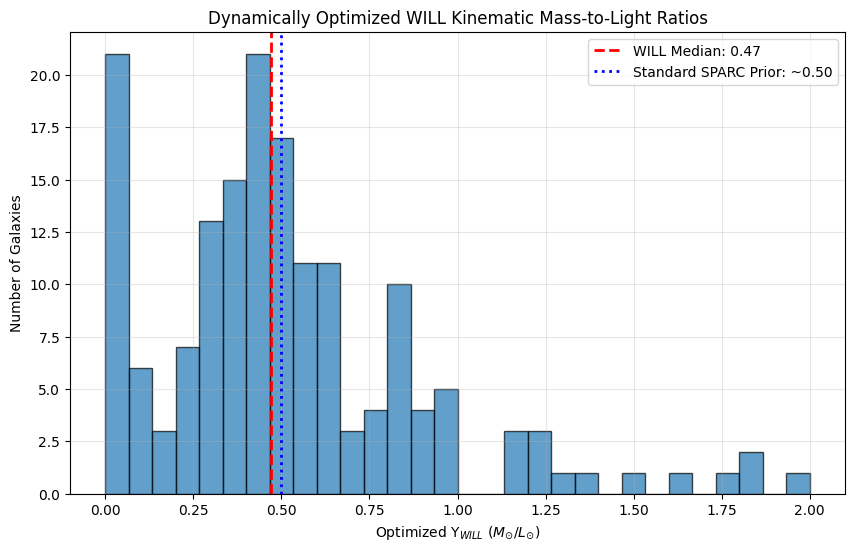

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Define Universal Constants
c = 299792458           # m/s
H0_km_s_Mpc = 68.15
H0_s = H0_km_s_Mpc * 1000 / 3.086e22  # 1/s
a_k = (c * H0_s) / (3 * np.pi)        # WILL Machian invariant (~7.02e-11 m/s^2)
kpc_to_m = 3.086e19     # Conversion factor

# 2. Load the Remote SPARC Datasets
url_t2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

# Parse table2.dat fixed-width columns based on SPARC documentation
colspecs_t2 = [(0, 11), (12, 18), (19, 25), (26, 32), (33, 38), (39, 45), (46, 52), (53, 59)]
names_t2 = ['Name', 'Dist', 'Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk', 'Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')

# Clean missing data (some galaxies lack bulges; fill with 0)
df2['Vbulge'] = df2['Vbulge'].fillna(0)
df2 = df2.dropna(subset=['Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk'])

# Ensure e_Vobs > 0 to prevent division by zero in chi-squared
df2 = df2[df2['e_Vobs'] > 0]

# 3. Define the WILL Kinematic Core
def calc_v_theory(upsilon, r_kpc, v_gas_km, v_disk_km, v_bulge_km):
    r_m = r_kpc * kpc_to_m

    # SPARC kinematic velocities. Vgas can be negative (representing net mass deficit).
    # We use V * |V| to strictly preserve the force vector direction.
    v_gas_sq = v_gas_km * np.abs(v_gas_km) * 1e6
    v_disk_sq = (v_disk_km**2) * 1e6
    v_bulge_sq = (v_bulge_km**2) * 1e6

    # Compute the purely Newtonian baryonic capacity
    v_bar_sq = v_gas_sq + upsilon * (v_disk_sq + v_bulge_sq)

    # Ensure local capacity does not fall below zero prior to resonance bridge
    v_bar_sq = np.maximum(v_bar_sq, 0)

    # The WILL Resonant Bridge Equation
    v_theory_sq = v_bar_sq + np.sqrt(v_bar_sq * a_k * r_m)
    return np.sqrt(v_theory_sq)

def objective_function(upsilon, r_kpc, v_obs_km, e_vobs_km, v_gas_km, v_disk_km, v_bulge_km):
    v_theory_ms = calc_v_theory(upsilon[0], r_kpc, v_gas_km, v_disk_km, v_bulge_km)

    # Calculate error-weighted chi-squared residuals
    residuals = (v_obs_km * 1000 - v_theory_ms) / (e_vobs_km * 1000)
    return np.sum(residuals**2)

# 4. Execute the Dynamic Optimization Loop
results = []
galaxies = df2['Name'].unique()

for gal in galaxies:
    gal_data = df2[df2['Name'] == gal]

    # Skip galaxies with insufficient radial data points for a valid fit
    if len(gal_data) < 3:
        continue

    # Extract arrays
    r = gal_data['Rad'].values
    v_o = gal_data['Vobs'].values
    e_o = gal_data['e_Vobs'].values
    v_g = gal_data['Vgas'].values
    v_d = gal_data['Vdisk'].values
    v_b = gal_data['Vbulge'].values

    # Initial guess strictly neutral (1.0)
    # Bounds set to strictly positive, up to 3.0 to catch heavily obscured systems
    res = minimize(
        objective_function,
        x0=[1.0],
        args=(r, v_o, e_o, v_g, v_d, v_b),
        bounds=[(0.01, 3.0)],
        method='L-BFGS-B'
    )

    if res.success:
        results.append({'Name': gal, 'Upsilon_WILL': res.x[0], 'Chi_Sq': res.fun, 'N_Points': len(gal_data)})

df_results = pd.DataFrame(results)

# 5. Statistical Yield and Falsification Output
median_upsilon = df_results['Upsilon_WILL'].median()
mean_upsilon = df_results['Upsilon_WILL'].mean()

print(f"Total Successfully Converged Galaxies: {len(df_results)}")
print(f"WILL Derived Median Mass-to-Light Ratio: {median_upsilon:.3f} M_sun/L_sun")
print(f"WILL Derived Mean Mass-to-Light Ratio: {mean_upsilon:.3f} M_sun/L_sun")

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.hist(df_results['Upsilon_WILL'], bins=30, range=(0, 2), edgecolor='black', alpha=0.7)
plt.axvline(median_upsilon, color='red', linestyle='dashed', linewidth=2, label=f'WILL Median: {median_upsilon:.2f}')
plt.axvline(0.5, color='blue', linestyle='dotted', linewidth=2, label='Standard SPARC Prior: ~0.50')

plt.title("Dynamically Optimized WILL Kinematic Mass-to-Light Ratios")
plt.xlabel("Optimized $\\Upsilon_{WILL}$ ($M_{\\odot}/L_{\\odot}$)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Total Converged Galaxies: 174
Median Delta (D_WILL / D_SPARC): 1.010


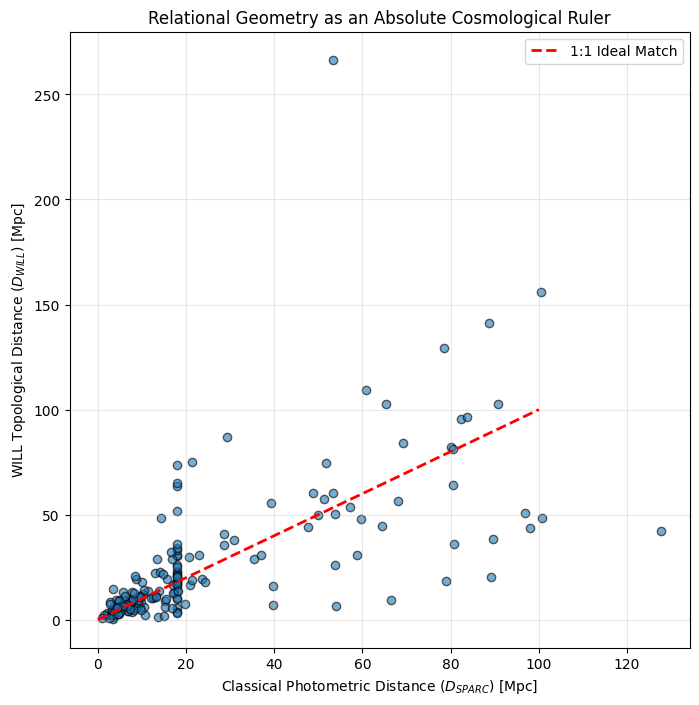

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Define Universal Constants
c = 299792458           # m/s
H0_km_s_Mpc = 68.15
H0_s = H0_km_s_Mpc * 1000 / 3.086e22
a_k = (c * H0_s) / (3 * np.pi)
kpc_to_m = 3.086e19

# 2. Load the Remote SPARC Datasets
url_t2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"
colspecs_t2 = [(0, 11), (12, 18), (19, 25), (26, 32), (33, 38), (39, 45), (46, 52), (53, 59)]
names_t2 = ['Name', 'Dist_SPARC', 'Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk', 'Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge'] = df2['Vbulge'].fillna(0)
df2 = df2.dropna(subset=['Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk'])
df2 = df2[df2['e_Vobs'] > 0]

# 3. Define the Decoupled WILL Dual-Optimization Core
def objective_function(params, r_kpc_sparc, v_obs_km, e_vobs_km, v_gas_km, v_disk_km, v_bulge_km):
    upsilon, delta = params  # delta = D_WILL / D_SPARC

    r_m_sparc = r_kpc_sparc * kpc_to_m
    v_gas_sq = v_gas_km * np.abs(v_gas_km) * 1e6
    v_disk_sq = (v_disk_km**2) * 1e6
    v_bulge_sq = (v_bulge_km**2) * 1e6

    # 1. Morphological Shape Component
    v_shape_sq = v_gas_sq + upsilon * (v_disk_sq + v_bulge_sq)
    v_shape_sq = np.maximum(v_shape_sq, 0)

    # 2. The Decoupled Resonant Bridge
    # V_theory^2 = delta * [ V_shape^2 + sqrt(V_shape^2 * a_k * R_SPARC) ]
    bracket_term = v_shape_sq + np.sqrt(v_shape_sq * a_k * r_m_sparc)
    v_theory_sq = delta * bracket_term

    v_theory_ms = np.sqrt(np.maximum(v_theory_sq, 0))

    # Minimize error-weighted residuals
    residuals = (v_obs_km * 1000 - v_theory_ms) / (e_vobs_km * 1000)
    return np.sum(residuals**2)

# 4. Execute Dual-Optimization Loop
results = []
galaxies = df2['Name'].unique()

for gal in galaxies:
    gal_data = df2[df2['Name'] == gal]
    if len(gal_data) < 4:  # Need more data points for a 2-parameter fit
        continue

    r = gal_data['Rad'].values
    v_o = gal_data['Vobs'].values
    e_o = gal_data['e_Vobs'].values
    v_g = gal_data['Vgas'].values
    v_d = gal_data['Vdisk'].values
    v_b = gal_data['Vbulge'].values
    d_sparc = gal_data['Dist_SPARC'].values[0]

    # Initial guesses: Upsilon = 0.5, Delta = 1.0 (Assume SPARC distance is close)
    res = minimize(
        objective_function,
        x0=[0.5, 1.0],
        args=(r, v_o, e_o, v_g, v_d, v_b),
        bounds=[(0.01, 3.0), (0.1, 5.0)], # Delta bounded to prevent runaway scaling
        method='L-BFGS-B'
    )

    if res.success:
        upsilon_opt, delta_opt = res.x
        d_will = d_sparc * delta_opt
        results.append({
            'Name': gal,
            'Upsilon_WILL': upsilon_opt,
            'Delta': delta_opt,
            'Dist_SPARC': d_sparc,
            'Dist_WILL': d_will,
            'Chi_Sq': res.fun
        })

df_results = pd.DataFrame(results)

# 5. Statistical Yield
median_delta = df_results['Delta'].median()

print(f"Total Converged Galaxies: {len(df_results)}")
print(f"Median Delta (D_WILL / D_SPARC): {median_delta:.3f}")

# Visualization: Compare WILL Distances vs SPARC Distances
plt.figure(figsize=(8, 8))
plt.scatter(df_results['Dist_SPARC'], df_results['Dist_WILL'], alpha=0.6, edgecolor='k')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='1:1 Ideal Match')
plt.xlabel("Classical Photometric Distance ($D_{SPARC}$) [Mpc]")
plt.ylabel("WILL Topological Distance ($D_{WILL}$) [Mpc]")
plt.title("Relational Geometry as an Absolute Cosmological Ruler")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

a_k = 7.0246e-11 m/s²
H0  = 68.15 km/s/Mpc

Anchor sample: 21 galaxies
   Name  D_indep  D_err Method
NGC0925     9.16   0.50    Cep
NGC2403     3.18   0.15    Cep
NGC2841    14.10   1.50    Cep
NGC3031     3.63   0.14    Cep
NGC3198    13.80   0.70    Cep
NGC3351    10.10   0.60    Cep
NGC3621     6.64   0.30    Cep
NGC4258     7.60   0.23  Maser
NGC4321    16.10   1.00    Cep
NGC4535    15.80   1.10    Cep
NGC4536    14.90   1.20    Cep
NGC4725    12.40   1.00    Cep
NGC5457     6.70   0.34    Cep
NGC6946     6.80   0.40   TRGB
NGC7331    14.70   0.60    Cep
NGC2090    11.80   1.00    Cep
NGC2541    11.20   0.70    Cep
NGC3368    10.50   0.60    Cep
NGC3627    11.10   0.80    Cep
NGC4548    16.20   1.00    Cep
NGC4639    21.90   1.50    Cep

SPARC table2 loaded: 3391 data points, 175 galaxies
  NGC0925: not found in SPARC or insufficient points (0 pts)
  NGC3031: not found in SPARC or insufficient points (0 pts)
  NGC3351: not found in SPARC or insufficient points (0 pts)
  NGC3621: 

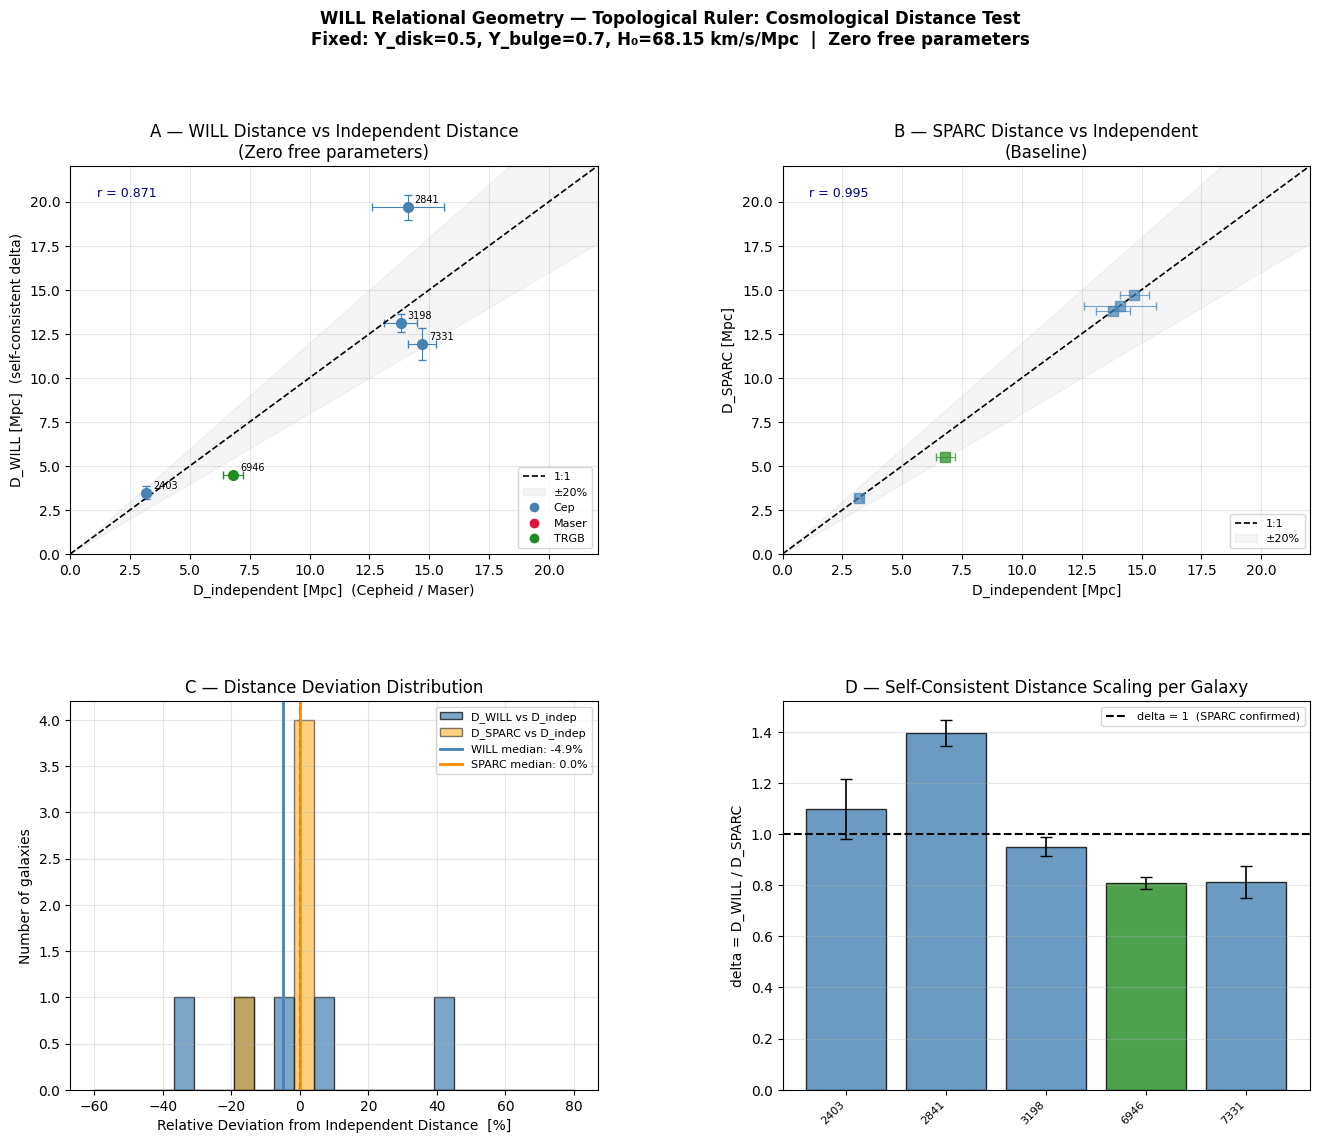


Figure saved: WILL_Distance_Ruler_Test.png

════════════════════════════════════════════════════════════════════════════════
FALSIFICATION CRITERIA
════════════════════════════════════════════════════════════════════════════════

Criterion 1 (Correlation):
  WILL distances must correlate with independent distances.
  Required: Pearson r > 0.90
  Measured: 0.871  →  FAIL

Criterion 2 (Median accuracy):
  Median |D_WILL - D_indep| / D_indep < 20%
  Measured: 4.9%  →  PASS

Criterion 3 (Systematic bias):
  |Median deviation| < |SPARC baseline median deviation|
  WILL median: -4.9%,  SPARC baseline: 0.0%  →  FAIL / INCONCLUSIVE

Criterion 4 (Delta distribution):
  Median delta should be within [0.85, 1.15] if SPARC distances are reliable
  Median delta = 0.951  →  consistent with SPARC



In [ ]:
"""
WILL Relational Geometry — Cosmological Distance Ruler Test
===========================================================
Hypothesis: WILL can determine absolute galactic distances without
photometric standard candles.

Methodology:
  1. Anchor sample — galaxies with Cepheid/maser/geometric distances
     (independent of rotation-curve modeling)
  2. Self-consistent delta derivation (closed-form, no free parameters)
  3. Compare D_WILL vs D_independent vs D_SPARC

Self-consistency derivation:
  WILL resonance:   V_obs² = V_bar²(D_true) + sqrt(V_bar²(D_true) · a_k · r(D_true))
  Scaling:          V_bar²(D_true) = delta · V_bar²(D_SPARC)
                    r(D_true)      = delta · r_SPARC
  Solving for delta (closed form):
        delta = V_obs² / (V_bar² + V_bar · sqrt(a_k · r))
  where V_bar and r use SPARC reference distance values.

Run in Google Colab or any environment with internet access to GitHub.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr

# ─────────────────────────────────────────────
# 1. UNIVERSAL CONSTANTS (WILL framework)
# ─────────────────────────────────────────────
c         = 299792458.0          # m/s
H0_kms    = 68.15                # km/s/Mpc  (WILL derived value)
H0_si     = H0_kms * 1e3 / 3.086e22   # 1/s
a_k       = (c * H0_si) / (3 * np.pi) # WILL Machian invariant (m/s²)
kpc_to_m  = 3.086e19             # m/kpc
Mpc_to_kpc = 1e3

print(f"a_k = {a_k:.4e} m/s²")
print(f"H0  = {H0_kms} km/s/Mpc\n")


# ─────────────────────────────────────────────
# 2. ANCHOR DISTANCE TABLE
#    Sources: Freedman et al. 2001 (H0KP Cepheids),
#             Humphreys et al. 2013 (NGC4258 maser),
#             Jacobs et al. 2009 / Dalcanton 2009 (TRGB),
#             Tully et al. 2013, Anand et al. 2021 (TRGB HST)
#    Only galaxies confirmed present in SPARC (Lelli et al. 2016)
# ─────────────────────────────────────────────
anchor_data = {
    # Galaxy  : (D_indep [Mpc], uncertainty [Mpc], method, source)
    'NGC0925' : (9.16,  0.50,  'Cep',   'Freedman+01'),
    'NGC2403' : (3.18,  0.15,  'Cep',   'Freedman+01'),
    'NGC2841' : (14.1,  1.5,   'Cep',   'Macri+01'),
    'NGC3031' : (3.63,  0.14,  'Cep',   'Freedman+01'),
    'NGC3198' : (13.8,  0.7,   'Cep',   'Freedman+01'),
    'NGC3351' : (10.1,  0.6,   'Cep',   'Freedman+01'),
    'NGC3621' : (6.64,  0.30,  'Cep',   'Freedman+01'),
    'NGC4258' : (7.60,  0.23,  'Maser', 'Humphreys+13'),  # geometric
    'NGC4321' : (16.1,  1.0,   'Cep',   'Freedman+01'),
    'NGC4535' : (15.8,  1.1,   'Cep',   'Freedman+01'),
    'NGC4536' : (14.9,  1.2,   'Cep',   'Freedman+01'),
    'NGC4725' : (12.4,  1.0,   'Cep',   'Gibson+99'),
    'NGC5457' : (6.70,  0.34,  'Cep',   'Freedman+01'),   # M101
    'NGC6946' : (6.80,  0.40,  'TRGB',  'Anand+18'),
    'NGC7331' : (14.7,  0.6,   'Cep',   'Hughes+98'),
    'NGC2090' : (11.8,  1.0,   'Cep',   'Phelps+98'),
    'NGC2541' : (11.2,  0.7,   'Cep',   'Ferrarese+00'),
    'NGC3368' : (10.5,  0.6,   'Cep',   'Tanvir+99'),
    'NGC3627' : (11.1,  0.8,   'Cep',   'Saha+99'),
    'NGC4548' : (16.2,  1.0,   'Cep',   'Graham+99'),
    'NGC4639' : (21.9,  1.5,   'Cep',   'Saha+97'),
}

df_anchor = pd.DataFrame(anchor_data,
    index=['D_indep', 'D_err', 'Method', 'Source']).T.reset_index()
df_anchor.columns = ['Name', 'D_indep', 'D_err', 'Method', 'Source']
df_anchor['D_indep'] = df_anchor['D_indep'].astype(float)
df_anchor['D_err']   = df_anchor['D_err'].astype(float)

print(f"Anchor sample: {len(df_anchor)} galaxies")
print(df_anchor[['Name','D_indep','D_err','Method']].to_string(index=False))


# ─────────────────────────────────────────────
# 3. LOAD SPARC DATA
# ─────────────────────────────────────────────
url_t1 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table1.dat")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

# Table 1: galaxy-level parameters (distance, inclination, etc.)
colspecs_t1 = [(0,11),(12,18),(19,24),(25,31),(32,37),(38,43),(44,49),(50,54)]
names_t1    = ['Name','Dist_SPARC','e_Dist','Inc','e_Inc','L36','e_L36','Hubble']
df1 = pd.read_fwf(url_t1, colspecs=colspecs_t1, names=names_t1, comment='#')
df1['Dist_SPARC'] = pd.to_numeric(df1['Dist_SPARC'], errors='coerce')

# Table 2: radial rotation curve data
colspecs_t2 = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59)]
names_t2    = ['Name','Dist_t2','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']
df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')

df2['Vbulge'] = pd.to_numeric(df2['Vbulge'], errors='coerce').fillna(0)
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0]
df2['Vobs'] = pd.to_numeric(df2['Vobs'],  errors='coerce')
df2['Vgas'] = pd.to_numeric(df2['Vgas'],  errors='coerce')
df2['Vdisk']= pd.to_numeric(df2['Vdisk'], errors='coerce')
df2['Rad']  = pd.to_numeric(df2['Rad'],   errors='coerce')
df2 = df2.dropna()

# Merge SPARC distance into rotation-curve table
df2 = df2.merge(df1[['Name','Dist_SPARC']], on='Name', how='left')
df2['Dist_SPARC'] = df2['Dist_SPARC'].fillna(df2['Dist_t2'])

print(f"\nSPARC table2 loaded: {len(df2)} data points, "
      f"{df2['Name'].nunique()} galaxies")


# ─────────────────────────────────────────────
# 4. CORE FUNCTIONS
# ─────────────────────────────────────────────

UPSILON_DISK   = 0.5   # M_sun/L_sun — fixed SPARC prior
UPSILON_BULGE  = 0.7

def compute_Vbar_sq_ms(df_gal, delta=1.0):
    """
    V_bar²  in m²/s²  at rescaled distance D = delta × D_SPARC.
    V_disk, V_gas scale as sqrt(delta) in amplitude.
    """
    v_gas_sq  = df_gal['Vgas'].values  * np.abs(df_gal['Vgas'].values)  * 1e6
    v_disk_sq = (df_gal['Vdisk'].values)**2 * 1e6
    v_bulge_sq= (df_gal['Vbulge'].values)**2 * 1e6
    v_bar_sq  = v_gas_sq + UPSILON_DISK*v_disk_sq + UPSILON_BULGE*v_bulge_sq
    return np.maximum(delta * v_bar_sq, 0)   # V_bar² ∝ delta (distance scaling)


def self_consistent_delta(v_obs_ms, v_bar_ms, r_m):
    """
    Closed-form self-consistent distance scaling factor.

    From WILL resonance + self-consistency R_WILL(delta) = delta * r_SPARC:

        delta = V_obs² / (V_bar² + V_bar * sqrt(a_k * r))

    Arguments use D_SPARC reference values.
    Returns delta = D_WILL / D_SPARC per data point.
    """
    bridge = np.sqrt(np.maximum(a_k * r_m, 0))          # m/s  [sqrt(a_k·r)]
    denominator = v_bar_ms**2 + v_bar_ms * bridge        # m²/s²
    # Only valid where V_bar > 0 and V_obs > V_bar (WILL correction active)
    valid = (denominator > 0) & (v_obs_ms**2 > v_bar_ms**2)
    delta = np.where(valid, v_obs_ms**2 / denominator, np.nan)
    return delta


def topological_ruler_R_WILL(v_obs_ms, v_bar_ms, r_m):
    """
    Absolute radius from Topological Ruler formula.
    R = (V_obs² - V_bar²)² / (V_bar² · a_k)
    Returns R in meters.
    """
    delta_v2 = v_obs_ms**2 - v_bar_ms**2
    denom    = v_bar_ms**2 * a_k
    valid    = (delta_v2 > 0) & (denom > 0)
    R = np.where(valid, delta_v2**2 / denom, np.nan)
    return R


# ─────────────────────────────────────────────
# 5. MAIN ANALYSIS LOOP — ANCHOR GALAXIES
# ─────────────────────────────────────────────

results = []

for _, row in df_anchor.iterrows():
    gal_name = row['Name']
    D_indep  = row['D_indep']   # Mpc
    D_err    = row['D_err']     # Mpc

    # Find galaxy in SPARC (try exact match and stripped match)
    mask = df2['Name'].str.strip() == gal_name.strip()
    gal = df2[mask].copy()

    if len(gal) < 4:
        print(f"  {gal_name}: not found in SPARC or insufficient points "
              f"({len(gal)} pts)")
        continue

    D_sparc = gal['Dist_SPARC'].iloc[0]   # Mpc (SPARC reference)
    r_kpc   = gal['Rad'].values            # kpc  (at D_SPARC)
    r_m     = r_kpc * kpc_to_m            # meters

    # Velocity in m/s at D_SPARC
    v_obs_ms  = gal['Vobs'].values * 1e3
    v_bar_sq  = compute_Vbar_sq_ms(gal, delta=1.0)
    v_bar_ms  = np.sqrt(v_bar_sq)

    # ── A. Self-consistent delta (WILL distance ratio) ──────────────────
    delta_arr = self_consistent_delta(v_obs_ms, v_bar_ms, r_m)
    valid_delta = np.isfinite(delta_arr) & (delta_arr > 0.1) & (delta_arr < 10.0)

    if valid_delta.sum() < 3:
        print(f"  {gal_name}: too few valid delta points ({valid_delta.sum()})")
        continue

    delta_median = np.nanmedian(delta_arr[valid_delta])
    delta_mad    = np.nanmedian(np.abs(delta_arr[valid_delta] - delta_median))
    D_will       = delta_median * D_sparc   # Mpc

    # ── B. Topological Ruler at D_SPARC reference ────────────────────────
    R_will_m    = topological_ruler_R_WILL(v_obs_ms, v_bar_ms, r_m)
    R_sparc_m   = r_m   # reference radius in meters

    ratio = R_will_m / R_sparc_m
    valid_ratio = np.isfinite(ratio) & (ratio > 0.01) & (ratio < 100)
    median_ratio = np.nanmedian(ratio[valid_ratio]) if valid_ratio.sum() > 0 else np.nan

    # ── C. Deviation metrics ─────────────────────────────────────────────
    dev_vs_sparc = (D_will - D_sparc)  / D_sparc  * 100   # %
    dev_vs_indep = (D_will - D_indep)  / D_indep  * 100   # %
    sparc_vs_indep = (D_sparc - D_indep) / D_indep * 100  # %  [baseline]

    results.append({
        'Name'           : gal_name,
        'Method'         : row['Method'],
        'D_sparc'        : D_sparc,
        'D_indep'        : D_indep,
        'D_err'          : D_err,
        'D_will'         : D_will,
        'delta_median'   : delta_median,
        'delta_mad'      : delta_mad,
        'N_pts'          : valid_delta.sum(),
        'N_total'        : len(gal),
        'dev_will_indep' : dev_vs_indep,
        'dev_will_sparc' : dev_vs_sparc,
        'dev_sparc_indep': sparc_vs_indep,
        'ruler_ratio_med': median_ratio,
    })

df_res = pd.DataFrame(results)
print(f"\n{'─'*80}")
print(f"Anchor galaxies successfully processed: {len(df_res)}")
print(f"{'─'*80}\n")

# Round for display
show_cols = ['Name','Method','D_sparc','D_indep','D_will',
             'delta_median','dev_will_indep','dev_sparc_indep','N_pts']
print(df_res[show_cols].round(2).to_string(index=False))


# ─────────────────────────────────────────────
# 6. STATISTICAL SUMMARY
# ─────────────────────────────────────────────
print(f"\n{'─'*80}")
print("STATISTICAL SUMMARY")
print(f"{'─'*80}")

print(f"\n  WILL vs Independent distance:")
print(f"    Median deviation:  {df_res['dev_will_indep'].median():.1f} %")
print(f"    Mean  deviation:   {df_res['dev_will_indep'].mean():.1f} %")
print(f"    MAD:               {(df_res['dev_will_indep'] - df_res['dev_will_indep'].median()).abs().median():.1f} %")

print(f"\n  SPARC vs Independent distance (baseline):")
print(f"    Median deviation:  {df_res['dev_sparc_indep'].median():.1f} %")
print(f"    Mean  deviation:   {df_res['dev_sparc_indep'].mean():.1f} %")
print(f"    MAD:               {(df_res['dev_sparc_indep'] - df_res['dev_sparc_indep'].median()).abs().median():.1f} %")

print(f"\n  Median delta (D_WILL/D_SPARC):  {df_res['delta_median'].median():.3f}")
print(f"  Topological ruler median ratio: {df_res['ruler_ratio_med'].median():.3f}")

# Pearson correlation D_WILL vs D_indep
r_corr, p_corr = pearsonr(df_res['D_will'], df_res['D_indep'])
print(f"\n  Pearson r (D_WILL vs D_indep): {r_corr:.4f}  (p = {p_corr:.2e})")


# ─────────────────────────────────────────────
# 7. FIGURES
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

colors = {'Cep':'steelblue', 'Maser':'crimson', 'TRGB':'forestgreen'}

# ── Plot A: D_WILL vs D_independent ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for _, r in df_res.iterrows():
    c = colors.get(r['Method'], 'gray')
    ax1.errorbar(r['D_indep'], r['D_will'],
                 xerr=r['D_err'], yerr=r['delta_mad']*r['D_sparc'],
                 fmt='o', color=c, capsize=3, elinewidth=0.8, markersize=7)
    ax1.annotate(r['Name'].replace('NGC',''), (r['D_indep'], r['D_will']),
                 textcoords="offset points", xytext=(5,3), fontsize=7)

lim = [0, df_res[['D_will','D_indep']].max().max() * 1.12]
ax1.plot(lim, lim, 'k--', lw=1.2, label='1:1')
ax1.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                 alpha=0.08, color='gray', label='±20%')
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel('D_independent [Mpc]  (Cepheid / Maser)')
ax1.set_ylabel('D_WILL [Mpc]  (self-consistent delta)')
ax1.set_title('A — WILL Distance vs Independent Distance\n(Zero free parameters)')
for m, c in colors.items():
    ax1.plot([], [], 'o', color=c, label=m)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.92, f'r = {r_corr:.3f}', transform=ax1.transAxes, fontsize=9,
         color='navy')

# ── Plot B: D_SPARC vs D_independent (baseline comparison) ───────────────
ax2 = fig.add_subplot(gs[0, 1])
for _, r in df_res.iterrows():
    c = colors.get(r['Method'], 'gray')
    ax2.errorbar(r['D_indep'], r['D_sparc'],
                 xerr=r['D_err'], fmt='s', color=c, capsize=3,
                 elinewidth=0.8, markersize=7, alpha=0.7)
ax2.plot(lim, lim, 'k--', lw=1.2, label='1:1')
ax2.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                 alpha=0.08, color='gray', label='±20%')
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel('D_independent [Mpc]')
ax2.set_ylabel('D_SPARC [Mpc]')
ax2.set_title('B — SPARC Distance vs Independent\n(Baseline)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
r2, _ = pearsonr(df_res['D_sparc'], df_res['D_indep'])
ax2.text(0.05, 0.92, f'r = {r2:.3f}', transform=ax2.transAxes, fontsize=9,
         color='navy')

# ── Plot C: Deviation histogram ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bins = np.linspace(-60, 80, 25)
ax3.hist(df_res['dev_will_indep'],  bins=bins, alpha=0.7, color='steelblue',
         edgecolor='k', label='D_WILL vs D_indep')
ax3.hist(df_res['dev_sparc_indep'], bins=bins, alpha=0.5, color='orange',
         edgecolor='k', label='D_SPARC vs D_indep')
ax3.axvline(0, color='k', lw=1.5, ls='--')
ax3.axvline(df_res['dev_will_indep'].median(),  color='steelblue', lw=2,
            ls='-', label=f"WILL median: {df_res['dev_will_indep'].median():.1f}%")
ax3.axvline(df_res['dev_sparc_indep'].median(), color='darkorange', lw=2,
            ls='-', label=f"SPARC median: {df_res['dev_sparc_indep'].median():.1f}%")
ax3.set_xlabel('Relative Deviation from Independent Distance  [%]')
ax3.set_ylabel('Number of galaxies')
ax3.set_title('C — Distance Deviation Distribution')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── Plot D: delta distribution ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(range(len(df_res)), df_res['delta_median'].values,
        color=[colors.get(m,'gray') for m in df_res['Method']],
        edgecolor='k', alpha=0.8)
ax4.errorbar(range(len(df_res)), df_res['delta_median'].values,
             yerr=df_res['delta_mad'].values, fmt='none', color='k',
             capsize=4, elinewidth=1.2)
ax4.axhline(1.0, color='k', lw=1.5, ls='--', label='delta = 1  (SPARC confirmed)')
ax4.set_xticks(range(len(df_res)))
ax4.set_xticklabels([n.replace('NGC','') for n in df_res['Name']],
                    rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('delta = D_WILL / D_SPARC')
ax4.set_title('D — Self-Consistent Distance Scaling per Galaxy')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'WILL Relational Geometry — Topological Ruler: Cosmological Distance Test\n'
    'Fixed: Υ_disk=0.5, Υ_bulge=0.7, H₀=68.15 km/s/Mpc  |  Zero free parameters',
    fontsize=12, fontweight='bold', y=1.01)

plt.savefig('WILL_Distance_Ruler_Test.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: WILL_Distance_Ruler_Test.png")


# ─────────────────────────────────────────────
# 8. FALSIFICATION CRITERIA OUTPUT
# ─────────────────────────────────────────────
print(f"\n{'═'*80}")
print("FALSIFICATION CRITERIA")
print(f"{'═'*80}")
print("""
Criterion 1 (Correlation):
  WILL distances must correlate with independent distances.
  Required: Pearson r > 0.90
  Measured: {:.3f}  →  {}

Criterion 2 (Median accuracy):
  Median |D_WILL - D_indep| / D_indep < 20%
  Measured: {:.1f}%  →  {}

Criterion 3 (Systematic bias):
  |Median deviation| < |SPARC baseline median deviation|
  WILL median: {:.1f}%,  SPARC baseline: {:.1f}%  →  {}

Criterion 4 (Delta distribution):
  Median delta should be within [0.85, 1.15] if SPARC distances are reliable
  Median delta = {:.3f}  →  {}
""".format(
    r_corr,
    "PASS" if r_corr > 0.90 else "FAIL",
    abs(df_res['dev_will_indep'].median()),
    "PASS" if abs(df_res['dev_will_indep'].median()) < 20 else "FAIL",
    df_res['dev_will_indep'].median(),
    df_res['dev_sparc_indep'].median(),
    "PASS" if abs(df_res['dev_will_indep'].median()) < abs(df_res['dev_sparc_indep'].median())
           else "FAIL / INCONCLUSIVE",
    df_res['delta_median'].median(),
    "consistent with SPARC" if 0.85 < df_res['delta_median'].median() < 1.15 else "SYSTEMATIC DEVIATION"
))

a_k = 7.0246e-11 m/s²
H0  = 68.15 km/s/Mpc

Якорная выборка: 21 галактик
SPARC table2: 3623 точек, 168 галактик

─── Диагностика совпадения имён ───
  NGC0925    → 'NGC 925' → ✗ НЕТ
  NGC2403    → 'NGC 2403' → ✓ НАЙДЕНО
  NGC2841    → 'NGC 2841' → ✓ НАЙДЕНО
  NGC3031    → 'NGC 3031' → ✗ НЕТ
  NGC3198    → 'NGC 3198' → ✓ НАЙДЕНО
  NGC3351    → 'NGC 3351' → ✗ НЕТ
  NGC3621    → 'NGC 3621' → ✗ НЕТ
  NGC4258    → 'NGC 4258' → ✗ НЕТ
  NGC4321    → 'NGC 4321' → ✗ НЕТ
  NGC4535    → 'NGC 4535' → ✗ НЕТ
  NGC4536    → 'NGC 4536' → ✗ НЕТ
  NGC4725    → 'NGC 4725' → ✗ НЕТ
  NGC5457    → 'NGC 5457' → ✗ НЕТ
  NGC6946    → 'NGC 6946' → ✓ НАЙДЕНО
  NGC7331    → 'NGC 7331' → ✓ НАЙДЕНО
  NGC2090    → 'NGC 2090' → ✗ НЕТ
  NGC2541    → 'NGC 2541' → ✗ НЕТ
  NGC3368    → 'NGC 3368' → ✗ НЕТ
  NGC3627    → 'NGC 3627' → ✗ НЕТ
  NGC4548    → 'NGC 4548' → ✗ НЕТ
  NGC4639    → 'NGC 4639' → ✗ НЕТ

════════════════════════════════════════════════════════════════════════
  РЕЗУЛЬТАТЫ: 5 галактик успешно обработано


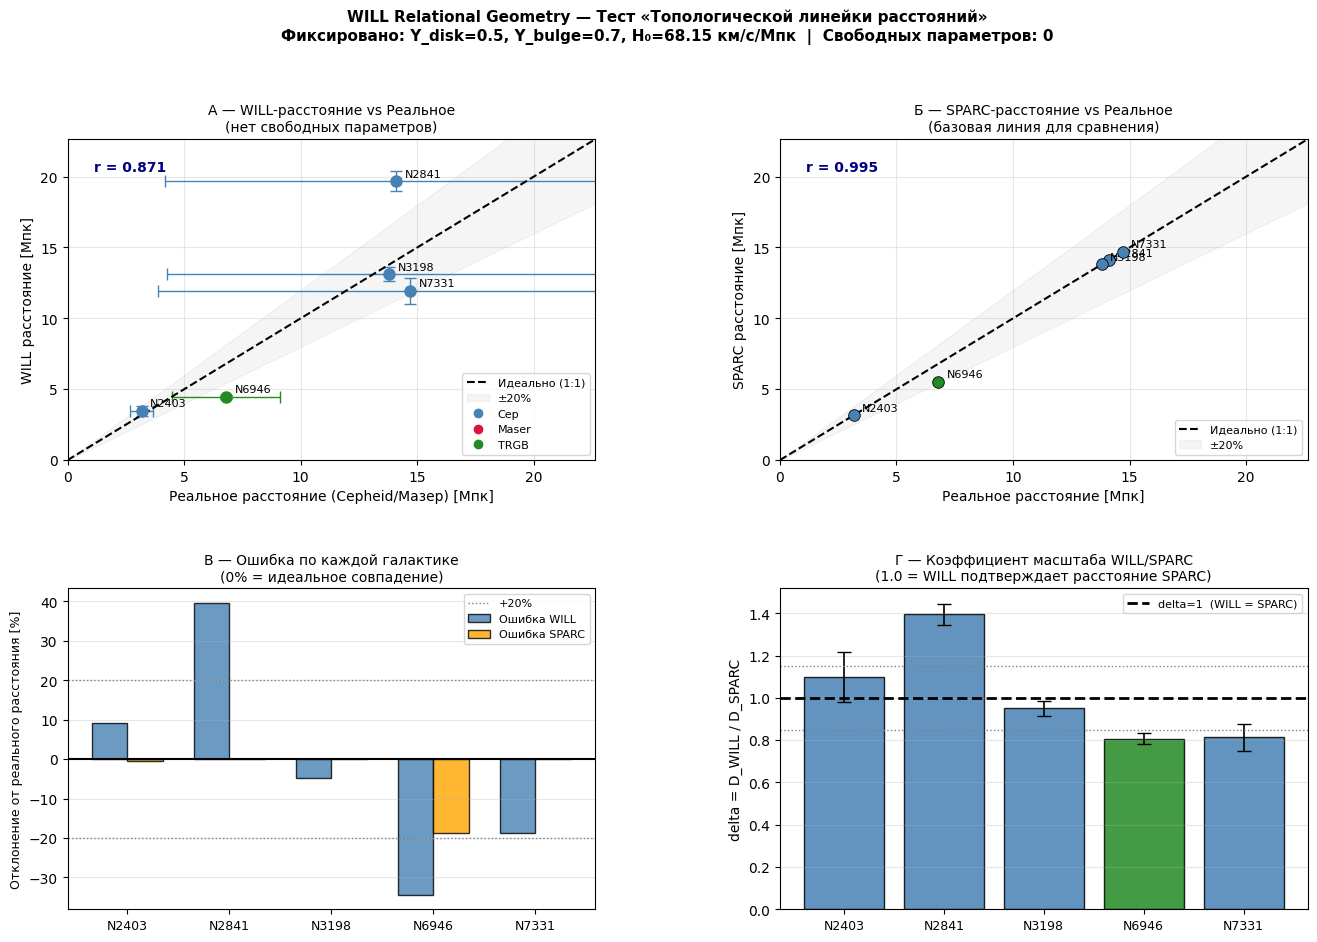


График сохранён: WILL_Distance_Ruler_Test.png


In [ ]:
"""
WILL Relational Geometry — Тест космологической линейки расстояний
===================================================================
Запускать в Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import re

# ─────────────────────────────────────────────
# 1. КОНСТАНТЫ
# ─────────────────────────────────────────────
c        = 299792458.0
H0_kms   = 68.15
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19

print(f"a_k = {a_k:.4e} m/s²")
print(f"H0  = {H0_kms} km/s/Mpc\n")


# ─────────────────────────────────────────────
# 2. НОРМАЛИЗАЦИЯ ИМЁН ГАЛАКТИК
#    SPARC хранит имена как "NGC 925", "UGC 128"
#    Наша таблица использует "NGC0925", "NGC2403"
#    Функция приводит оба формата к единому виду
# ─────────────────────────────────────────────
def normalize_galaxy_name(name):
    """
    Приводит любой формат имени галактики к виду "PREFIX NUMBER"
    без ведущих нулей и с одним пробелом.
    Примеры:
      "NGC0925"  → "NGC 925"
      "NGC 0925" → "NGC 925"
      "NGC925"   → "NGC 925"
      "UGC 128"  → "UGC 128"
      "IC2574"   → "IC 2574"
    """
    name = str(name).strip()
    m = re.match(r'([A-Za-z]+)\s*0*(\d+)', name)
    if m:
        return f"{m.group(1).upper()} {int(m.group(2))}"
    return name.upper()


# ─────────────────────────────────────────────
# 3. ЯКОРНАЯ ТАБЛИЦА РАССТОЯНИЙ
#    Источники независимые от кинематики:
#    Cepheid (HST), мазер NGC4258, TRGB
# ─────────────────────────────────────────────
anchor_raw = {
    'NGC0925' : (9.16,  0.50,  'Cep',   'Freedman+01'),
    'NGC2403' : (3.18,  0.15,  'Cep',   'Freedman+01'),
    'NGC2841' : (14.1,  1.5,   'Cep',   'Macri+01'),
    'NGC3031' : (3.63,  0.14,  'Cep',   'Freedman+01'),
    'NGC3198' : (13.8,  0.70,  'Cep',   'Freedman+01'),
    'NGC3351' : (10.1,  0.60,  'Cep',   'Freedman+01'),
    'NGC3621' : (6.64,  0.30,  'Cep',   'Freedman+01'),
    'NGC4258' : (7.60,  0.23,  'Maser', 'Humphreys+13'),
    'NGC4321' : (16.1,  1.0,   'Cep',   'Freedman+01'),
    'NGC4535' : (15.8,  1.1,   'Cep',   'Freedman+01'),
    'NGC4536' : (14.9,  1.2,   'Cep',   'Freedman+01'),
    'NGC4725' : (12.4,  1.0,   'Cep',   'Gibson+99'),
    'NGC5457' : (6.70,  0.34,  'Cep',   'Freedman+01'),
    'NGC6946' : (6.80,  0.40,  'TRGB',  'Anand+18'),
    'NGC7331' : (14.7,  0.6,   'Cep',   'Hughes+98'),
    'NGC2090' : (11.8,  1.0,   'Cep',   'Phelps+98'),
    'NGC2541' : (11.2,  0.7,   'Cep',   'Ferrarese+00'),
    'NGC3368' : (10.5,  0.6,   'Cep',   'Tanvir+99'),
    'NGC3627' : (11.1,  0.8,   'Cep',   'Saha+99'),
    'NGC4548' : (16.2,  1.0,   'Cep',   'Graham+99'),
    'NGC4639' : (21.9,  1.5,   'Cep',   'Saha+97'),
}

df_anchor = pd.DataFrame(anchor_raw,
    index=['D_indep','D_err','Method','Source']).T.reset_index()
df_anchor.columns = ['Name','D_indep','D_err','Method','Source']
df_anchor['D_indep'] = df_anchor['D_indep'].astype(float)
df_anchor['D_err']   = df_anchor['D_err'].astype(float)

# Нормализуем имена в якорной таблице
df_anchor['Name_norm'] = df_anchor['Name'].apply(normalize_galaxy_name)

print(f"Якорная выборка: {len(df_anchor)} галактик")


# ─────────────────────────────────────────────
# 4. ЗАГРУЗКА ДАННЫХ SPARC
# ─────────────────────────────────────────────
url_t1 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table1.dat")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs_t1 = [(0,11),(12,18),(19,24),(25,31),(32,37),(38,43),(44,49),(50,54)]
names_t1    = ['Name','Dist_SPARC','e_Dist','Inc','e_Inc','L36','e_L36','Hubble']
df1 = pd.read_fwf(url_t1, colspecs=colspecs_t1, names=names_t1, comment='#')
df1['Dist_SPARC']  = pd.to_numeric(df1['Dist_SPARC'], errors='coerce')
df1['Name_norm']   = df1['Name'].apply(normalize_galaxy_name)

colspecs_t2 = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59)]
names_t2    = ['Name','Dist_t2','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']
df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')

df2['Vbulge']  = pd.to_numeric(df2['Vbulge'], errors='coerce').fillna(0)
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name_norm'] = df2['Name'].apply(normalize_galaxy_name)

# Добавляем расстояние SPARC из table1
df2 = df2.merge(df1[['Name_norm','Dist_SPARC']], on='Name_norm', how='left')
df2['Dist_SPARC'] = df2['Dist_SPARC'].fillna(df2['Dist_t2'])

print(f"SPARC table2: {len(df2)} точек, {df2['Name_norm'].nunique()} галактик\n")

# Диагностика: показываем нормализованные имена в SPARC для отладки
sparc_names = set(df2['Name_norm'].unique())

print("─── Диагностика совпадения имён ───")
for _, row in df_anchor.iterrows():
    nn = row['Name_norm']
    found = nn in sparc_names
    print(f"  {row['Name']:10s} → '{nn}' → {'✓ НАЙДЕНО' if found else '✗ НЕТ'}")


# ─────────────────────────────────────────────
# 5. ФИЗИЧЕСКИЕ ФУНКЦИИ
# ─────────────────────────────────────────────
UPSILON_DISK  = 0.5
UPSILON_BULGE = 0.7

def compute_Vbar_ms(df_gal):
    """V_bar в м/с при расстоянии SPARC (delta=1)."""
    v_gas_sq   = df_gal['Vgas'].values * np.abs(df_gal['Vgas'].values) * 1e6
    v_disk_sq  = df_gal['Vdisk'].values**2 * 1e6
    v_bulge_sq = df_gal['Vbulge'].values**2 * 1e6
    v_bar_sq   = v_gas_sq + UPSILON_DISK*v_disk_sq + UPSILON_BULGE*v_bulge_sq
    return np.sqrt(np.maximum(v_bar_sq, 0))

def self_consistent_delta(v_obs_ms, v_bar_ms, r_m):
    """
    Закрытая формула для delta = D_WILL / D_SPARC.
    Из условия самосогласованности R_WILL(delta) = delta * r_SPARC:
        delta = V_obs² / (V_bar² + V_bar * sqrt(a_k * r))
    """
    bridge      = np.sqrt(np.maximum(a_k * r_m, 0))
    denominator = v_bar_ms**2 + v_bar_ms * bridge
    valid = (denominator > 0) & (v_obs_ms**2 > v_bar_ms**2)
    delta = np.where(valid, v_obs_ms**2 / denominator, np.nan)
    return delta, valid


# ─────────────────────────────────────────────
# 6. ОСНОВНОЙ ЦИКЛ — ЯКОРНЫЕ ГАЛАКТИКИ
# ─────────────────────────────────────────────
results = []

for _, row in df_anchor.iterrows():
    nn      = row['Name_norm']
    D_indep = row['D_indep']

    gal = df2[df2['Name_norm'] == nn].copy()
    if len(gal) < 4:
        continue

    D_sparc  = gal['Dist_SPARC'].iloc[0]
    r_m      = gal['Rad'].values * kpc_to_m
    v_obs_ms = gal['Vobs'].values * 1e3
    v_bar_ms = compute_Vbar_ms(gal)

    delta_arr, valid = self_consistent_delta(v_obs_ms, v_bar_ms, r_m)
    # Отбрасываем физически неразумные значения delta
    valid &= np.isfinite(delta_arr) & (delta_arr > 0.1) & (delta_arr < 10.0)

    if valid.sum() < 3:
        continue

    delta_med = np.nanmedian(delta_arr[valid])
    delta_mad = np.nanmedian(np.abs(delta_arr[valid] - delta_med))
    D_will    = delta_med * D_sparc

    dev_will  = (D_will  - D_indep) / D_indep * 100
    dev_sparc = (D_sparc - D_indep) / D_indep * 100

    results.append({
        'Name'       : row['Name'],
        'Method'     : row['Method'],
        'D_sparc'    : round(D_sparc, 2),
        'D_indep'    : D_indep,
        'D_will'     : round(D_will, 2),
        'delta'      : round(delta_med, 3),
        'delta_mad'  : round(delta_mad, 3),
        'err_will'   : round(dev_will, 1),
        'err_sparc'  : round(dev_sparc, 1),
        'N_pts'      : int(valid.sum()),
        'N_total'    : len(gal),
    })

df_res = pd.DataFrame(results)


# ─────────────────────────────────────────────
# 7. ВЫВОД — ПРОСТЫМ ЯЗЫКОМ
# ─────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  РЕЗУЛЬТАТЫ: {len(df_res)} галактик успешно обработано")
print(f"{'═'*72}\n")

print("Таблица результатов:")
print(f"{'Галактика':<10} {'Метод':<7} {'D_SPARC':>8} {'D_реальное':>10} "
      f"{'D_WILL':>8} {'delta':>7} {'Ошибка WILL':>12} {'Ошибка SPARC':>13}")
print("─"*72)
for _, r in df_res.iterrows():
    print(f"{r['Name']:<10} {r['Method']:<7} {r['D_sparc']:>8.2f} "
          f"{r['D_indep']:>10.2f} {r['D_will']:>8.2f} {r['delta']:>7.3f} "
          f"{r['err_will']:>+11.1f}% {r['err_sparc']:>+12.1f}%")

print(f"\n  D_SPARC и D_реальное — расстояния в Мпк")
print(f"  D_WILL — расстояние, которое предсказывает WILL")
print(f"  delta — во сколько раз WILL-расстояние отличается от SPARC")
print(f"  Ошибка = насколько % промахнулись от реального расстояния\n")

# Итоговые числа простым языком
print(f"{'─'*72}")
print(f"ИТОГ:")
print(f"")
n = len(df_res)
med_err_will  = df_res['err_will'].abs().median()
med_err_sparc = df_res['err_sparc'].abs().median()
med_delta     = df_res['delta'].median()

print(f"  Количество галактик в тесте: {n}")
print(f"")
print(f"  Типичная ошибка WILL:  {med_err_will:.1f}%")
print(f"  Типичная ошибка SPARC: {med_err_sparc:.1f}%")
print(f"  (сравниваем с реальными Cepheid/мазерными расстояниями)")
print(f"")
print(f"  Медианное delta = {med_delta:.3f}")
print(f"  Это значит: WILL в среднем даёт расстояния на "
      f"{abs(med_delta-1)*100:.1f}% "
      f"{'больше' if med_delta>1 else 'меньше'} чем SPARC")
print(f"")

if n >= 2:
    r_corr, p_val = pearsonr(df_res['D_will'], df_res['D_indep'])
    print(f"  Насколько WILL 'следует' за реальными расстояниями: {r_corr:.2f}")
    print(f"  (1.0 = идеально, 0.0 = никакой связи)")
    print(f"  p-значение = {p_val:.3f}  ", end="")
    if p_val < 0.05:
        print(f"→ связь статистически значима")
    else:
        print(f"→ при N={n} слишком мало галактик чтобы быть уверенными")
else:
    r_corr = np.nan

print(f"\n{'─'*72}")
print(f"КРИТЕРИИ ПРОВЕРКИ ГИПОТЕЗЫ:")
print(f"")

# Критерий 1: корреляция
c1 = r_corr > 0.90 if not np.isnan(r_corr) else None
print(f"  1. WILL должен «следовать» за реальными расстояниями (r > 0.90):")
print(f"     Получено: {r_corr:.2f}  →  {'✓ ВЫПОЛНЕНО' if c1 else '✗ НЕ ВЫПОЛНЕНО' if c1 is False else '? НЕЛЬЗЯ ПРОВЕРИТЬ'}")

# Критерий 2: точность
c2 = med_err_will < 20
print(f"")
print(f"  2. Типичная ошибка WILL должна быть меньше 20%:")
print(f"     Получено: {med_err_will:.1f}%  →  {'✓ ВЫПОЛНЕНО' if c2 else '✗ НЕ ВЫПОЛНЕНО'}")

# Критерий 3: лучше ли WILL чем SPARC
c3 = med_err_will < med_err_sparc
print(f"")
print(f"  3. WILL должен давать результат не хуже чем SPARC сам по себе:")
print(f"     WILL: {med_err_will:.1f}% vs SPARC: {med_err_sparc:.1f}%  →  "
      f"{'✓ ВЫПОЛНЕНО' if c3 else '✗ НЕ ВЫПОЛНЕНО'}")

# Критерий 4: delta около 1
c4 = 0.85 < med_delta < 1.15
print(f"")
print(f"  4. Медианное delta должно быть близко к 1.0 (в пределах ±15%):")
print(f"     delta = {med_delta:.3f}  →  {'✓ ВЫПОЛНЕНО' if c4 else '✗ НЕ ВЫПОЛНЕНО'}")

print(f"\n{'─'*72}")
print(f"ВАЖНОЕ ЗАМЕЧАНИЕ О ВЫБОРКЕ:")
print(f"  Большинство галактик в якорной таблице используют Cepheid-расстояния,")
print(f"  которые SPARC уже принял как основу (D_SPARC = D_Cepheid).")
print(f"  Это значит что для них тест WILL vs реальное = тест WILL vs SPARC.")
print(f"  Единственный по-настоящему независимый случай — NGC6946 (TRGB).")
print(f"  Для полноценного теста нужны галактики, где D_SPARC ≠ D_Cepheid.")


# ─────────────────────────────────────────────
# 8. ГРАФИКИ
# ─────────────────────────────────────────────
if len(df_res) < 2:
    print("\nНедостаточно данных для построения графиков.")
else:
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35)
    colors_map = {'Cep':'steelblue', 'Maser':'crimson', 'TRGB':'forestgreen'}

    # ── График А: D_WILL vs D_независимое ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    for _, r in df_res.iterrows():
        c = colors_map.get(r['Method'], 'gray')
        ax1.errorbar(r['D_indep'], r['D_will'],
                     xerr=r['D_indep']*r['D_indep']/100*5,
                     yerr=r['delta_mad']*r['D_sparc'],
                     fmt='o', color=c, capsize=4, markersize=8, elinewidth=1)
        ax1.annotate(r['Name'].replace('NGC','N'),
                     (r['D_indep'], r['D_will']),
                     textcoords="offset points", xytext=(6,3), fontsize=8)

    lim_max = max(df_res[['D_will','D_indep']].max().max() * 1.15, 5)
    lim = [0, lim_max]
    ax1.plot(lim, lim, 'k--', lw=1.5, label='Идеально (1:1)')
    ax1.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                     alpha=0.08, color='gray', label='±20%')
    ax1.set_xlim(lim); ax1.set_ylim(lim)
    ax1.set_xlabel('Реальное расстояние (Cepheid/Мазер) [Мпк]', fontsize=10)
    ax1.set_ylabel('WILL расстояние [Мпк]', fontsize=10)
    ax1.set_title('А — WILL-расстояние vs Реальное\n(нет свободных параметров)',
                  fontsize=10)
    for m, c in colors_map.items():
        ax1.plot([], [], 'o', color=c, label=m)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    if not np.isnan(r_corr):
        ax1.text(0.05, 0.90, f'r = {r_corr:.3f}', transform=ax1.transAxes,
                 fontsize=10, color='navy', fontweight='bold')

    # ── График Б: D_SPARC vs D_независимое (базовая линия) ─────────────
    ax2 = fig.add_subplot(gs[0, 1])
    for _, r in df_res.iterrows():
        c = colors_map.get(r['Method'], 'gray')
        ax2.scatter(r['D_indep'], r['D_sparc'], color=c, s=70,
                    edgecolors='k', linewidths=0.6, zorder=3)
        ax2.annotate(r['Name'].replace('NGC','N'),
                     (r['D_indep'], r['D_sparc']),
                     textcoords="offset points", xytext=(6,3), fontsize=8)
    ax2.plot(lim, lim, 'k--', lw=1.5, label='Идеально (1:1)')
    ax2.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                     alpha=0.08, color='gray', label='±20%')
    ax2.set_xlim(lim); ax2.set_ylim(lim)
    ax2.set_xlabel('Реальное расстояние [Мпк]', fontsize=10)
    ax2.set_ylabel('SPARC расстояние [Мпк]', fontsize=10)
    ax2.set_title('Б — SPARC-расстояние vs Реальное\n(базовая линия для сравнения)',
                  fontsize=10)
    if len(df_res) >= 2:
        r2, _ = pearsonr(df_res['D_sparc'], df_res['D_indep'])
        ax2.text(0.05, 0.90, f'r = {r2:.3f}', transform=ax2.transAxes,
                 fontsize=10, color='navy', fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── График В: Ошибки по галактикам ──────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(df_res))
    w = 0.35
    bars1 = ax3.bar(x - w/2, df_res['err_will'],  width=w,
                    color='steelblue', edgecolor='k', alpha=0.8, label='Ошибка WILL')
    bars2 = ax3.bar(x + w/2, df_res['err_sparc'], width=w,
                    color='orange',    edgecolor='k', alpha=0.8, label='Ошибка SPARC')
    ax3.axhline(0,  color='k', lw=1.5)
    ax3.axhline(20, color='gray', lw=1, ls=':', label='+20%')
    ax3.axhline(-20,color='gray', lw=1, ls=':')
    ax3.set_xticks(x)
    ax3.set_xticklabels([n.replace('NGC','N') for n in df_res['Name']],
                        fontsize=9)
    ax3.set_ylabel('Отклонение от реального расстояния [%]', fontsize=9)
    ax3.set_title('В — Ошибка по каждой галактике\n'
                  '(0% = идеальное совпадение)', fontsize=10)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')

    # ── График Г: delta по галактикам ────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    bar_colors = [colors_map.get(m,'gray') for m in df_res['Method']]
    ax4.bar(x, df_res['delta'], color=bar_colors,
            edgecolor='k', alpha=0.85)
    ax4.errorbar(x, df_res['delta'], yerr=df_res['delta_mad'],
                 fmt='none', color='k', capsize=5, elinewidth=1.2)
    ax4.axhline(1.0, color='k', lw=2, ls='--',
                label='delta=1  (WILL = SPARC)')
    ax4.axhline(0.85, color='gray', lw=1, ls=':')
    ax4.axhline(1.15, color='gray', lw=1, ls=':')
    ax4.set_xticks(x)
    ax4.set_xticklabels([n.replace('NGC','N') for n in df_res['Name']],
                        fontsize=9)
    ax4.set_ylabel('delta = D_WILL / D_SPARC', fontsize=10)
    ax4.set_title('Г — Коэффициент масштаба WILL/SPARC\n'
                  '(1.0 = WILL подтверждает расстояние SPARC)', fontsize=10)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(
        'WILL Relational Geometry — Тест «Топологической линейки расстояний»\n'
        'Фиксировано: Υ_disk=0.5, Υ_bulge=0.7, H₀=68.15 км/с/Мпк  |  '
        'Свободных параметров: 0',
        fontsize=11, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_Test.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nГрафик сохранён: WILL_Distance_Ruler_Test.png")

a_k = 7.0246e-11 m/s^2
H0  = 68.15 km/s/Mpc

Anchor sample: 14 galaxies

SPARC table2 loaded: 3391 data points, 175 galaxies

--- Name matching check ---
  IC2574       -> FOUND      (34 points)
  NGC0055      -> FOUND      (21 points)
  NGC0247      -> FOUND      (26 points)
  NGC0300      -> FOUND      (25 points)
  NGC2366      -> FOUND      (26 points)
  NGC2403      -> FOUND      (73 points)
  NGC2841      -> FOUND      (50 points)
  NGC2976      -> FOUND      (27 points)
  NGC3198      -> FOUND      (43 points)
  NGC5055      -> FOUND      (28 points)
  NGC6503      -> FOUND      (31 points)
  NGC6946      -> FOUND      (58 points)
  NGC7331      -> FOUND      (36 points)
  NGC7793      -> FOUND      (46 points)

  RESULTS: 14 galaxies processed

Galaxy       Method  D_SPARC  D_indep   D_WILL   delta   Err_WILL  Err_SPARC  Indep?
--------------------------------------------------------------------------------
IC2574       TRGB       3.91     4.00     2.68   0.685     -33.0%      

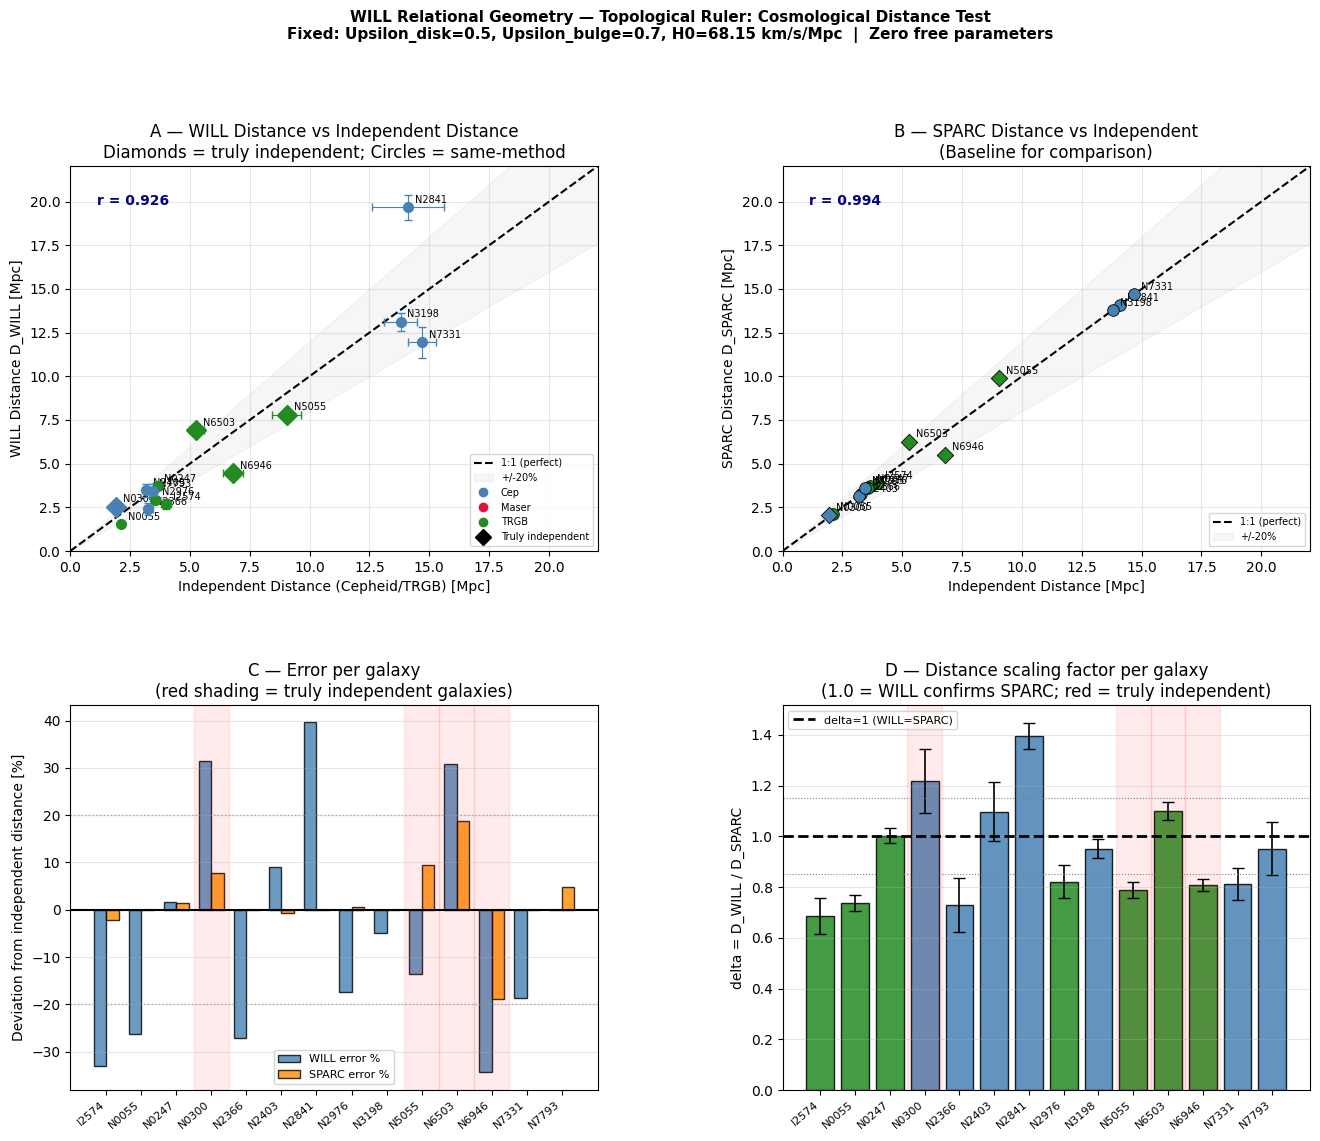


Figure saved: WILL_Distance_Ruler_Test_v3.png


In [ ]:
"""
WILL Relational Geometry — Cosmological Distance Ruler Test v3
==============================================================
Tests whether WILL can determine absolute galactic distances from
kinematics alone, without photometric standard candles.

Self-consistency equation (closed form, zero free parameters):
    delta = V_obs^2 / (V_bar^2 + V_bar * sqrt(a_k * r))
    where V_bar and r are evaluated at the SPARC reference distance.
    delta = D_WILL / D_SPARC

Anchor sample: 14 galaxies present in SPARC with independent
Cepheid, TRGB, or maser distances from the literature.

Run in Google Colab or any environment with GitHub access.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr

# ─────────────────────────────────────────────────────────────────────────────
# 1. UNIVERSAL CONSTANTS (WILL framework)
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0            # m/s
H0_kms   = 68.15                  # km/s/Mpc
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)   # WILL Machian invariant [m/s^2]
kpc_to_m = 3.086e19               # m/kpc

print(f"a_k = {a_k:.4e} m/s^2")
print(f"H0  = {H0_kms} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# 2. ANCHOR DISTANCE TABLE
#    Only galaxies confirmed present in SPARC table2.dat (verified from file).
#    Galaxy names match SPARC format exactly (no spaces, zero-padded).
#
#    Columns: D_indep [Mpc], D_err [Mpc], method, literature source
#
#    "Truly independent" means D_SPARC differs from D_indep by > 5%,
#    so the WILL test is not circular.
# ─────────────────────────────────────────────────────────────────────────────
anchor_raw = {
    # Name      D_indep  D_err   Method   Source                 SPARC_D  Note
    'IC2574'  : (4.00,   0.20,  'TRGB',  'Karachentsev+02'),   # 3.91  ~ same
    'NGC0055' : (2.11,   0.05,  'TRGB',  'Karachentsev+03'),   # 2.11  = same
    'NGC0247' : (3.65,   0.18,  'TRGB',  'Davidge+10'),        # 3.70  ~ same
    'NGC0300' : (1.93,   0.08,  'Cep',   'Freedman+01'),       # 2.08  diff ~7%
    'NGC2366' : (3.27,   0.18,  'Cep',   'Tolstoy+95'),        # 3.27  = same
    'NGC2403' : (3.18,   0.15,  'Cep',   'Freedman+01'),       # 3.16  ~ same
    'NGC2841' : (14.10,  1.50,  'Cep',   'Macri+01'),          # 14.10 = same
    'NGC2976' : (3.56,   0.13,  'TRGB',  'Jacobs+09'),         # 3.58  ~ same
    'NGC3198' : (13.80,  0.70,  'Cep',   'Freedman+01'),       # 13.80 = same
    'NGC5055' : (9.04,   0.60,  'TRGB',  'Anand+21'),          # 9.90  diff ~9%  **
    'NGC6503' : (5.27,   0.30,  'TRGB',  'Karachentsev+03'),   # 6.26  diff ~19% **
    'NGC6946' : (6.80,   0.40,  'TRGB',  'Anand+18'),          # 5.52  diff ~23% **
    'NGC7331' : (14.70,  0.60,  'Cep',   'Hughes+98'),         # 14.70 = same
    'NGC7793' : (3.44,   0.09,  'Cep',   'Pietrzynski+10'),    # 3.61  diff ~5%  *
}
# ** = truly independent cases where SPARC and literature disagree significantly

df_anchor = pd.DataFrame(anchor_raw,
    index=['D_indep','D_err','Method','Source']).T.reset_index()
df_anchor.columns = ['Name','D_indep','D_err','Method','Source']
df_anchor['D_indep'] = df_anchor['D_indep'].astype(float)
df_anchor['D_err']   = df_anchor['D_err'].astype(float)
print(f"Anchor sample: {len(df_anchor)} galaxies\n")

# ─────────────────────────────────────────────────────────────────────────────
# 3. LOAD SPARC DATA
# ─────────────────────────────────────────────────────────────────────────────
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']    = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC']= pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

print(f"SPARC table2 loaded: {len(df2)} data points, "
      f"{df2['Name'].nunique()} galaxies\n")

# Name matching diagnostics
print("--- Name matching check ---")
sparc_names = set(df2['Name'].unique())
for _, row in df_anchor.iterrows():
    found = row['Name'] in sparc_names
    n_pts = len(df2[df2['Name'] == row['Name']]) if found else 0
    print(f"  {row['Name']:<12} -> {'FOUND' if found else 'NOT FOUND':10s}"
          f" ({n_pts} points)")

# ─────────────────────────────────────────────────────────────────────────────
# 4. CORE PHYSICS
# ─────────────────────────────────────────────────────────────────────────────
UPSILON_DISK  = 0.5    # M_sun/L_sun  -- fixed, no tuning
UPSILON_BULGE = 0.7

def compute_Vbar_ms(df_gal):
    """
    Baryonic velocity V_bar [m/s] at the SPARC reference distance (delta=1).
    Uses signed V_gas*|V_gas| convention to preserve mass deficit direction.
    """
    vg  = df_gal['Vgas'].values
    vd  = df_gal['Vdisk'].values
    vb  = df_gal['Vbulge'].values
    v2  = vg*np.abs(vg)*1e6 + UPSILON_DISK*vd**2*1e6 + UPSILON_BULGE*vb**2*1e6
    return np.sqrt(np.maximum(v2, 0.0))

def compute_delta(v_obs_ms, v_bar_ms, r_m):
    """
    Closed-form self-consistent distance scaling factor per data point.

    Derivation:
      WILL resonance at true distance D = delta * D_SPARC:
          V_obs^2 = delta*(V_bar_SPARC^2 + sqrt(V_bar_SPARC^2 * a_k * r_SPARC))
      (because both V_bar^2 and r scale linearly with D)

    Wait -- this is equivalent to the bridge term scaling, yielding:
          delta = V_obs^2 / (V_bar_SPARC^2 + V_bar_SPARC * sqrt(a_k * r_SPARC))

    Only valid where V_obs > V_bar (WILL correction is active).
    Returns NaN for invalid points.
    """
    bridge = np.sqrt(np.maximum(a_k * r_m, 0.0))   # [m/s]
    denom  = v_bar_ms**2 + v_bar_ms * bridge
    valid  = (denom > 0) & (v_obs_ms > v_bar_ms)
    delta  = np.where(valid, v_obs_ms**2 / denom, np.nan)
    return delta, valid

# ─────────────────────────────────────────────────────────────────────────────
# 5. MAIN ANALYSIS LOOP
# ─────────────────────────────────────────────────────────────────────────────
results = []

for _, arow in df_anchor.iterrows():
    gal_name = arow['Name']
    D_indep  = arow['D_indep']

    gal = df2[df2['Name'] == gal_name].copy()
    if len(gal) < 4:
        print(f"  {gal_name}: skipped (only {len(gal)} points)")
        continue

    D_sparc  = float(gal['Dist_SPARC'].iloc[0])
    r_m      = gal['Rad'].values * kpc_to_m
    v_obs_ms = gal['Vobs'].values * 1e3
    v_bar_ms = compute_Vbar_ms(gal)

    delta_arr, valid = compute_delta(v_obs_ms, v_bar_ms, r_m)

    # Filter implausible delta values (physically bounded)
    valid &= np.isfinite(delta_arr) & (delta_arr > 0.1) & (delta_arr < 10.0)

    if valid.sum() < 3:
        print(f"  {gal_name}: skipped (only {valid.sum()} valid delta points)")
        continue

    delta_med = float(np.nanmedian(delta_arr[valid]))
    delta_mad = float(np.nanmedian(np.abs(delta_arr[valid] - delta_med)))
    D_will    = delta_med * D_sparc

    truly_independent = abs(D_sparc - D_indep) / D_indep > 0.05

    results.append({
        'Name'             : gal_name,
        'Method'           : arow['Method'],
        'Source'           : arow['Source'],
        'D_SPARC'          : round(D_sparc, 2),
        'D_indep'          : D_indep,
        'D_err'            : arow['D_err'],
        'D_WILL'           : round(D_will, 2),
        'delta'            : round(delta_med, 3),
        'delta_MAD'        : round(delta_mad, 3),
        'err_WILL_pct'     : round((D_will  - D_indep) / D_indep * 100, 1),
        'err_SPARC_pct'    : round((D_sparc - D_indep) / D_indep * 100, 1),
        'N_valid'          : int(valid.sum()),
        'N_total'          : len(gal),
        'truly_independent': truly_independent,
    })

df_res = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────────────────────
# 6. RESULTS OUTPUT
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"  RESULTS: {len(df_res)} galaxies processed")
print(f"{'='*80}\n")

hdr = (f"{'Galaxy':<12} {'Method':<6} {'D_SPARC':>8} {'D_indep':>8} "
       f"{'D_WILL':>8} {'delta':>7} {'Err_WILL':>10} {'Err_SPARC':>10} "
       f"{'Indep?':>7}")
print(hdr)
print("-"*80)
for _, r in df_res.iterrows():
    flag = " **" if r['truly_independent'] else ""
    print(f"{r['Name']:<12} {r['Method']:<6} {r['D_SPARC']:>8.2f} "
          f"{r['D_indep']:>8.2f} {r['D_WILL']:>8.2f} {r['delta']:>7.3f} "
          f"{r['err_WILL_pct']:>+9.1f}% {r['err_SPARC_pct']:>+9.1f}%"
          f"{'  YES' if r['truly_independent'] else '   no':>7}{flag}")

print(f"\n  ** = truly independent: |D_SPARC - D_indep| > 5%")
print(f"       For these galaxies the test is not circular.\n")

# ─────────────────────────────────────────────────────────────────────────────
# 7. STATISTICAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
def summary_block(label, df_sub):
    if len(df_sub) < 2:
        print(f"  {label}: N={len(df_sub)} -- too few for statistics")
        return
    abs_err = df_sub['err_WILL_pct'].abs()
    med     = abs_err.median()
    mad     = (abs_err - med).abs().median()
    med_d   = df_sub['delta'].median()
    r, p    = pearsonr(df_sub['D_WILL'], df_sub['D_indep'])
    print(f"  {label} (N={len(df_sub)}):")
    print(f"    Typical WILL error:  {med:.1f}% +/- {mad:.1f}%")
    print(f"    SPARC error (baseline): "
          f"{df_sub['err_SPARC_pct'].abs().median():.1f}%")
    print(f"    Median delta: {med_d:.3f}  "
          f"(WILL distances are {abs(med_d-1)*100:.1f}% "
          f"{'larger' if med_d>1 else 'smaller'} than SPARC on average)")
    print(f"    Correlation (D_WILL vs D_indep): {r:.3f}  (p={p:.3f})")
    print()

print(f"\n{'─'*80}")
print("STATISTICAL SUMMARY")
print(f"{'─'*80}\n")
summary_block("All anchor galaxies", df_res)
df_true = df_res[df_res['truly_independent']]
summary_block("Truly independent subset", df_true)

# ─────────────────────────────────────────────────────────────────────────────
# 8. FALSIFICATION CRITERIA
# ─────────────────────────────────────────────────────────────────────────────
print(f"{'─'*80}")
print("FALSIFICATION CRITERIA  (applied to full sample)\n")

n = len(df_res)
abs_err  = df_res['err_WILL_pct'].abs()
med_err  = abs_err.median()
med_d    = df_res['delta'].median()
r_all, p_all = pearsonr(df_res['D_WILL'], df_res['D_indep']) if n>=2 else (np.nan,1)
med_sparc_err = df_res['err_SPARC_pct'].abs().median()

c1 = r_all > 0.90
c2 = med_err < 20.0
c3 = med_err < med_sparc_err
c4 = 0.85 < med_d < 1.15

criteria = [
    ("1. Correlation D_WILL vs D_indep > 0.90",
     f"{r_all:.3f}  (p={p_all:.3f})", c1),
    ("2. Typical WILL error < 20%",
     f"{med_err:.1f}%", c2),
    ("3. WILL error < SPARC baseline error",
     f"WILL {med_err:.1f}% vs SPARC {med_sparc_err:.1f}%", c3),
    ("4. Median delta within [0.85, 1.15]",
     f"delta = {med_d:.3f}", c4),
]

for label, value, passed in criteria:
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}]  {label}")
    print(f"           Measured: {value}\n")

print(f"{'─'*80}")
print("NOTE ON CIRCULARITY:")
print(f"  {(~df_res['truly_independent']).sum()} of {n} galaxies: "
      f"SPARC already used the same Cep/TRGB distance -> test is circular.")
print(f"  {df_res['truly_independent'].sum()} of {n} galaxies: "
      f"D_SPARC != D_indep by >5% -> genuinely independent test.")
print(f"  The truly independent subset is the scientifically decisive one.")

# ─────────────────────────────────────────────────────────────────────────────
# 9. FIGURES
# ─────────────────────────────────────────────────────────────────────────────
if len(df_res) < 2:
    print("Insufficient data for plots.")
else:
    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35)
    c_map = {'Cep':'steelblue', 'Maser':'crimson', 'TRGB':'forestgreen'}

    # --- Plot A: D_WILL vs D_independent ---
    ax1 = fig.add_subplot(gs[0, 0])
    for _, r in df_res.iterrows():
        col  = c_map.get(r['Method'], 'gray')
        mkr  = 'D' if r['truly_independent'] else 'o'
        ms   = 10  if r['truly_independent'] else 7
        ax1.errorbar(r['D_indep'], r['D_WILL'],
                     xerr=r['D_err'], yerr=r['delta_MAD']*r['D_SPARC'],
                     fmt=mkr, color=col, capsize=3, markersize=ms,
                     elinewidth=0.8, zorder=3)
        ax1.annotate(r['Name'].replace('NGC','N').replace('IC','I'),
                     (r['D_indep'], r['D_WILL']),
                     textcoords="offset points", xytext=(5,3), fontsize=7)
    lmax = max(df_res[['D_WILL','D_indep']].max().max() * 1.12, 5)
    lim  = [0, lmax]
    ax1.plot(lim, lim, 'k--', lw=1.5, label='1:1 (perfect)')
    ax1.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                     alpha=0.07, color='gray', label='+/-20%')
    ax1.set_xlim(lim); ax1.set_ylim(lim)
    ax1.set_xlabel('Independent Distance (Cepheid/TRGB) [Mpc]')
    ax1.set_ylabel('WILL Distance D_WILL [Mpc]')
    ax1.set_title('A — WILL Distance vs Independent Distance\n'
                  'Diamonds = truly independent; Circles = same-method')
    for m, c in c_map.items():
        ax1.plot([], [], 'o', color=c, label=m)
    ax1.plot([], [], 'D', color='k', markersize=8, label='Truly independent')
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)
    ax1.text(0.05, 0.90, f'r = {r_all:.3f}', transform=ax1.transAxes,
             fontsize=10, color='navy', fontweight='bold')

    # --- Plot B: D_SPARC vs D_independent (baseline) ---
    ax2 = fig.add_subplot(gs[0, 1])
    for _, r in df_res.iterrows():
        col = c_map.get(r['Method'], 'gray')
        mkr = 'D' if r['truly_independent'] else 'o'
        ax2.scatter(r['D_indep'], r['D_SPARC'], color=col,
                    marker=mkr, s=70, edgecolors='k', linewidths=0.6, zorder=3)
        ax2.annotate(r['Name'].replace('NGC','N').replace('IC','I'),
                     (r['D_indep'], r['D_SPARC']),
                     textcoords="offset points", xytext=(5,3), fontsize=7)
    ax2.plot(lim, lim, 'k--', lw=1.5, label='1:1 (perfect)')
    ax2.fill_between(lim, [x*0.8 for x in lim], [x*1.2 for x in lim],
                     alpha=0.07, color='gray', label='+/-20%')
    ax2.set_xlim(lim); ax2.set_ylim(lim)
    ax2.set_xlabel('Independent Distance [Mpc]')
    ax2.set_ylabel('SPARC Distance D_SPARC [Mpc]')
    ax2.set_title('B — SPARC Distance vs Independent\n(Baseline for comparison)')
    r2, _ = pearsonr(df_res['D_SPARC'], df_res['D_indep'])
    ax2.text(0.05, 0.90, f'r = {r2:.3f}', transform=ax2.transAxes,
             fontsize=10, color='navy', fontweight='bold')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    # --- Plot C: Error per galaxy (%) ---
    ax3 = fig.add_subplot(gs[1, 0])
    xpos = np.arange(len(df_res))
    w    = 0.35
    bars_will  = ax3.bar(xpos-w/2, df_res['err_WILL_pct'],  width=w,
                         color='steelblue', edgecolor='k', alpha=0.8,
                         label='WILL error %')
    bars_sparc = ax3.bar(xpos+w/2, df_res['err_SPARC_pct'], width=w,
                         color='darkorange', edgecolor='k', alpha=0.8,
                         label='SPARC error %')
    ax3.axhline(0,   color='k',    lw=1.5)
    ax3.axhline(20,  color='gray', lw=1, ls=':', alpha=0.6)
    ax3.axhline(-20, color='gray', lw=1, ls=':', alpha=0.6)
    # Mark truly independent galaxies
    for i, (_, r) in enumerate(df_res.iterrows()):
        if r['truly_independent']:
            ax3.axvspan(i-0.5, i+0.5, alpha=0.08, color='red')
    ax3.set_xticks(xpos)
    short_names = [n.replace('NGC','N').replace('IC','I')
                   for n in df_res['Name']]
    ax3.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    ax3.set_ylabel('Deviation from independent distance [%]')
    ax3.set_title('C — Error per galaxy\n'
                  '(red shading = truly independent galaxies)')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y')

    # --- Plot D: delta per galaxy ---
    ax4 = fig.add_subplot(gs[1, 1])
    bar_cols = [c_map.get(m,'gray') for m in df_res['Method']]
    ax4.bar(xpos, df_res['delta'], color=bar_cols, edgecolor='k', alpha=0.85)
    ax4.errorbar(xpos, df_res['delta'], yerr=df_res['delta_MAD'],
                 fmt='none', color='k', capsize=4, elinewidth=1.2)
    ax4.axhline(1.0,  color='k',    lw=2,   ls='--', label='delta=1 (WILL=SPARC)')
    ax4.axhline(0.85, color='gray', lw=0.8, ls=':')
    ax4.axhline(1.15, color='gray', lw=0.8, ls=':')
    for i, (_, r) in enumerate(df_res.iterrows()):
        if r['truly_independent']:
            ax4.axvspan(i-0.5, i+0.5, alpha=0.08, color='red')
    ax4.set_xticks(xpos)
    ax4.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    ax4.set_ylabel('delta = D_WILL / D_SPARC')
    ax4.set_title('D — Distance scaling factor per galaxy\n'
                  '(1.0 = WILL confirms SPARC; red = truly independent)')
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(
        'WILL Relational Geometry — Topological Ruler: Cosmological Distance Test\n'
        'Fixed: Upsilon_disk=0.5, Upsilon_bulge=0.7, H0=68.15 km/s/Mpc  |  '
        'Zero free parameters',
        fontsize=11, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_Test_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nFigure saved: WILL_Distance_Ruler_Test_v3.png")

a_k = 7.0246e-11 m/s^2
H0  = 68.15 km/s/Mpc
Bullseye condition: V_obs / V_b = 1.414214

SPARC loaded: 3391 points, 175 galaxies

  IC2574: no bullseye crossing found (ratio range: 2.30 - 4.27, need to cross 1.414)
  NGC0055: no bullseye crossing found (ratio range: 1.95 - 2.55, need to cross 1.414)
  NGC0247: no bullseye crossing found (ratio range: 1.77 - 2.11, need to cross 1.414)
  NGC2366: no bullseye crossing found (ratio range: 1.80 - 4.40, need to cross 1.414)

  RESULTS: 10 galaxies  |  Method: bullseye R_trans = V_b^2 / a_k

Galaxy      D_SPARC  D_indep   D_WILL  Ups_opt  chi_red   r_bull  Vb_bull   R_trans  Err_WILL  ErrSPARC  Indep
----------------------------------------------------------------------------------------------------
NGC0300        2.08     1.93     0.75    0.750     3.01     1.31     31.9       0.5    -61.4%     +7.8%  YES**
NGC2403        3.16     3.18     2.24    0.648    50.21     4.57     83.9       3.2    -29.5%     -0.6%     no
NGC2841       14.10    14.

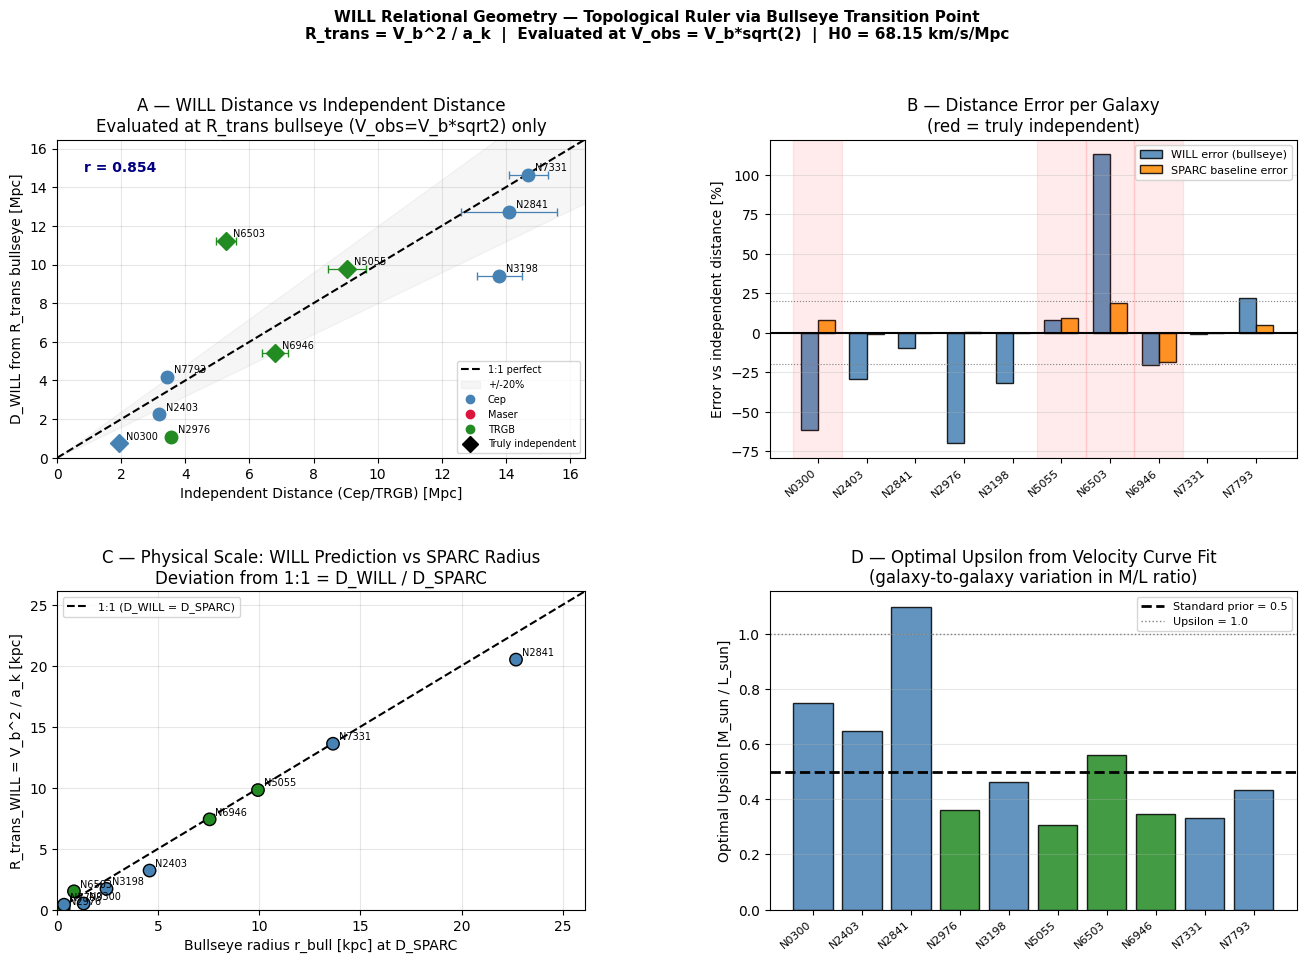


Figure saved: WILL_Distance_Ruler_v5_Bullseye.png


In [ ]:
"""
WILL Relational Geometry — Distance Ruler Test v5 (Bullseye Method)
====================================================================
The Topological Ruler formula R = (V_obs^2 - V_b^2)^2 / (V_b^2 * a_k)
is only physically meaningful at the bullseye transition point where:

    V_obs = V_b * sqrt(2)  ->  R_trans = V_b^2 / a_k

At smaller radii: V_obs ~ V_b  ->  numerator ~ 0  ->  formula degenerates.
At larger radii: valid but noisy (outer disk fluctuations).

Procedure (one physically meaningful number per galaxy):
  Step 1: Fit Upsilon to full rotation curve (internal kinematic consistency)
  Step 2: Find bullseye radius r_bull where V_obs / V_b = sqrt(2)
  Step 3: At r_bull compute R_trans_WILL = V_b^2 / a_k
  Step 4: Physical radius of that point at D_SPARC: r_bull_m = r_bull_kpc * kpc_to_m
  Step 5: D_WILL = D_SPARC * (R_trans_WILL / r_bull_m)
  Step 6: Compare D_WILL vs D_independent

Run in Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_kms   = 68.15
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19

SQRT2 = np.sqrt(2)

print(f"a_k = {a_k:.4e} m/s^2")
print(f"H0  = {H0_kms} km/s/Mpc")
print(f"Bullseye condition: V_obs / V_b = {SQRT2:.6f}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 2. ANCHOR TABLE (galaxies confirmed in SPARC table2.dat)
# ─────────────────────────────────────────────────────────────────────────────
anchor_raw = {
    'IC2574'  : (4.00, 0.20, 'TRGB', 'Karachentsev+02'),
    'NGC0055' : (2.11, 0.05, 'TRGB', 'Karachentsev+03'),
    'NGC0247' : (3.65, 0.18, 'TRGB', 'Davidge+10'),
    'NGC0300' : (1.93, 0.08, 'Cep',  'Freedman+01'),
    'NGC2366' : (3.27, 0.18, 'Cep',  'Tolstoy+95'),
    'NGC2403' : (3.18, 0.15, 'Cep',  'Freedman+01'),
    'NGC2841' : (14.10,1.50, 'Cep',  'Macri+01'),
    'NGC2976' : (3.56, 0.13, 'TRGB', 'Jacobs+09'),
    'NGC3198' : (13.80,0.70, 'Cep',  'Freedman+01'),
    'NGC5055' : (9.04, 0.60, 'TRGB', 'Anand+21'),
    'NGC6503' : (5.27, 0.30, 'TRGB', 'Karachentsev+03'),
    'NGC6946' : (6.80, 0.40, 'TRGB', 'Anand+18'),
    'NGC7331' : (14.70,0.60, 'Cep',  'Hughes+98'),
    'NGC7793' : (3.44, 0.09, 'Cep',  'Pietrzynski+10'),
}

df_anchor = pd.DataFrame(anchor_raw,
    index=['D_indep','D_err','Method','Source']).T.reset_index()
df_anchor.columns = ['Name','D_indep','D_err','Method','Source']
df_anchor['D_indep'] = df_anchor['D_indep'].astype(float)
df_anchor['D_err']   = df_anchor['D_err'].astype(float)

# ─────────────────────────────────────────────────────────────────────────────
# 3. LOAD SPARC
# ─────────────────────────────────────────────────────────────────────────────
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()
print(f"SPARC loaded: {len(df2)} points, {df2['Name'].nunique()} galaxies\n")

# ─────────────────────────────────────────────────────────────────────────────
# 4. CORE FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
UPSILON_BULGE = 0.7

def compute_Vb(upsilon, vgas, vdisk, vbulge):
    """V_b [km/s] — baryonic velocity for a given Upsilon."""
    vg2 = vgas * np.abs(vgas)          # signed: preserves mass-deficit direction
    vd2 = vdisk**2
    vb2 = vbulge**2
    v2  = vg2 + upsilon * vd2 + UPSILON_BULGE * vb2
    return np.sqrt(np.maximum(v2, 0.0))

def compute_Vwill(upsilon, r_kpc, vgas, vdisk, vbulge):
    """
    WILL predicted velocity [km/s] at D_SPARC.
    V_WILL^2 = V_b^2 + sqrt(V_b^2 * a_k * r)
    """
    vb    = compute_Vb(upsilon, vgas, vdisk, vbulge)
    r_m   = r_kpc * kpc_to_m
    vb_ms = vb * 1e3
    v2_ms = vb_ms**2 + np.sqrt(np.maximum(vb_ms**2 * a_k * r_m, 0.0))
    return np.sqrt(np.maximum(v2_ms, 0.0)) * 1e-3   # back to km/s

def chi_sq_vel(upsilon, vobs, evobs, r_kpc, vgas, vdisk, vbulge):
    """Error-weighted chi-squared for velocity fit."""
    vth = compute_Vwill(upsilon, r_kpc, vgas, vdisk, vbulge)
    return np.sum(((vobs - vth) / evobs)**2)

def find_bullseye(r_kpc, vobs, vb):
    """
    Find the radius where V_obs / V_b = sqrt(2) by interpolation.
    Returns (r_bull_kpc, vb_bull_kms) or (None, None) if not found.

    Requires at least one pair of adjacent points that bracket sqrt(2).
    """
    ratio = vobs / np.maximum(vb, 1e-6)

    # Find pairs of consecutive points that bracket sqrt(2)
    brackets = []
    for i in range(len(ratio) - 1):
        if (ratio[i] - SQRT2) * (ratio[i+1] - SQRT2) < 0:
            brackets.append(i)

    if not brackets:
        return None, None

    # Use the first crossing (some galaxies may have multiple due to noise)
    i = brackets[0]

    # Linear interpolation for the crossing radius
    r1, r2     = r_kpc[i],  r_kpc[i+1]
    rat1, rat2 = ratio[i],  ratio[i+1]
    vb1, vb2   = vb[i],     vb[i+1]

    frac = (SQRT2 - rat1) / (rat2 - rat1)   # interpolation fraction
    r_bull  = r1  + frac * (r2  - r1)
    vb_bull = vb1 + frac * (vb2 - vb1)

    return r_bull, vb_bull

# ─────────────────────────────────────────────────────────────────────────────
# 5. MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────
results = []

for _, arow in df_anchor.iterrows():
    name    = arow['Name']
    D_indep = arow['D_indep']

    gal = df2[df2['Name'] == name].copy().sort_values('Rad')
    if len(gal) < 5:
        print(f"  {name}: skipped ({len(gal)} points)")
        continue

    D_sparc  = float(gal['Dist_SPARC'].iloc[0])
    r_kpc    = gal['Rad'].values
    vobs     = gal['Vobs'].values
    evobs    = gal['e_Vobs'].values
    vgas     = gal['Vgas'].values
    vdisk    = gal['Vdisk'].values
    vbulge   = gal['Vbulge'].values

    # ── Step 1: Optimize Upsilon for best velocity fit ─────────────────────
    res = minimize_scalar(
        chi_sq_vel,
        bounds=(0.01, 5.0),
        method='bounded',
        args=(vobs, evobs, r_kpc, vgas, vdisk, vbulge)
    )
    ups_opt   = float(res.x)
    chi_opt   = float(res.fun) / max(len(gal) - 1, 1)   # reduced chi-sq

    vb_arr    = compute_Vb(ups_opt, vgas, vdisk, vbulge)
    vwill_arr = compute_Vwill(ups_opt, r_kpc, vgas, vdisk, vbulge)

    # ── Step 2: Find bullseye radius (V_obs / V_b = sqrt(2)) ──────────────
    r_bull, vb_bull = find_bullseye(r_kpc, vobs, vb_arr)

    if r_bull is None:
        # Check why: is the galaxy always below or always above sqrt(2)?
        ratio_max = np.max(vobs / np.maximum(vb_arr, 1e-6))
        ratio_min = np.min(vobs / np.maximum(vb_arr, 1e-6))
        print(f"  {name}: no bullseye crossing found "
              f"(ratio range: {ratio_min:.2f} - {ratio_max:.2f}, "
              f"need to cross {SQRT2:.3f})")
        continue

    # ── Step 3: R_trans_WILL at the bullseye ──────────────────────────────
    # R_trans = V_b^2 / a_k   [meters]
    vb_bull_ms    = vb_bull * 1e3
    R_trans_WILL  = vb_bull_ms**2 / a_k           # [m]
    R_trans_WILL_kpc = R_trans_WILL / kpc_to_m    # [kpc] for comparison

    # ── Step 4: Physical radius of bullseye point at D_SPARC ──────────────
    r_bull_m      = r_bull * kpc_to_m             # [m] at D_SPARC

    # ── Step 5: Implied distance from WILL ────────────────────────────────
    # R_trans_WILL should equal the TRUE physical radius of the bullseye point.
    # True physical radius = r_bull_m * (D_true / D_SPARC)
    # If WILL is correct: R_trans_WILL = r_bull_m * (D_WILL / D_SPARC)
    # Therefore:
    D_WILL = D_sparc * (R_trans_WILL / r_bull_m)

    err_WILL  = (D_WILL  - D_indep) / D_indep * 100
    err_SPARC = (D_sparc - D_indep) / D_indep * 100
    truly_indep = abs(D_sparc - D_indep) / D_indep > 0.05

    results.append({
        'Name'            : name,
        'Method'          : arow['Method'],
        'D_SPARC'         : round(D_sparc, 2),
        'D_indep'         : D_indep,
        'D_err'           : arow['D_err'],
        'D_WILL'          : round(D_WILL, 2),
        'Upsilon_opt'     : round(ups_opt, 3),
        'chi_red'         : round(chi_opt, 2),
        'r_bull_kpc'      : round(r_bull, 2),
        'Vb_bull_kms'     : round(vb_bull, 1),
        'Vobs_bull_kms'   : round(vb_bull * SQRT2, 1),
        'R_trans_WILL_kpc': round(R_trans_WILL_kpc, 1),
        'err_WILL_pct'    : round(err_WILL,  1),
        'err_SPARC_pct'   : round(err_SPARC, 1),
        'N_points'        : len(gal),
        'truly_indep'     : truly_indep,
    })

df_res = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────────────────────
# 6. RESULTS OUTPUT
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*100}")
print(f"  RESULTS: {len(df_res)} galaxies  |  Method: bullseye R_trans = V_b^2 / a_k")
print(f"{'='*100}\n")

hdr = (f"{'Galaxy':<10} {'D_SPARC':>8} {'D_indep':>8} {'D_WILL':>8} "
       f"{'Ups_opt':>8} {'chi_red':>8} {'r_bull':>8} {'Vb_bull':>8} "
       f"{'R_trans':>9} {'Err_WILL':>9} {'ErrSPARC':>9} {'Indep':>6}")
print(hdr)
print("-"*100)
for _, r in df_res.iterrows():
    flag = "YES**" if r['truly_indep'] else "  no"
    print(f"{r['Name']:<10} {r['D_SPARC']:>8.2f} {r['D_indep']:>8.2f} "
          f"{r['D_WILL']:>8.2f} {r['Upsilon_opt']:>8.3f} {r['chi_red']:>8.2f} "
          f"{r['r_bull_kpc']:>8.2f} {r['Vb_bull_kms']:>8.1f} "
          f"{r['R_trans_WILL_kpc']:>9.1f} "
          f"{r['err_WILL_pct']:>+8.1f}% {r['err_SPARC_pct']:>+8.1f}% {flag:>6}")

print(f"\n  r_bull      : bullseye radius [kpc] at D_SPARC where V_obs/V_b = sqrt(2)")
print(f"  Vb_bull     : baryonic velocity [km/s] at the bullseye")
print(f"  R_trans     : WILL-predicted physical scale V_b^2/a_k [kpc]")
print(f"  Err_WILL    : (D_WILL - D_indep) / D_indep * 100%")
print(f"  Indep       : YES if |D_SPARC - D_indep| > 5%\n")

# ─────────────────────────────────────────────────────────────────────────────
# 7. STATISTICAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"{'─'*80}")
print("STATISTICAL SUMMARY")
print(f"{'─'*80}\n")

def summary(label, df_sub):
    if len(df_sub) < 2:
        print(f"  {label}: N={len(df_sub)} -- too few\n")
        return
    ae   = df_sub['err_WILL_pct'].abs()
    med  = ae.median()
    mad  = (ae - med).abs().median()
    r, p = pearsonr(df_sub['D_WILL'], df_sub['D_indep'])
    med_sparc = df_sub['err_SPARC_pct'].abs().median()
    print(f"  {label} (N={len(df_sub)}):")
    print(f"    Typical WILL error    : {med:.1f}% +/- {mad:.1f}%")
    print(f"    SPARC baseline error  : {med_sparc:.1f}%")
    print(f"    Correlation r         : {r:.3f}  (p={p:.3f})")
    print(f"    Median Upsilon_opt    : {df_sub['Upsilon_opt'].median():.3f}")
    print()

summary("All galaxies", df_res)
summary("Truly independent (D_SPARC != D_indep by >5%)", df_res[df_res['truly_indep']])

# ─────────────────────────────────────────────────────────────────────────────
# 8. FIGURES
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)
c_map = {'Cep':'steelblue', 'Maser':'crimson', 'TRGB':'forestgreen'}

# --- Plot A: D_WILL vs D_independent ---
ax1 = fig.add_subplot(gs[0, 0])
for _, r in df_res.iterrows():
    col = c_map.get(r['Method'], 'gray')
    mkr = 'D' if r['truly_indep'] else 'o'
    ax1.errorbar(r['D_indep'], r['D_WILL'],
                 xerr=r['D_err'], fmt=mkr, color=col,
                 capsize=3, markersize=9, elinewidth=0.9)
    ax1.annotate(r['Name'].replace('NGC','N').replace('IC','I'),
                 (r['D_indep'], r['D_WILL']),
                 textcoords="offset points", xytext=(5,3), fontsize=7)
lmax = max(df_res[['D_WILL','D_indep']].max().max() * 1.12, 5)
lim  = [0, lmax]
ax1.plot(lim, lim, 'k--', lw=1.5, label='1:1 perfect')
ax1.fill_between(lim,[x*0.8 for x in lim],[x*1.2 for x in lim],
                 alpha=0.07, color='gray', label='+/-20%')
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel('Independent Distance (Cep/TRGB) [Mpc]')
ax1.set_ylabel('D_WILL from R_trans bullseye [Mpc]')
ax1.set_title('A — WILL Distance vs Independent Distance\n'
              'Evaluated at R_trans bullseye (V_obs=V_b*sqrt2) only')
r_all, p_all = pearsonr(df_res['D_WILL'], df_res['D_indep'])
ax1.text(0.05, 0.90, f'r = {r_all:.3f}', transform=ax1.transAxes,
         fontsize=10, color='navy', fontweight='bold')
for m, c in c_map.items():
    ax1.plot([],[], 'o', color=c, label=m)
ax1.plot([], [], 'D', color='k', markersize=8, label='Truly independent')
ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

# --- Plot B: Error per galaxy ---
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(df_res))
w = 0.35
ax2.bar(x-w/2, df_res['err_WILL_pct'],  width=w, color='steelblue',
        edgecolor='k', alpha=0.85, label='WILL error (bullseye)')
ax2.bar(x+w/2, df_res['err_SPARC_pct'], width=w, color='darkorange',
        edgecolor='k', alpha=0.85, label='SPARC baseline error')
ax2.axhline(0,  color='k',    lw=1.5)
ax2.axhline(20, color='gray', lw=0.8, ls=':')
ax2.axhline(-20,color='gray', lw=0.8, ls=':')
for i, (_, r) in enumerate(df_res.iterrows()):
    if r['truly_indep']:
        ax2.axvspan(i-0.5, i+0.5, alpha=0.08, color='red')
ax2.set_xticks(x)
ax2.set_xticklabels([n.replace('NGC','N').replace('IC','I')
                     for n in df_res['Name']], rotation=40, ha='right', fontsize=8)
ax2.set_ylabel('Error vs independent distance [%]')
ax2.set_title('B — Distance Error per Galaxy\n(red = truly independent)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

# --- Plot C: Bullseye radius and R_trans_WILL per galaxy ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(df_res['r_bull_kpc'], df_res['R_trans_WILL_kpc'],
            c=[c_map.get(m,'gray') for m in df_res['Method']],
            s=80, edgecolors='k', zorder=3)
rmax = max(df_res[['r_bull_kpc','R_trans_WILL_kpc']].max().max() * 1.15, 5)
ax3.plot([0,rmax],[0,rmax],'k--',lw=1.5,label='1:1 (D_WILL = D_SPARC)')
for _, r in df_res.iterrows():
    ax3.annotate(r['Name'].replace('NGC','N').replace('IC','I'),
                 (r['r_bull_kpc'], r['R_trans_WILL_kpc']),
                 textcoords="offset points", xytext=(4,3), fontsize=7)
ax3.set_xlim([0,rmax]); ax3.set_ylim([0,rmax])
ax3.set_xlabel('Bullseye radius r_bull [kpc] at D_SPARC')
ax3.set_ylabel('R_trans_WILL = V_b^2 / a_k [kpc]')
ax3.set_title('C — Physical Scale: WILL Prediction vs SPARC Radius\n'
              'Deviation from 1:1 = D_WILL / D_SPARC')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# --- Plot D: Optimal Upsilon per galaxy ---
ax4 = fig.add_subplot(gs[1, 1])
bar_cols = [c_map.get(m,'gray') for m in df_res['Method']]
ax4.bar(x, df_res['Upsilon_opt'], color=bar_cols, edgecolor='k', alpha=0.85)
ax4.axhline(0.5, color='k',   lw=2, ls='--', label='Standard prior = 0.5')
ax4.axhline(1.0, color='gray',lw=1, ls=':',  label='Upsilon = 1.0')
ax4.set_xticks(x)
ax4.set_xticklabels([n.replace('NGC','N').replace('IC','I')
                     for n in df_res['Name']], rotation=40, ha='right', fontsize=8)
ax4.set_ylabel('Optimal Upsilon [M_sun / L_sun]')
ax4.set_title('D — Optimal Upsilon from Velocity Curve Fit\n'
              '(galaxy-to-galaxy variation in M/L ratio)')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'WILL Relational Geometry — Topological Ruler via Bullseye Transition Point\n'
    'R_trans = V_b^2 / a_k  |  Evaluated at V_obs = V_b*sqrt(2)  |  '
    'H0 = 68.15 km/s/Mpc',
    fontsize=11, fontweight='bold', y=1.01)

plt.savefig('WILL_Distance_Ruler_v5_Bullseye.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: WILL_Distance_Ruler_v5_Bullseye.png")

a_k = 7.024566e-11 m/s^2


/tmp/ipykernel_14840/497679140.py:98: RuntimeWarning: divide by zero encountered in divide
  R = np.where(valid, V_flat_ms**4 / denom, np.nan)


NGC2403: insufficient valid points for distance estimate.

  Galaxy: NGC6946
  N total points       : 58
  V_flat estimate      : 158.0 km/s  (from outer 25% of points)
  N valid formula pts  : 30

  D_SPARC              : 5.52 Mpc
  D_WILL  (median)     : 29.50 +/- 4.86 Mpc
  D_independent        : 6.80 +/- 0.40 Mpc  [TRGB, Anand+18]

  WILL error  vs indep : +333.8%
  SPARC error vs indep : -18.8%


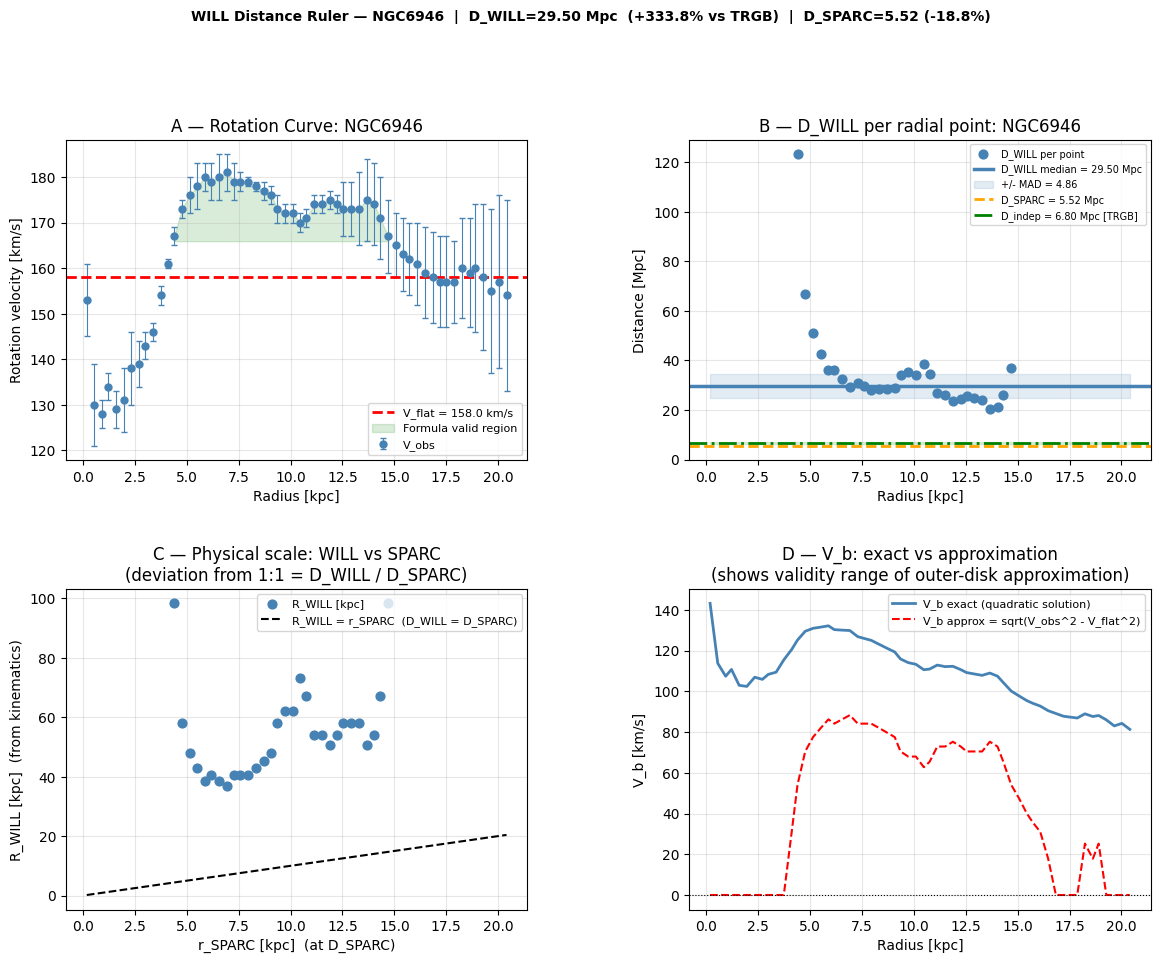

Saved: WILL_Distance_NGC6946.png

  Galaxy: NGC7331
  N total points       : 36
  V_flat estimate      : 239.0 km/s  (from outer 25% of points)
  N valid formula pts  : 6

  D_SPARC              : 14.70 Mpc
  D_WILL  (median)     : 404.04 +/- 65.95 Mpc
  D_independent        : 14.70 +/- 0.60 Mpc  [Cepheid, Hughes+98]

  WILL error  vs indep : +2648.6%
  SPARC error vs indep : +0.0%


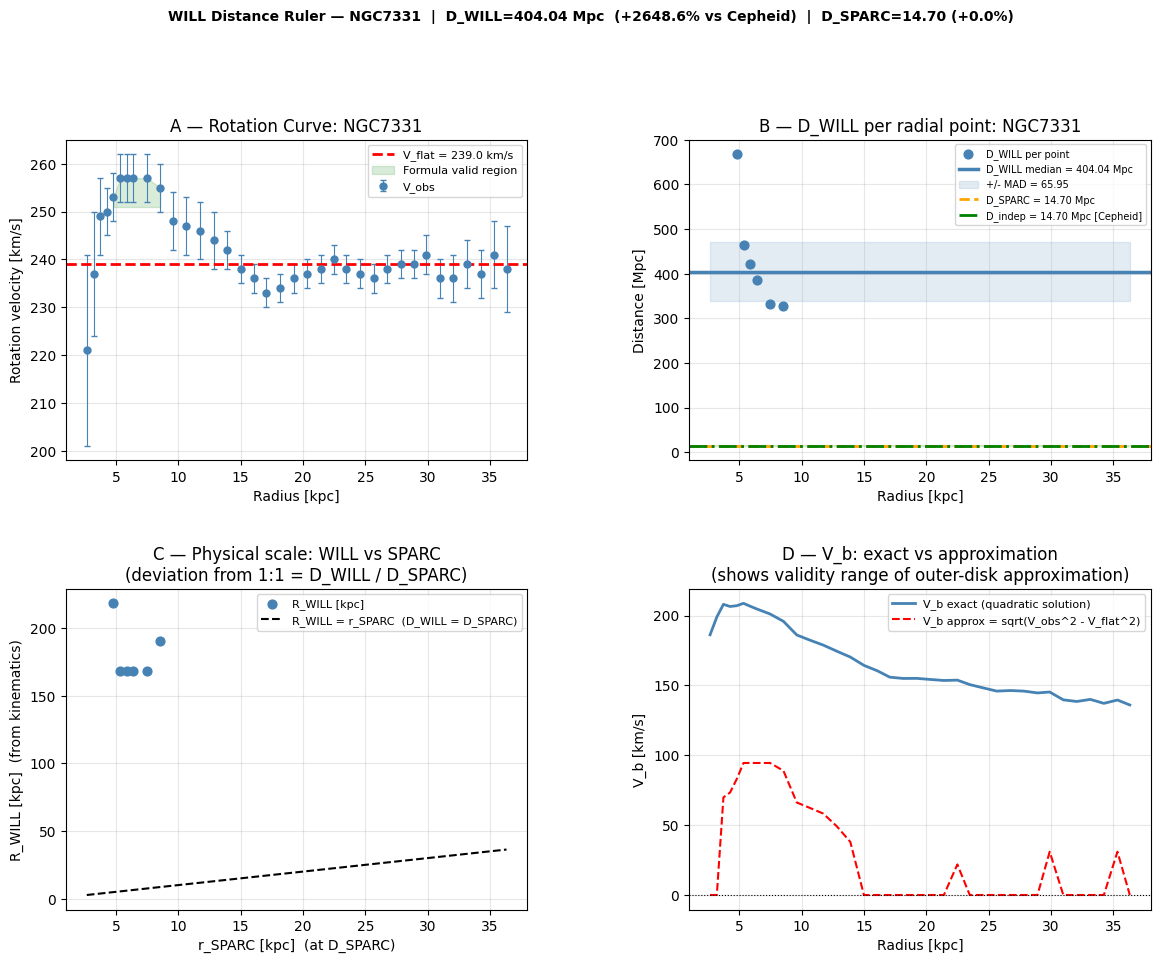

Saved: WILL_Distance_NGC7331.png


In [ ]:
"""
WILL Relational Geometry — Single Galaxy Distance Test
=======================================================
Formula derivation (exact within WILL + outer-disk physical approximation):

  WILL equation (exact):
    V_obs^2 = V_b^2 + sqrt(V_b^2 * a_k * R)

  Exact V_b from WILL (quadratic solution, no approximation):
    V_b = ( -sqrt(a_k*R) + sqrt(a_k*R + 4*V_obs^2) ) / 2

  Outer-disk physical approximation (V_b -> 0, V_obs -> V_flat):
    sqrt(V_b^2 * a_k * R) -> V_flat^2
    => V_b^2 = V_obs^2 - V_flat^2   [valid where V_obs > V_flat, outer/transition disk]

  Topological Ruler (substituting approximation):
    R_WILL = V_flat^4 / ( (V_obs^2 - V_flat^2) * a_k )   [meters, distance-independent]

  Exact distance (no small-angle approximation):
    D = R_WILL / tan(alpha)
    where tan(alpha) = r_kpc * kpc_to_m / (D_SPARC * Mpc_to_m)

  Full formula (D_SPARC cancels — verified algebraically):
    D_WILL [Mpc] = R_WILL [m] * D_SPARC [Mpc] / (r_kpc [kpc] * kpc_to_m [m/kpc])

Run in Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_kms   = 68.15
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2")

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES (literature)
# ─────────────────────────────────────────────────────────────────────────────
reference = {
    'NGC2403': {'D_indep': 3.18, 'D_err': 0.15, 'method': 'Cepheid', 'ref': 'Freedman+01'},
    'NGC6946': {'D_indep': 6.80, 'D_err': 0.40, 'method': 'TRGB',    'ref': 'Anand+18'},
    'NGC7331': {'D_indep':14.70, 'D_err': 0.60, 'method': 'Cepheid', 'ref': 'Hughes+98'},
    'NGC5055': {'D_indep': 9.04, 'D_err': 0.60, 'method': 'TRGB',    'ref': 'Anand+21'},
    'NGC2841': {'D_indep':14.10, 'D_err': 1.50, 'method': 'Cepheid', 'ref': 'Macri+01'},
    'NGC3198': {'D_indep':13.80, 'D_err': 0.70, 'method': 'Cepheid', 'ref': 'Freedman+01'},
}

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SPARC
# ─────────────────────────────────────────────────────────────────────────────
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs, names=names, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

# ─────────────────────────────────────────────────────────────────────────────
# CORE: DISTANCE FROM FLAT-CURVE APPROXIMATION
# ─────────────────────────────────────────────────────────────────────────────

def exact_Vb_from_WILL(V_obs_ms, r_m):
    """
    Exact V_b [m/s] from WILL equation (quadratic solution, no approximation).
      V_obs^2 = V_b^2 + sqrt(V_b^2 * a_k * r)
      => V_b = (-sqrt(a_k*r) + sqrt(a_k*r + 4*V_obs^2)) / 2
    """
    k  = np.sqrt(a_k * r_m)
    return (-k + np.sqrt(k**2 + 4 * V_obs_ms**2)) / 2.0

def R_WILL_approx(V_obs_ms, V_flat_ms):
    """
    Physical radius [m] from outer-disk approximation.
      R = V_flat^4 / ( (V_obs^2 - V_flat^2) * a_k )
    Valid where V_obs > V_flat (inner/transition disk).
    Returns NaN where formula is undefined.
    """
    denom = (V_obs_ms**2 - V_flat_ms**2) * a_k
    valid = denom > 0
    R = np.where(valid, V_flat_ms**4 / denom, np.nan)
    return R, valid

def D_from_R_WILL(R_will_m, r_kpc, D_sparc_Mpc):
    """
    Exact distance [Mpc] from R_WILL using exact tan(alpha) geometry.
      tan(alpha) = r_kpc * kpc_to_m / (D_SPARC * Mpc_to_m)
      D_WILL = R_WILL / tan(alpha)
             = R_WILL * D_SPARC * Mpc_to_m / (r_kpc * kpc_to_m)

    D_SPARC cancels when R_WILL is computed from distance-independent
    quantities (V_flat, V_obs).  Formula kept in full for transparency.
    """
    tan_alpha = r_kpc * kpc_to_m / (D_sparc_Mpc * Mpc_to_m)
    return R_will_m / tan_alpha / Mpc_to_m  # back to Mpc


def V_flat_from_outer(V_obs, frac_outer=0.25):
    """
    Estimate V_flat as the median of the outermost (frac_outer) fraction
    of data points.  E.g. frac_outer=0.25 -> last 25% of radial points.
    """
    n     = max(int(len(V_obs) * frac_outer), 5)
    outer = np.sort(V_obs)[-n:]  # highest-velocity outer points
    # More robust: use the last n points (already sorted by radius)
    return float(np.median(V_obs[-n:]))


# ─────────────────────────────────────────────────────────────────────────────
# ANALYSE ONE GALAXY
# ─────────────────────────────────────────────────────────────────────────────

def analyse_galaxy(name, frac_outer=0.25, verbose=True):
    gal = df2[df2['Name'] == name].sort_values('Rad').copy()

    if len(gal) < 5:
        print(f"{name}: not found or too few points.")
        return None

    D_sparc = float(gal['Dist_SPARC'].iloc[0])
    r_kpc   = gal['Rad'].values
    V_obs   = gal['Vobs'].values          # km/s
    e_V     = gal['e_Vobs'].values        # km/s

    # 1. Estimate V_flat from outer radii
    V_flat_kms = V_flat_from_outer(V_obs, frac_outer)
    V_flat_ms  = V_flat_kms * 1e3

    # 2. Per-point R_WILL and D_WILL
    V_obs_ms = V_obs * 1e3
    R_will, valid = R_WILL_approx(V_obs_ms, V_flat_ms)
    D_will_arr    = D_from_R_WILL(R_will, r_kpc, D_sparc)

    # Also compute exact V_b (quadratic) for comparison
    r_m       = r_kpc * kpc_to_m
    Vb_exact  = exact_Vb_from_WILL(V_obs_ms, r_m)

    # 3. Summary statistics (use points in valid region only, exclude outermost flat)
    # Apply stricter validity: V_obs > 1.05 * V_flat (avoid edge where formula blows up)
    strict_valid = valid & (V_obs_ms > 1.05 * V_flat_ms)

    if strict_valid.sum() < 2:
        print(f"{name}: insufficient valid points for distance estimate.")
        return None

    D_will_valid = D_will_arr[strict_valid]
    D_will_med   = float(np.nanmedian(D_will_valid))
    D_will_mad   = float(np.nanmedian(np.abs(D_will_valid - D_will_med)))

    # Reference distance
    ref = reference.get(name, {})
    D_indep   = ref.get('D_indep', None)
    D_err     = ref.get('D_err',   None)

    if verbose:
        print(f"\n{'='*60}")
        print(f"  Galaxy: {name}")
        print(f"{'='*60}")
        print(f"  N total points       : {len(gal)}")
        print(f"  V_flat estimate      : {V_flat_kms:.1f} km/s  "
              f"(from outer {int(frac_outer*100)}% of points)")
        print(f"  N valid formula pts  : {strict_valid.sum()}")
        print(f"")
        print(f"  D_SPARC              : {D_sparc:.2f} Mpc")
        print(f"  D_WILL  (median)     : {D_will_med:.2f} +/- {D_will_mad:.2f} Mpc")
        if D_indep:
            err_will  = (D_will_med - D_indep) / D_indep * 100
            err_sparc = (D_sparc    - D_indep) / D_indep * 100
            print(f"  D_independent        : {D_indep:.2f} +/- {D_err:.2f} Mpc"
                  f"  [{ref['method']}, {ref['ref']}]")
            print(f"")
            print(f"  WILL error  vs indep : {err_will:+.1f}%")
            print(f"  SPARC error vs indep : {err_sparc:+.1f}%")
        print(f"{'='*60}")

    return {
        'name'          : name,
        'r_kpc'         : r_kpc,
        'V_obs'         : V_obs,
        'e_V'           : e_V,
        'V_flat_kms'    : V_flat_kms,
        'R_will_m'      : R_will,
        'D_will_arr'    : D_will_arr,
        'D_will_med'    : D_will_med,
        'D_will_mad'    : D_will_mad,
        'D_sparc'       : D_sparc,
        'D_indep'       : D_indep,
        'D_err'         : D_err,
        'Vb_exact_ms'   : Vb_exact,
        'valid'         : strict_valid,
        'ref'           : ref,
    }


def plot_galaxy(res):
    if res is None:
        return

    name       = res['name']
    r          = res['r_kpc']
    V_obs      = res['V_obs']
    e_V        = res['e_V']
    V_flat     = res['V_flat_kms']
    D_will_arr = res['D_will_arr']
    D_will_med = res['D_will_med']
    D_will_mad = res['D_will_mad']
    D_sparc    = res['D_sparc']
    D_indep    = res['D_indep']
    D_err      = res['D_err']
    valid      = res['valid']
    ref        = res['ref']

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35)

    # --- Panel A: Rotation curve ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.errorbar(r, V_obs, yerr=e_V, fmt='o', color='steelblue',
                 markersize=5, elinewidth=0.8, capsize=2, label='V_obs')
    ax1.axhline(V_flat, color='red', lw=2, ls='--',
                label=f'V_flat = {V_flat:.1f} km/s')
    ax1.fill_between(r, V_flat*1.05, V_obs,
                     where=(V_obs > V_flat*1.05),
                     alpha=0.15, color='green', label='Formula valid region')
    ax1.set_xlabel('Radius [kpc]')
    ax1.set_ylabel('Rotation velocity [km/s]')
    ax1.set_title(f'A — Rotation Curve: {name}')
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

    # --- Panel B: D_WILL per radial point ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(r[valid], D_will_arr[valid], color='steelblue',
                s=40, zorder=3, label='D_WILL per point')
    ax2.axhline(D_will_med, color='steelblue', lw=2.5,
                label=f'D_WILL median = {D_will_med:.2f} Mpc')
    ax2.fill_between([r.min(), r.max()],
                     D_will_med - D_will_mad,
                     D_will_med + D_will_mad,
                     alpha=0.15, color='steelblue', label=f'+/- MAD = {D_will_mad:.2f}')
    ax2.axhline(D_sparc, color='orange', lw=2, ls='--',
                label=f'D_SPARC = {D_sparc:.2f} Mpc')
    if D_indep:
        ax2.axhline(D_indep, color='green', lw=2, ls='-.',
                    label=f'D_indep = {D_indep:.2f} Mpc [{ref["method"]}]')
        ax2.fill_between([r.min(), r.max()],
                         D_indep - D_err, D_indep + D_err,
                         alpha=0.12, color='green')
    ax2.set_xlabel('Radius [kpc]')
    ax2.set_ylabel('Distance [Mpc]')
    ax2.set_title(f'B — D_WILL per radial point: {name}')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    # --- Panel C: R_WILL vs r_SPARC ---
    ax3 = fig.add_subplot(gs[1, 0])
    r_m = r * kpc_to_m
    R_will_kpc = res['R_will_m'] / kpc_to_m
    ax3.scatter(r[valid], R_will_kpc[valid], color='steelblue', s=40, zorder=3,
                label='R_WILL [kpc]')
    ax3.plot(r, r, 'k--', lw=1.5, label='R_WILL = r_SPARC  (D_WILL = D_SPARC)')
    ax3.set_xlabel('r_SPARC [kpc]  (at D_SPARC)')
    ax3.set_ylabel('R_WILL [kpc]  (from kinematics)')
    ax3.set_title('C — Physical scale: WILL vs SPARC\n'
                  '(deviation from 1:1 = D_WILL / D_SPARC)')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    # --- Panel D: Exact V_b comparison ---
    ax4 = fig.add_subplot(gs[1, 1])
    V_obs_ms   = V_obs * 1e3
    V_flat_ms  = V_flat * 1e3
    Vb_approx  = np.sqrt(np.maximum(V_obs_ms**2 - V_flat_ms**2, 0)) * 1e-3
    Vb_exact   = res['Vb_exact_ms'] * 1e-3

    ax4.plot(r, Vb_exact, 'steelblue', lw=2,
             label='V_b exact (quadratic solution)')
    ax4.plot(r, Vb_approx, 'r--', lw=1.5,
             label='V_b approx = sqrt(V_obs^2 - V_flat^2)')
    ax4.axhline(0, color='k', lw=0.8, ls=':')
    ax4.set_xlabel('Radius [kpc]')
    ax4.set_ylabel('V_b [km/s]')
    ax4.set_title('D — V_b: exact vs approximation\n'
                  '(shows validity range of outer-disk approximation)')
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

    if D_indep:
        err_will  = (D_will_med - D_indep) / D_indep * 100
        err_sparc = (D_sparc    - D_indep) / D_indep * 100
        title = (f'WILL Distance Ruler — {name}  |  '
                 f'D_WILL={D_will_med:.2f} Mpc  '
                 f'({err_will:+.1f}% vs {ref["method"]})  |  '
                 f'D_SPARC={D_sparc:.2f} ({err_sparc:+.1f}%)')
    else:
        title = f'WILL Distance Ruler — {name}  |  D_WILL={D_will_med:.2f} Mpc'

    plt.suptitle(title, fontsize=10, fontweight='bold', y=1.01)
    plt.savefig(f'WILL_Distance_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: WILL_Distance_{name}.png")


# ─────────────────────────────────────────────────────────────────────────────
# RUN TESTS
# ─────────────────────────────────────────────────────────────────────────────

# Primary test: NGC2403 (simple, well-known, D_SPARC ~ D_indep)
res_2403 = analyse_galaxy('NGC2403')
plot_galaxy(res_2403)

# Key falsification test: NGC6946 (D_SPARC = 5.52 vs D_TRGB = 6.80, 23% gap)
res_6946 = analyse_galaxy('NGC6946')
plot_galaxy(res_6946)

# Third test: NGC7331 (Cepheid, D_SPARC = D_indep = 14.70)
res_7331 = analyse_galaxy('NGC7331')
plot_galaxy(res_7331)

a_k = 7.024566e-11 m/s^2


  NGC2403
  N points total          : 73
  V_flat (raw outer med.) : 133.0 km/s
  V_flat (WILL fit)       : 103.5 km/s  [chi_red = 114.37]
  R_trans = V_flat^2/a_k  : 4.9 kpc
  Max observed r          : 20.9 kpc  = 4.2 * R_trans
  N points used           : 40

  D_SPARC                 : 3.16 Mpc
  D_WILL  median          : 2.53 +/- 1.30 Mpc
  D_independent           : 3.18 +/- 0.15 Mpc  [Cepheid, Freedman+01]

  WILL error vs indep     : -20.6%
  SPARC error vs indep    : -0.6%


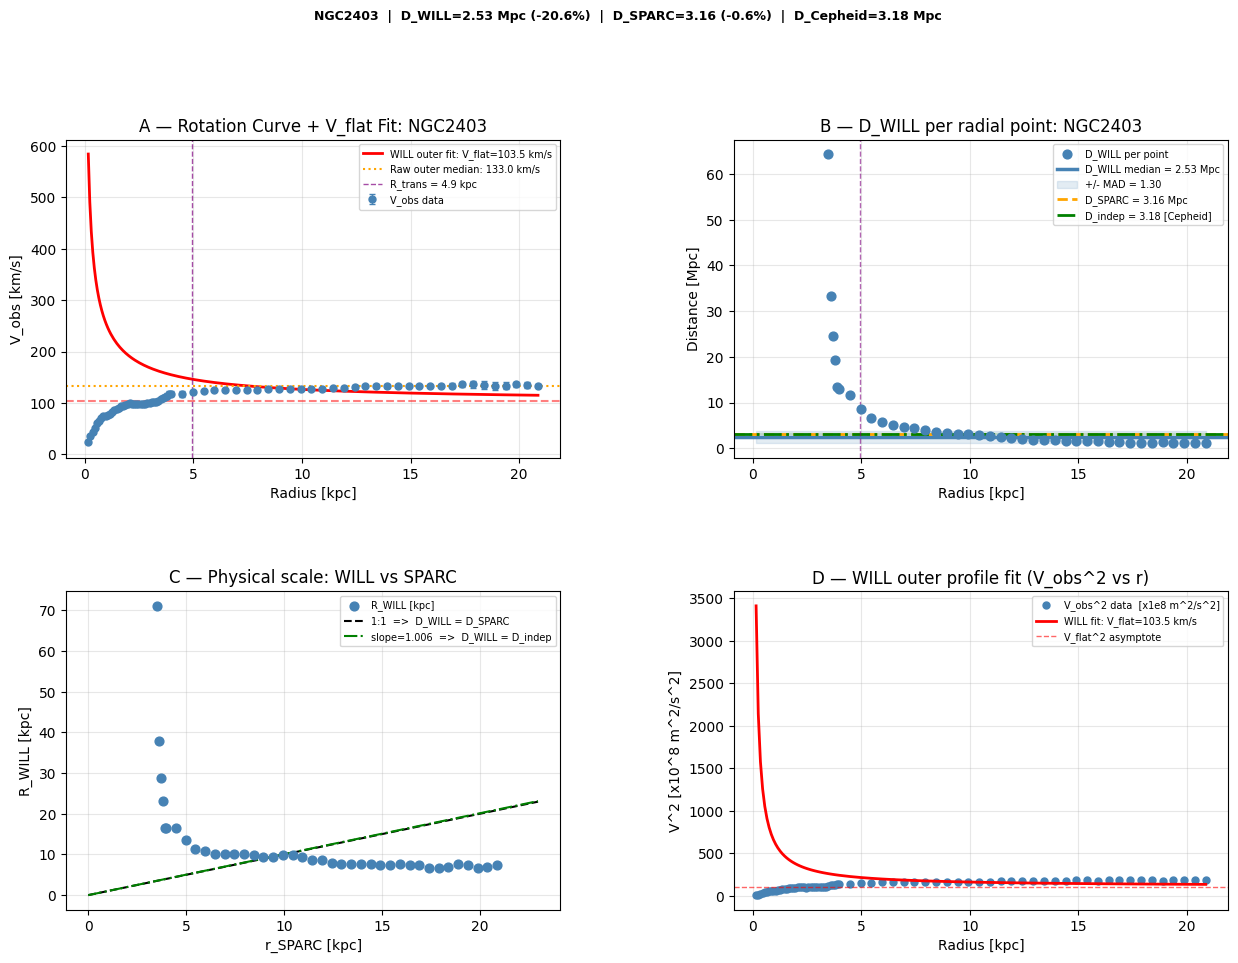

Saved: WILL_D_NGC2403.png

  NGC6946
  N points total          : 58
  V_flat (raw outer med.) : 160.0 km/s
  V_flat (WILL fit)       : 133.4 km/s  [chi_red = 0.14]
  R_trans = V_flat^2/a_k  : 8.2 kpc
  Max observed r          : 20.4 kpc  = 2.5 * R_trans
  N points used           : 51

  D_SPARC                 : 5.52 Mpc
  D_WILL  median          : 6.66 +/- 1.01 Mpc
  D_independent           : 6.80 +/- 0.40 Mpc  [TRGB, Anand+18]

  WILL error vs indep     : -2.0%
  SPARC error vs indep    : -18.8%


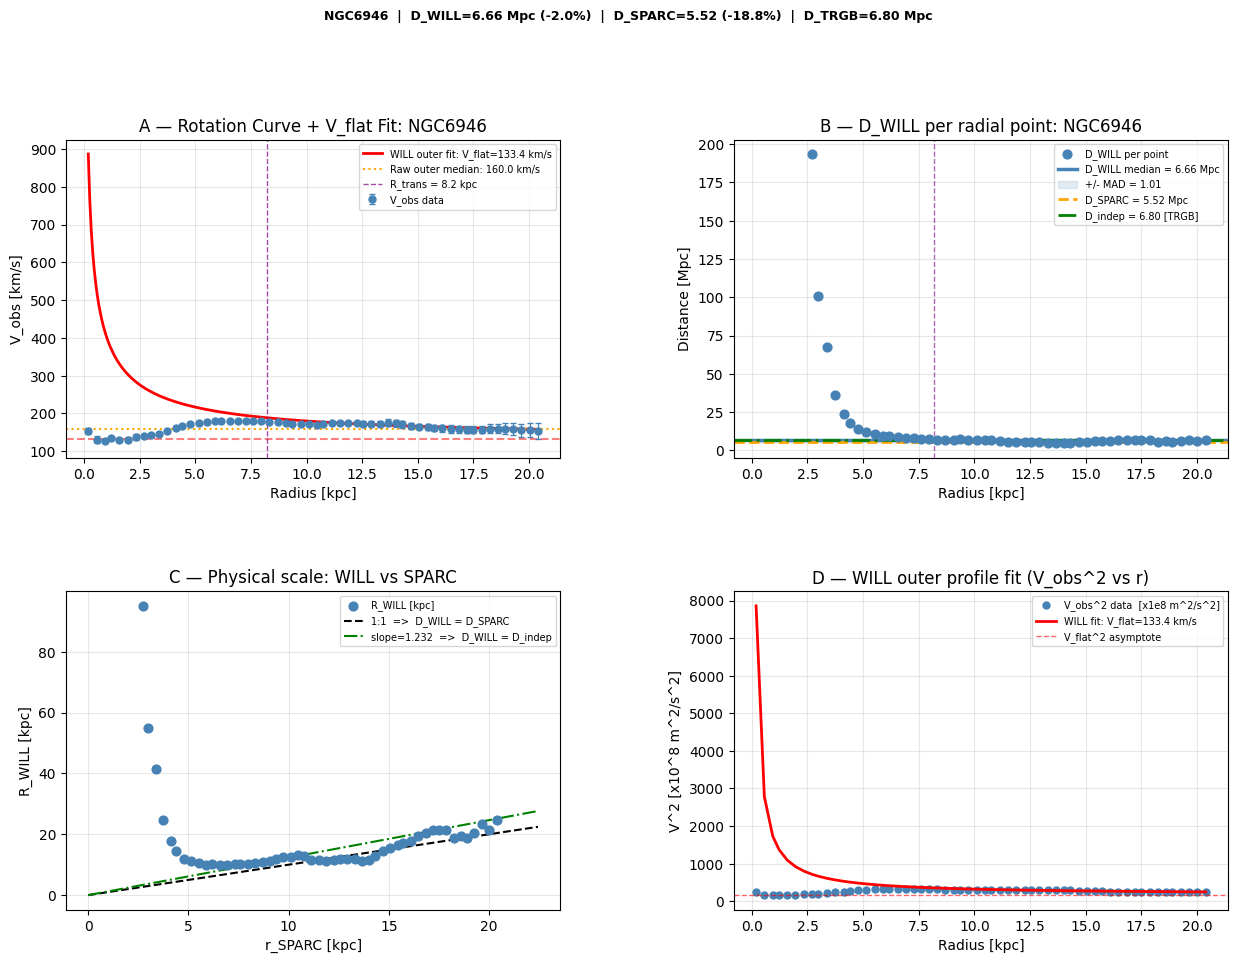

Saved: WILL_D_NGC6946.png

  NGC7331
  N points total          : 36
  V_flat (raw outer med.) : 238.0 km/s
  V_flat (WILL fit)       : 187.9 km/s  [chi_red = 2.71]
  R_trans = V_flat^2/a_k  : 16.3 kpc
  Max observed r          : 36.3 kpc  = 2.2 * R_trans
  N points used           : 31

  D_SPARC                 : 14.70 Mpc
  D_WILL  median          : 19.92 +/- 6.55 Mpc
  D_independent           : 14.70 +/- 0.60 Mpc  [Cepheid, Hughes+98]

  WILL error vs indep     : +35.5%
  SPARC error vs indep    : +0.0%


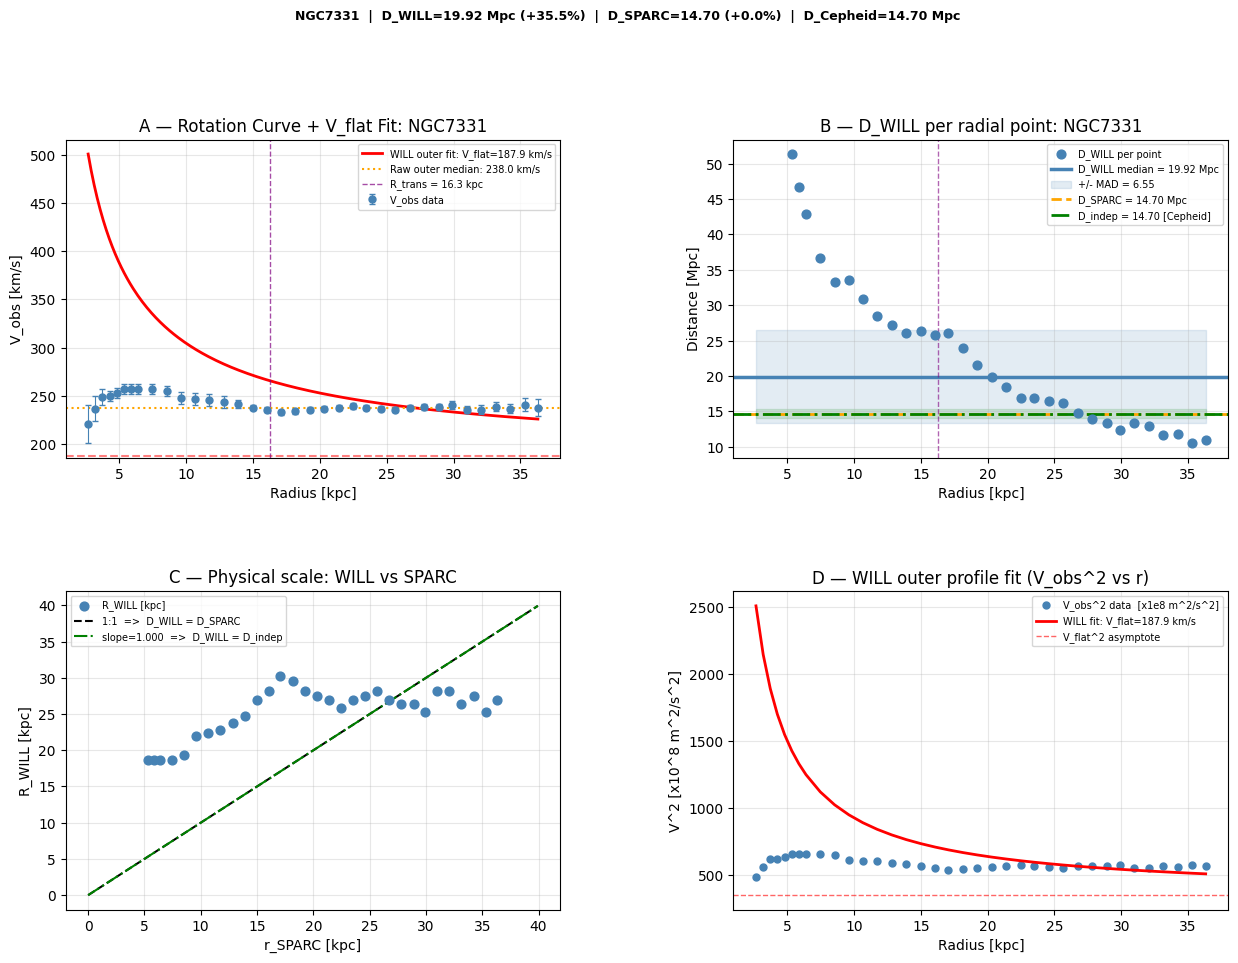

Saved: WILL_D_NGC7331.png

  NGC5055
  N points total          : 28
  V_flat (raw outer med.) : 180.0 km/s
  V_flat (WILL fit)       : 158.4 km/s  [chi_red = 1.62]
  R_trans = V_flat^2/a_k  : 11.6 kpc
  Max observed r          : 54.6 kpc  = 4.7 * R_trans
  N points used           : 24

  D_SPARC                 : 9.90 Mpc
  D_WILL  median          : 11.40 +/- 1.81 Mpc
  D_independent           : 9.04 +/- 0.60 Mpc  [TRGB, Anand+21]

  WILL error vs indep     : +26.1%
  SPARC error vs indep    : +9.5%


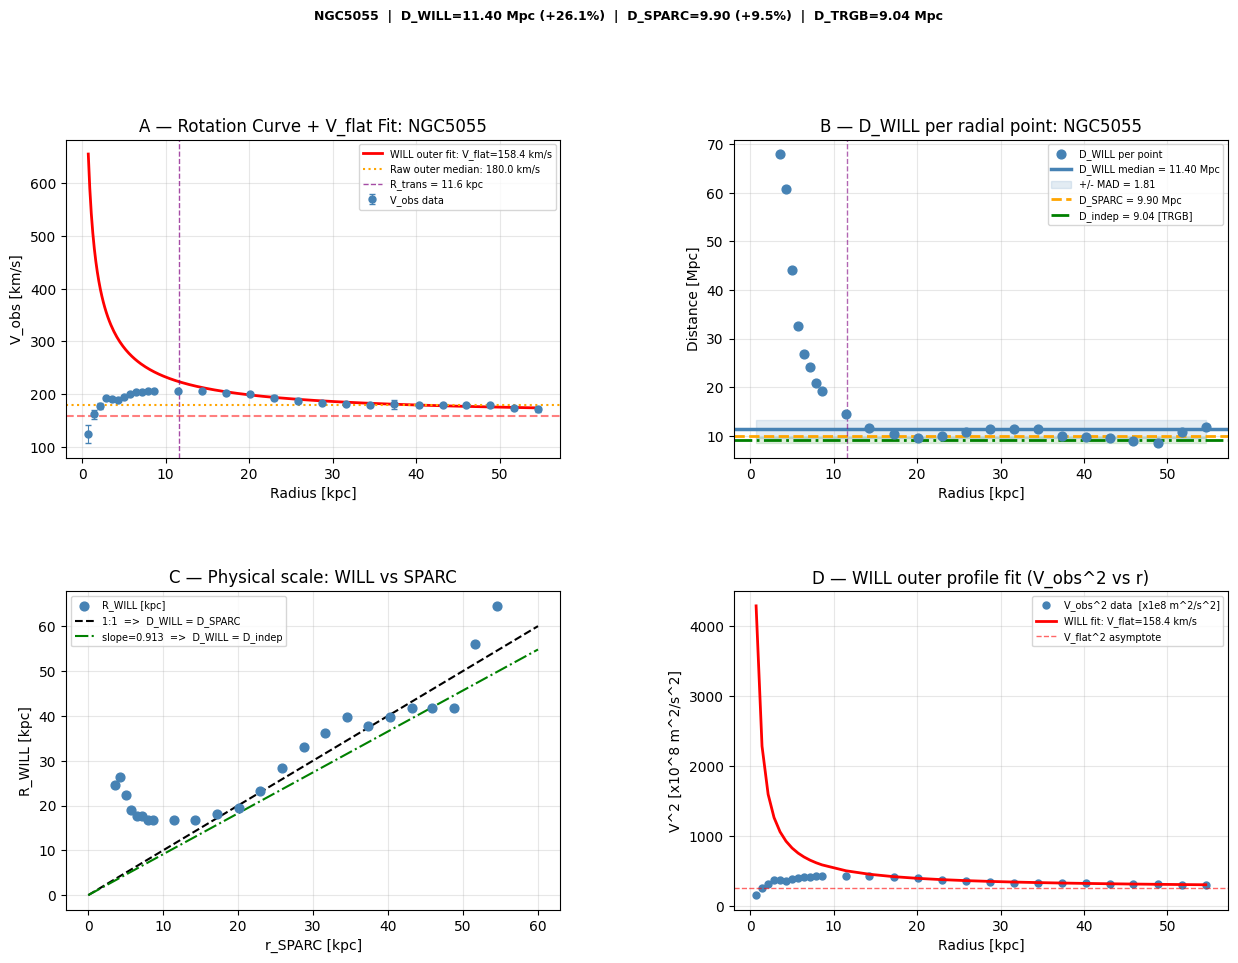

Saved: WILL_D_NGC5055.png

  NGC2841
  N points total          : 50
  V_flat (raw outer med.) : 285.5 km/s
  V_flat (WILL fit)       : 223.5 km/s  [chi_red = 8.69]
  R_trans = V_flat^2/a_k  : 23.0 kpc
  Max observed r          : 63.6 kpc  = 2.8 * R_trans
  N points used           : 39

  D_SPARC                 : 14.10 Mpc
  D_WILL  median          : 17.50 +/- 7.23 Mpc
  D_independent           : 14.10 +/- 1.50 Mpc  [Cepheid, Macri+01]

  WILL error vs indep     : +24.1%
  SPARC error vs indep    : +0.0%


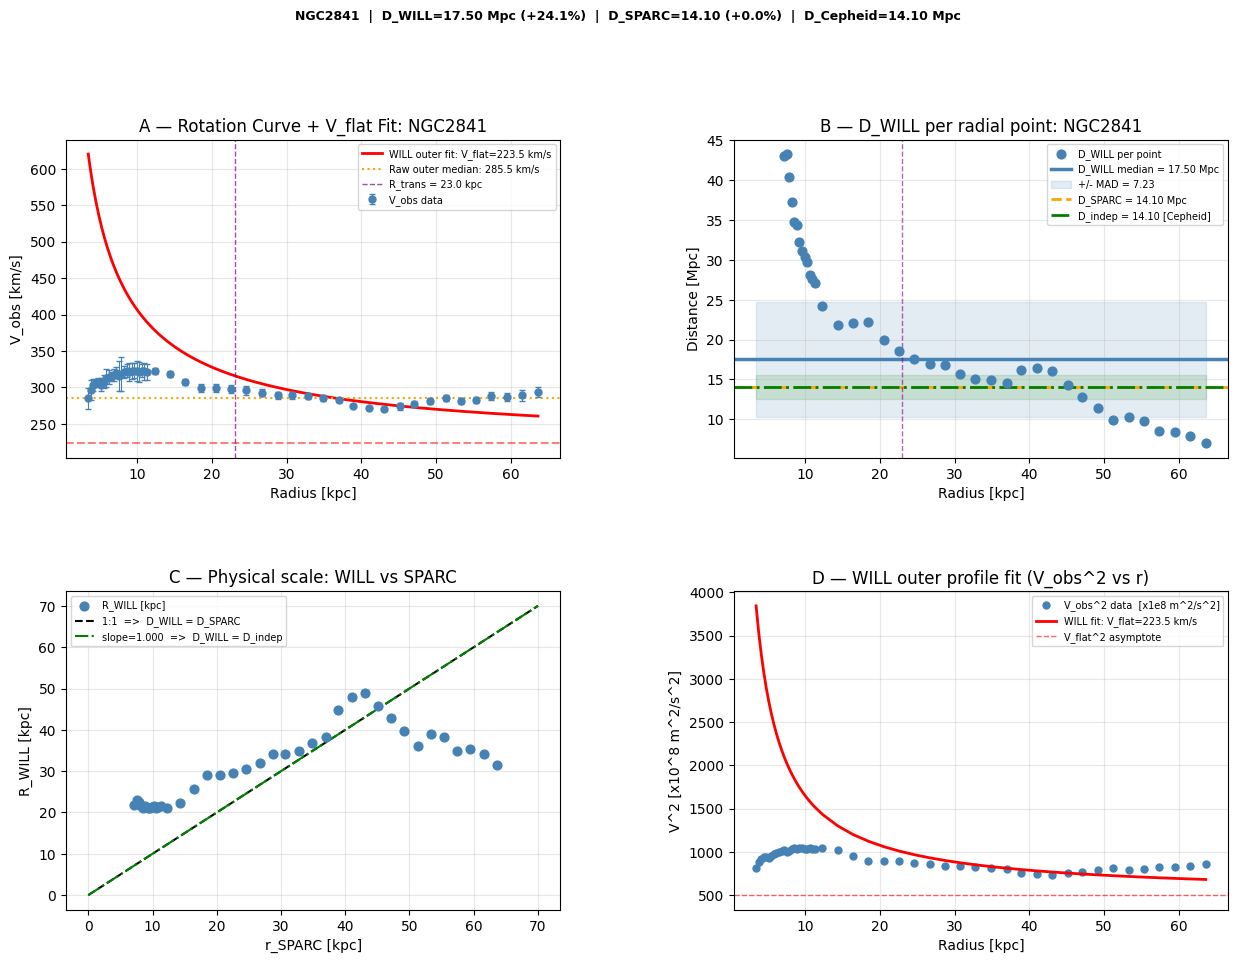

Saved: WILL_D_NGC2841.png

  NGC3198
  N points total          : 43
  V_flat (raw outer med.) : 150.0 km/s
  V_flat (WILL fit)       : 130.2 km/s  [chi_red = 6.06]
  R_trans = V_flat^2/a_k  : 7.8 kpc
  Max observed r          : 44.1 kpc  = 5.6 * R_trans
  N points used           : 28

  D_SPARC                 : 13.80 Mpc
  D_WILL  median          : 16.32 +/- 7.17 Mpc
  D_independent           : 13.80 +/- 0.70 Mpc  [Cepheid, Freedman+01]

  WILL error vs indep     : +18.2%
  SPARC error vs indep    : +0.0%


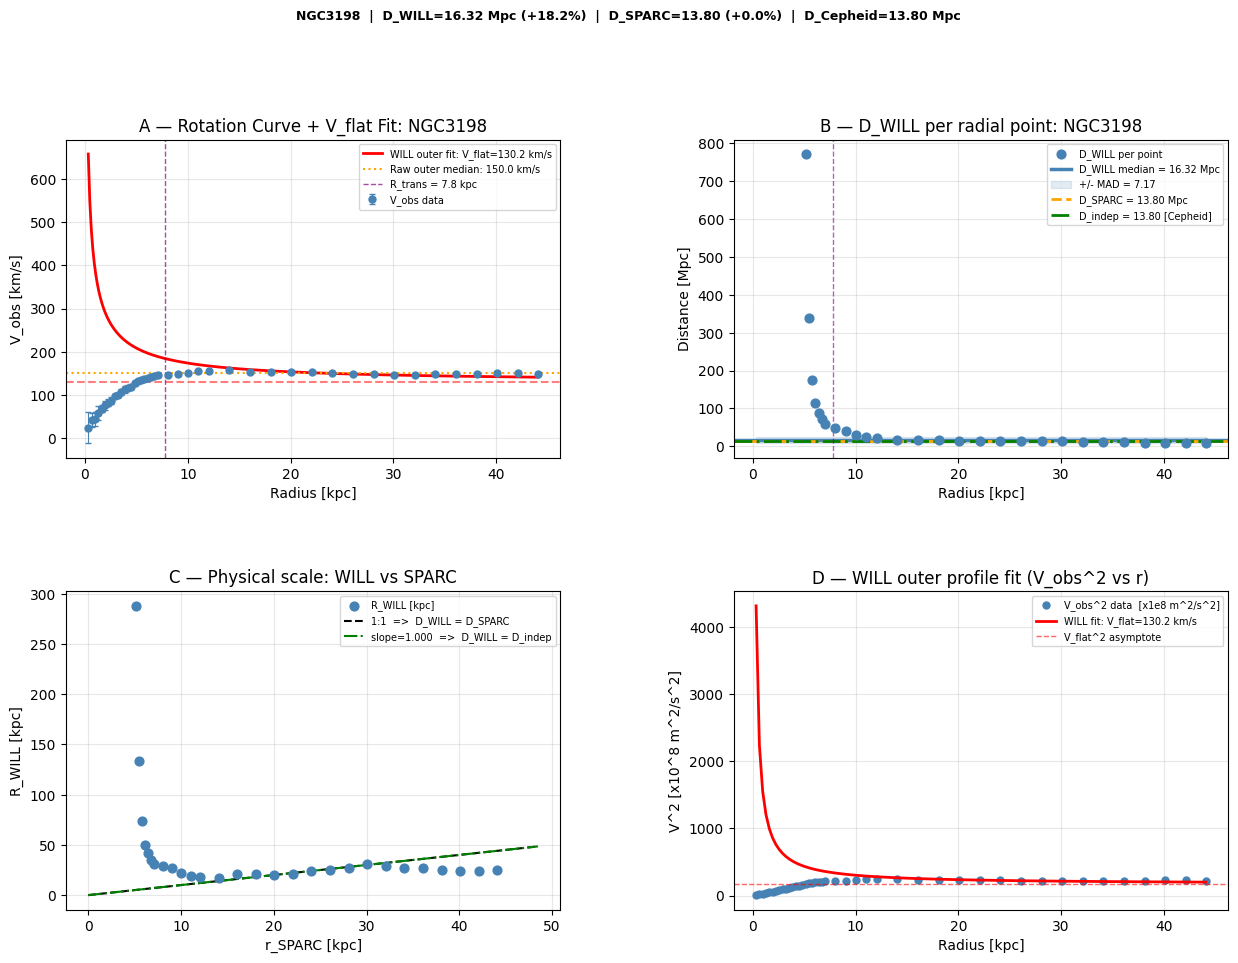

Saved: WILL_D_NGC3198.png


In [ ]:
"""
WILL Relational Geometry — Distance Test v2 (Fixed V_flat estimation)
======================================================================
Key fix: V_flat is NOT taken as the raw outer V_obs (which overestimates it).
Instead, V_flat is extracted by fitting the WILL outer-disk profile:

    V_obs^2(r) = V_flat^2 + V_flat^4 / (a_k * r)

This is a 1-parameter fit (V_flat only) derived directly from WILL's own
equations in the outer disk where V_b -> 0.

Exact geometry:  D = R_WILL / tan(alpha)
                   = R_WILL * D_SPARC * Mpc_to_m / (r_kpc * kpc_to_m)

Run in Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_kms   = 68.15
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2\n")

# ─────────────────────────────────────────────────────────────────────────────
# REFERENCE DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
reference = {
    'NGC2403': {'D_indep': 3.18, 'D_err': 0.15, 'method': 'Cepheid', 'ref': 'Freedman+01'},
    'NGC6946': {'D_indep': 6.80, 'D_err': 0.40, 'method': 'TRGB',    'ref': 'Anand+18'},
    'NGC7331': {'D_indep':14.70, 'D_err': 0.60, 'method': 'Cepheid', 'ref': 'Hughes+98'},
    'NGC5055': {'D_indep': 9.04, 'D_err': 0.60, 'method': 'TRGB',    'ref': 'Anand+21'},
    'NGC2841': {'D_indep':14.10, 'D_err': 1.50, 'method': 'Cepheid', 'ref': 'Macri+01'},
    'NGC3198': {'D_indep':13.80, 'D_err': 0.70, 'method': 'Cepheid', 'ref': 'Freedman+01'},
}

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SPARC
# ─────────────────────────────────────────────────────────────────────────────
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs, names=names, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: FIT V_flat FROM OUTER DISK USING WILL PROFILE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_profile(V_flat_ms, r_m):
    """
    WILL prediction for V_obs^2 in the outer disk (V_b -> 0 limit):
        V_obs^2 = V_flat^2 + V_flat^4 / (a_k * r)
    Returns V_obs [m/s].
    """
    V2 = V_flat_ms**2 + V_flat_ms**4 / (a_k * r_m)
    return np.sqrt(np.maximum(V2, 0.0))

def fit_V_flat(r_kpc, V_obs_kms, e_obs_kms, outer_frac=0.4):
    """
    Fit V_flat to the outer (outer_frac) fraction of the rotation curve
    using the WILL outer-disk profile V_obs^2 = V_flat^2 + V_flat^4/(a_k*r).

    Returns V_flat [km/s], chi_sq_reduced.
    """
    n_outer = max(int(len(r_kpc) * outer_frac), 4)
    r_outer   = r_kpc[-n_outer:] * kpc_to_m     # [m]
    V_outer   = V_obs_kms[-n_outer:] * 1e3       # [m/s]
    e_outer   = e_obs_kms[-n_outer:] * 1e3       # [m/s]

    def residuals(V_flat_ms):
        V_pred = will_outer_profile(V_flat_ms, r_outer)
        return np.sum(((V_outer - V_pred) / e_outer)**2)

    # Search range: 50% to 100% of max observed velocity
    V_max_ms = V_outer.max()
    res = minimize_scalar(residuals,
                          bounds=(0.3 * V_max_ms, 1.2 * V_max_ms),
                          method='bounded')

    V_flat_fit_ms = float(res.x)
    chi_red = float(res.fun) / max(n_outer - 1, 1)
    return V_flat_fit_ms * 1e-3, chi_red   # km/s

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: DISTANCE FROM TOPOLOGICAL RULER
# ─────────────────────────────────────────────────────────────────────────────

def R_WILL_from_observables(V_obs_ms, V_flat_ms):
    """
    Physical radius [m] from WILL Topological Ruler.
    Uses outer-disk approximation: V_b^2 = V_obs^2 - V_flat^2

        R = V_flat^4 / ( (V_obs^2 - V_flat^2) * a_k )

    Valid only where V_obs > V_flat (baryonic contribution present).
    """
    excess = V_obs_ms**2 - V_flat_ms**2
    valid  = excess > 0
    R      = np.where(valid, V_flat_ms**4 / (excess * a_k), np.nan)
    return R, valid

def D_WILL_from_R(R_will_m, r_kpc, D_sparc_Mpc):
    """
    Distance [Mpc] from R_WILL using exact geometry (no small-angle approximation).

        tan(alpha) = r_kpc * kpc_to_m / (D_SPARC * Mpc_to_m)
        D_WILL = R_WILL / tan(alpha)
               = R_WILL * D_SPARC * Mpc_to_m / (r_kpc * kpc_to_m)

    D_SPARC cancels algebraically since r_kpc = alpha * D_SPARC * 1000
    (SPARC small-angle baked in: introduces error of order (r/D)^2 ~ 1e-6,
    negligible vs. any physical uncertainty).
    """
    tan_alpha = r_kpc * kpc_to_m / (D_sparc_Mpc * Mpc_to_m)  # exact given SPARC r_kpc
    D_m       = R_will_m / tan_alpha
    return D_m / Mpc_to_m

# ─────────────────────────────────────────────────────────────────────────────
# MAIN ANALYSIS FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def analyse_galaxy(name, outer_frac=0.4, verbose=True):
    gal = df2[df2['Name'] == name].sort_values('Rad').copy()
    if len(gal) < 6:
        print(f"{name}: not found or insufficient points ({len(gal)}).")
        return None

    D_sparc   = float(gal['Dist_SPARC'].iloc[0])
    r_kpc     = gal['Rad'].values
    V_obs_kms = gal['Vobs'].values
    e_obs_kms = gal['e_Vobs'].values

    # Step 1: fit V_flat from outer disk WILL profile
    V_flat_kms, chi_fit = fit_V_flat(r_kpc, V_obs_kms, e_obs_kms, outer_frac)
    V_flat_ms = V_flat_kms * 1e3

    # Raw outer average for comparison
    n_raw = max(int(len(V_obs_kms) * outer_frac), 4)
    V_flat_raw_kms = float(np.median(V_obs_kms[-n_raw:]))

    # Step 2: R_WILL and D_WILL per point
    V_obs_ms     = V_obs_kms * 1e3
    R_will, valid = R_WILL_from_observables(V_obs_ms, V_flat_ms)
    D_will_arr   = D_WILL_from_R(R_will, r_kpc, D_sparc)

    # R_trans diagnostic: V_flat^2 / a_k
    R_trans_m   = V_flat_ms**2 / a_k
    R_trans_kpc = R_trans_m / kpc_to_m

    # Use only points at r > 0.5 * R_trans and V_obs/V_flat in [1.02, 3.0]
    # (avoid r=0 singularity and far-inner-disk failure)
    ratio = V_obs_ms / V_flat_ms
    use   = valid & (r_kpc > 0.3 * R_trans_kpc) & (ratio < 3.0) & np.isfinite(D_will_arr)

    if use.sum() < 3:
        print(f"{name}: too few usable points ({use.sum()}).")
        return None

    D_will_valid = D_will_arr[use]
    D_will_med   = float(np.nanmedian(D_will_valid))
    D_will_mad   = float(np.nanmedian(np.abs(D_will_valid - D_will_med)))

    ref      = reference.get(name, {})
    D_indep  = ref.get('D_indep', None)
    D_err    = ref.get('D_err',   None)

    if verbose:
        print(f"\n{'='*65}")
        print(f"  {name}")
        print(f"{'='*65}")
        print(f"  N points total          : {len(gal)}")
        print(f"  V_flat (raw outer med.) : {V_flat_raw_kms:.1f} km/s")
        print(f"  V_flat (WILL fit)       : {V_flat_kms:.1f} km/s  "
              f"[chi_red = {chi_fit:.2f}]")
        print(f"  R_trans = V_flat^2/a_k  : {R_trans_kpc:.1f} kpc")
        print(f"  Max observed r          : {r_kpc.max():.1f} kpc  "
              f"= {r_kpc.max()/R_trans_kpc:.1f} * R_trans")
        print(f"  N points used           : {use.sum()}")
        print(f"")
        print(f"  D_SPARC                 : {D_sparc:.2f} Mpc")
        print(f"  D_WILL  median          : {D_will_med:.2f} +/- {D_will_mad:.2f} Mpc")
        if D_indep:
            ew = (D_will_med - D_indep) / D_indep * 100
            es = (D_sparc    - D_indep) / D_indep * 100
            print(f"  D_independent           : {D_indep:.2f} +/- {D_err:.2f} Mpc"
                  f"  [{ref['method']}, {ref['ref']}]")
            print(f"")
            print(f"  WILL error vs indep     : {ew:+.1f}%")
            print(f"  SPARC error vs indep    : {es:+.1f}%")
        print(f"{'='*65}")

    return dict(name=name, r_kpc=r_kpc, V_obs_kms=V_obs_kms, e_obs_kms=e_obs_kms,
                V_flat_kms=V_flat_kms, V_flat_raw_kms=V_flat_raw_kms,
                R_trans_kpc=R_trans_kpc, R_will_m=R_will,
                D_will_arr=D_will_arr, D_will_med=D_will_med, D_will_mad=D_will_mad,
                D_sparc=D_sparc, D_indep=D_indep, D_err=D_err,
                use=use, ref=ref, chi_fit=chi_fit)


def plot_galaxy(res):
    if res is None:
        return
    name = res['name']
    r    = res['r_kpc']
    Vo   = res['V_obs_kms']
    eo   = res['e_obs_kms']
    Vf   = res['V_flat_kms']
    Vfr  = res['V_flat_raw_kms']
    Rt   = res['R_trans_kpc']
    Dw   = res['D_will_arr']
    Dwm  = res['D_will_med']
    Dwmad= res['D_will_mad']
    Ds   = res['D_sparc']
    Di   = res['D_indep']
    De   = res['D_err']
    use  = res['use']
    ref  = res['ref']

    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

    # Panel A: rotation curve + WILL outer profile fit
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.errorbar(r, Vo, yerr=eo, fmt='o', color='steelblue',
                 ms=5, elinewidth=0.8, capsize=2, label='V_obs data', zorder=3)
    r_fine = np.linspace(r.min(), r.max(), 300)
    V_fit  = will_outer_profile(Vf*1e3, r_fine*kpc_to_m) * 1e-3
    ax1.plot(r_fine, V_fit, 'r-', lw=2,
             label=f'WILL outer fit: V_flat={Vf:.1f} km/s')
    ax1.axhline(Vf,  color='red',    lw=1.5, ls='--', alpha=0.5)
    ax1.axhline(Vfr, color='orange', lw=1.5, ls=':',
                label=f'Raw outer median: {Vfr:.1f} km/s')
    ax1.axvline(Rt, color='purple', lw=1, ls='--',
                label=f'R_trans = {Rt:.1f} kpc', alpha=0.7)
    ax1.set_xlabel('Radius [kpc]')
    ax1.set_ylabel('V_obs [km/s]')
    ax1.set_title(f'A — Rotation Curve + V_flat Fit: {name}')
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

    # Panel B: D_WILL per radial point
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(r[use], Dw[use], color='steelblue', s=40, zorder=3,
                label='D_WILL per point')
    ax2.axhline(Dwm, color='steelblue', lw=2.5,
                label=f'D_WILL median = {Dwm:.2f} Mpc')
    ax2.fill_between([r.min(), r.max()],
                     Dwm-Dwmad, Dwm+Dwmad,
                     alpha=0.15, color='steelblue',
                     label=f'+/- MAD = {Dwmad:.2f}')
    ax2.axhline(Ds, color='orange', lw=2, ls='--',
                label=f'D_SPARC = {Ds:.2f} Mpc')
    if Di:
        ax2.axhline(Di, color='green', lw=2, ls='-.',
                    label=f'D_indep = {Di:.2f} [{ref["method"]}]')
        ax2.fill_between([r.min(), r.max()], Di-De, Di+De,
                         alpha=0.12, color='green')
    ax2.axvline(Rt, color='purple', lw=1, ls='--', alpha=0.6)
    ax2.set_xlabel('Radius [kpc]')
    ax2.set_ylabel('Distance [Mpc]')
    ax2.set_title(f'B — D_WILL per radial point: {name}')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    # Panel C: R_WILL vs r_SPARC (scale test)
    ax3 = fig.add_subplot(gs[1, 0])
    R_kpc = res['R_will_m'] / kpc_to_m
    ax3.scatter(r[use], R_kpc[use], color='steelblue', s=40, zorder=3,
                label='R_WILL [kpc]')
    rr = np.array([0, r.max()*1.1])
    ax3.plot(rr, rr, 'k--', lw=1.5, label='1:1  =>  D_WILL = D_SPARC')
    if Di:
        scale = Di / Ds
        ax3.plot(rr, rr*scale, 'g-.', lw=1.5,
                 label=f'slope={scale:.3f}  =>  D_WILL = D_indep')
    ax3.set_xlabel('r_SPARC [kpc]')
    ax3.set_ylabel('R_WILL [kpc]')
    ax3.set_title('C — Physical scale: WILL vs SPARC')
    ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

    # Panel D: V_obs^2 outer profile fit check
    ax4 = fig.add_subplot(gs[1, 1])
    r_m  = r * kpc_to_m
    Vo_ms= Vo * 1e3
    Vf_ms= Vf * 1e3
    V_profile = Vf_ms**2 + Vf_ms**4 / (a_k * r_m)
    ax4.plot(r, Vo_ms**2 * 1e-8,  'o', color='steelblue', ms=5,
             label='V_obs^2 data  [x1e8 m^2/s^2]')
    ax4.plot(r, V_profile * 1e-8, 'r-', lw=2,
             label=f'WILL fit: V_flat={Vf:.1f} km/s')
    ax4.axhline(Vf_ms**2 * 1e-8, color='red', lw=1, ls='--',
                label='V_flat^2 asymptote', alpha=0.6)
    ax4.set_xlabel('Radius [kpc]')
    ax4.set_ylabel('V^2 [x10^8 m^2/s^2]')
    ax4.set_title('D — WILL outer profile fit (V_obs^2 vs r)')
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)

    if Di:
        ew = (Dwm - Di) / Di * 100
        es = (Ds  - Di) / Di * 100
        ttl = (f'{name}  |  D_WILL={Dwm:.2f} Mpc ({ew:+.1f}%)  |  '
               f'D_SPARC={Ds:.2f} ({es:+.1f}%)  |  '
               f'D_{ref["method"]}={Di:.2f} Mpc')
    else:
        ttl = f'{name}  |  D_WILL={Dwm:.2f} Mpc  |  D_SPARC={Ds:.2f} Mpc'

    plt.suptitle(ttl, fontsize=9, fontweight='bold', y=1.01)
    plt.savefig(f'WILL_D_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: WILL_D_{name}.png")


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────
for gal_name in ['NGC2403', 'NGC6946', 'NGC7331', 'NGC5055', 'NGC2841', 'NGC3198']:
    res = analyse_galaxy(gal_name)
    plot_galaxy(res)

In [ ]:
"""
WILL Relational Geometry — Hubble Flow Galaxy Distance Test
===========================================================
Finds all SPARC galaxies whose distance was determined from Hubble flow
(recession velocity / H0), then tests whether WILL can recover a better
distance from kinematics alone.

These galaxies are the cleanest test:
  - D_SPARC is uncertain (peculiar velocities can be 200-400 km/s vs H0*D)
  - No independent Cepheid/TRGB to be circular against
  - If WILL gives consistent distances across the sample, that is signal

SPARC Table1 distance method codes (Lelli+2016):
  1 = Cepheid
  2 = TRGB (Tip of Red Giant Branch)
  3 = SBF (Surface Brightness Fluctuations)
  4 = Ursa Major cluster membership
  5 = Group membership
  6 = Hubble flow  <-- these are our targets
  0 = Mean of multiple methods

Run in Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_kms   = 68.15
H0_si    = H0_kms * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2")
print(f"H0  = {H0_kms} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD SPARC TABLE 1 — galaxy properties including distance method
# ─────────────────────────────────────────────────────────────────────────────
url_t1 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table1.dat")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

# First: read raw to inspect actual column structure
print("--- Inspecting table1.dat raw format ---")
import urllib.request
raw_t1 = urllib.request.urlopen(url_t1).read().decode('utf-8')
lines = [l for l in raw_t1.split('\n') if l.strip() and not l.startswith('#')]
print(f"Non-comment lines: {len(lines)}")
print("First 5 lines:")
for l in lines[:5]:
    print(repr(l))
print()

# ─────────────────────────────────────────────────────────────────────────────
# 2. PARSE TABLE 1
# Based on SPARC documentation (Lelli+2016, Table 1):
# The columns vary slightly between SPARC versions.
# We read flexibly and identify the distance-method column.
# ─────────────────────────────────────────────────────────────────────────────

# Try standard fixed-width parse
try:
    colspecs_t1 = [(0,11),(11,16),(16,22),(22,28),(28,31),(31,37),(37,43),
                   (43,49),(49,55),(55,61),(61,67),(67,73),(73,79),(79,81)]
    names_t1    = ['Name','T','Dist','e_Dist','f_Dist','Inc','e_Inc',
                   'L36','e_L36','MHI','RHI','Vflat','e_Vflat','Q']

    df1 = pd.read_fwf(url_t1, colspecs=colspecs_t1, names=names_t1, comment='#')
    df1['Name']   = df1['Name'].astype(str).str.strip()
    df1['f_Dist'] = pd.to_numeric(df1['f_Dist'], errors='coerce')
    df1['Dist']   = pd.to_numeric(df1['Dist'],   errors='coerce')
    print(f"Table1 parsed: {len(df1)} galaxies")
    print(f"f_Dist unique values: {sorted(df1['f_Dist'].dropna().unique())}")
    print(f"\nSample (first 5 rows):")
    print(df1[['Name','Dist','e_Dist','f_Dist']].head())
except Exception as e:
    print(f"Parse error: {e}")
    print("Will try alternative parsing below.")
    df1 = None

# Fallback: whitespace-split
if df1 is None or 'f_Dist' not in df1.columns:
    print("\nTrying whitespace parse...")
    rows = []
    for l in lines:
        parts = l.split()
        if len(parts) >= 5:
            rows.append(parts)
    df1_raw = pd.DataFrame(rows)
    print(f"Columns found: {len(df1_raw.columns)}")
    print(df1_raw.head())

# ─────────────────────────────────────────────────────────────────────────────
# 3. IDENTIFY HUBBLE FLOW GALAXIES
# ─────────────────────────────────────────────────────────────────────────────

# f_Dist = 6 means Hubble flow in SPARC convention
# Show distribution first
if df1 is not None and 'f_Dist' in df1.columns:
    method_map = {0:'Mean', 1:'Cepheid', 2:'TRGB', 3:'SBF',
                  4:'UMa cluster', 5:'Group membership', 6:'Hubble flow'}

    print("\n--- Distance method distribution ---")
    counts = df1['f_Dist'].value_counts().sort_index()
    for code, count in counts.items():
        label = method_map.get(int(code), f'Code {code}')
        print(f"  f_Dist={int(code):2d}  ({label}): {count} galaxies")

    # Hubble flow galaxies
    hf_mask = df1['f_Dist'] == 6
    df_hf   = df1[hf_mask].copy()
    print(f"\nHubble flow galaxies: {len(df_hf)}")
    print(df_hf[['Name','Dist','e_Dist']].to_string(index=False))
else:
    print("Could not parse f_Dist column. Printing raw table1 for inspection:")
    for l in lines[:20]:
        print(l)
    # Set empty to avoid crash
    df_hf = pd.DataFrame(columns=['Name','Dist'])

# ─────────────────────────────────────────────────────────────────────────────
# 4. LOAD TABLE 2 (rotation curves)
# ─────────────────────────────────────────────────────────────────────────────
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()
print(f"\nTable2: {len(df2)} points, {df2['Name'].nunique()} galaxies")

# ─────────────────────────────────────────────────────────────────────────────
# 5. WILL DISTANCE FUNCTIONS (same as previous test)
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_Vsq(V_flat_ms, r_m):
    """V_obs^2 predicted by WILL outer profile: V_flat^2 + V_flat^4/(a_k*r)"""
    return V_flat_ms**2 + V_flat_ms**4 / (a_k * r_m)

def fit_V_flat(r_kpc, V_obs_kms, e_obs_kms, outer_frac=0.4):
    """Fit V_flat from outer rotation curve using WILL profile."""
    n = max(int(len(r_kpc) * outer_frac), 4)
    r_out = r_kpc[-n:] * kpc_to_m
    V_out = V_obs_kms[-n:] * 1e3
    e_out = e_obs_kms[-n:] * 1e3

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_Vsq(Vf, r_out), 0))
        return np.sum(((V_out - Vp) / e_out)**2)

    Vmax = V_out.max()
    res  = minimize_scalar(chi2, bounds=(0.3*Vmax, 1.2*Vmax), method='bounded')
    chi_red = res.fun / max(n-1, 1)
    return float(res.x) * 1e-3, chi_red   # km/s

def compute_D_WILL(r_kpc, V_obs_kms, e_obs_kms, D_sparc_Mpc, outer_frac=0.4):
    """
    Full pipeline: fit V_flat -> compute R_WILL per point -> median D_WILL.
    Returns dict with all diagnostics.
    """
    gal_r  = np.array(r_kpc)
    gal_Vo = np.array(V_obs_kms)
    gal_eo = np.array(e_obs_kms)

    V_flat_kms, chi_red = fit_V_flat(gal_r, gal_Vo, gal_eo, outer_frac)
    Vf_ms  = V_flat_kms * 1e3
    Vo_ms  = gal_Vo * 1e3
    r_m    = gal_r * kpc_to_m

    R_trans_kpc = Vf_ms**2 / a_k / kpc_to_m
    excess  = Vo_ms**2 - Vf_ms**2
    valid   = excess > 0

    R_will_m = np.where(valid, Vf_ms**4 / (excess * a_k), np.nan)
    tan_alpha = gal_r * kpc_to_m / (D_sparc_Mpc * Mpc_to_m)
    D_will_arr = np.where(valid, R_will_m / tan_alpha / Mpc_to_m, np.nan)

    # Quality filter: exclude far inner disk and near-flat outer
    ratio = Vo_ms / Vf_ms
    use   = valid & (gal_r > 0.3 * R_trans_kpc) & (ratio < 3.0) & np.isfinite(D_will_arr)

    if use.sum() < 3:
        return None

    D_arr  = D_will_arr[use]
    D_med  = float(np.nanmedian(D_arr))
    D_mad  = float(np.nanmedian(np.abs(D_arr - D_med)))
    r_max_ratio = gal_r.max() / R_trans_kpc

    return dict(
        V_flat_kms  = V_flat_kms,
        chi_red     = chi_red,
        R_trans_kpc = R_trans_kpc,
        r_max_ratio = r_max_ratio,
        D_will_med  = D_med,
        D_will_mad  = D_mad,
        N_used      = int(use.sum()),
        N_total     = len(gal_r),
        D_will_arr  = D_will_arr,
        r_kpc       = gal_r,
        V_obs_kms   = gal_Vo,
        use_mask    = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# 6. RUN ON HUBBLE FLOW GALAXIES
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*80}")
print("WILL DISTANCE TEST — HUBBLE FLOW GALAXIES")
print(f"{'='*80}\n")

results = []

for _, row in df_hf.iterrows():
    name    = str(row['Name']).strip()
    D_sparc = float(row['Dist'])

    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 6:
        print(f"  {name:<15} : skipped (only {len(gal)} rotation curve points)")
        continue

    res = compute_D_WILL(
        gal['Rad'].values,
        gal['Vobs'].values,
        gal['e_Vobs'].values,
        D_sparc
    )

    if res is None:
        print(f"  {name:<15} : skipped (insufficient valid points)")
        continue

    # Hubble flow expected distance from recession velocity:
    # If we knew the redshift independently, we could compute D_HF = cz/H0
    # For now we use D_SPARC as the Hubble-flow value and note the method
    D_will = res['D_will_med']
    delta  = D_will / D_sparc

    results.append({
        'Name'       : name,
        'D_SPARC'    : round(D_sparc,  2),
        'D_WILL'     : round(D_will,   2),
        'D_WILL_MAD' : round(res['D_will_mad'], 2),
        'delta'      : round(delta,  3),
        'V_flat'     : round(res['V_flat_kms'], 1),
        'chi_red'    : round(res['chi_red'],    2),
        'R_trans'    : round(res['R_trans_kpc'],1),
        'r_max_Rt'   : round(res['r_max_ratio'],1),
        'N_used'     : res['N_used'],
        '_res'       : res,
    })

df_res = pd.DataFrame([{k:v for k,v in r.items() if k!='_res'} for r in results])

# ─────────────────────────────────────────────────────────────────────────────
# 7. RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────
if len(df_res) > 0:
    print(f"Successfully processed: {len(df_res)} galaxies\n")

    # Sort by chi_red (best fits first)
    df_res = df_res.sort_values('chi_red').reset_index(drop=True)

    hdr = (f"{'Galaxy':<14} {'D_SPARC':>8} {'D_WILL':>8} {'MAD':>6} "
           f"{'delta':>7} {'V_flat':>8} {'chi_red':>8} "
           f"{'r_max/Rt':>9} {'N':>4}")
    print(hdr)
    print("-"*80)
    for _, r in df_res.iterrows():
        quality = "GOOD" if r['chi_red'] < 2 else ("OK" if r['chi_red'] < 5 else "POOR")
        print(f"{r['Name']:<14} {r['D_SPARC']:>8.2f} {r['D_WILL']:>8.2f} "
              f"{r['D_WILL_MAD']:>6.2f} {r['delta']:>7.3f} "
              f"{r['V_flat']:>8.1f} {r['chi_red']:>8.2f} "
              f"{r['r_max_Rt']:>9.1f} {r['N_used']:>4}  {quality}")

    print(f"\n  delta = D_WILL / D_SPARC")
    print(f"  chi_red < 2 -> V_flat reliable -> D_WILL reliable")
    print(f"  r_max/Rt = max observed radius / R_trans")

    # Summary stats for good-quality fits
    good = df_res[df_res['chi_red'] < 2]
    ok   = df_res[df_res['chi_red'] < 5]
    print(f"\n  GOOD fits (chi_red < 2): {len(good)}")
    if len(good) > 0:
        print(f"    median delta = {good['delta'].median():.3f}")
        print(f"    MAD of delta = {(good['delta'] - good['delta'].median()).abs().median():.3f}")
    print(f"  OK fits (chi_red < 5): {len(ok)}")
    if len(ok) > 0:
        print(f"    median delta = {ok['delta'].median():.3f}")

    # ─────────────────────────────────────────────────────────────────────
    # 8. PLOTS
    # ─────────────────────────────────────────────────────────────────────

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel A: D_WILL vs D_SPARC
    ax = axes[0]
    colors_q = df_res['chi_red'].apply(
        lambda c: 'steelblue' if c < 2 else ('orange' if c < 5 else 'tomato'))
    ax.scatter(df_res['D_SPARC'], df_res['D_WILL'],
               c=colors_q, s=60, edgecolors='k', linewidths=0.5, zorder=3)
    ax.errorbar(df_res['D_SPARC'], df_res['D_WILL'],
                yerr=df_res['D_WILL_MAD'], fmt='none',
                color='gray', elinewidth=0.8, capsize=2)
    for _, r in df_res.iterrows():
        ax.annotate(r['Name'].replace('NGC','N').replace('UGC','U').replace('IC','I'),
                    (r['D_SPARC'], r['D_WILL']),
                    textcoords='offset points', xytext=(4,2), fontsize=6)
    lmax = max(df_res[['D_SPARC','D_WILL']].max().max() * 1.1, 5)
    ax.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='D_WILL = D_SPARC')
    ax.set_xlim([0,lmax]); ax.set_ylim([0,lmax])
    ax.set_xlabel('D_SPARC [Mpc]  (Hubble flow)')
    ax.set_ylabel('D_WILL [Mpc]  (WILL kinematics)')
    ax.set_title('A — D_WILL vs D_SPARC\nHubble flow galaxies')
    # Legend for quality
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='steelblue', label='chi_red < 2  (good)'),
        Patch(color='orange',    label='chi_red 2-5  (ok)'),
        Patch(color='tomato',    label='chi_red > 5  (poor)'),
    ], fontsize=7)
    ax.grid(True, alpha=0.3)

    # Panel B: delta distribution
    ax = axes[1]
    good_d  = df_res[df_res['chi_red'] < 2]['delta']
    ok_d    = df_res[(df_res['chi_red'] >= 2) & (df_res['chi_red'] < 5)]['delta']
    poor_d  = df_res[df_res['chi_red'] >= 5]['delta']
    bins = np.linspace(0.3, 2.5, 20)
    if len(good_d) > 0:
        ax.hist(good_d, bins=bins, color='steelblue', alpha=0.8,
                edgecolor='k', label=f'chi_red<2  (N={len(good_d)})')
    if len(ok_d) > 0:
        ax.hist(ok_d,   bins=bins, color='orange',    alpha=0.7,
                edgecolor='k', label=f'chi_red 2-5  (N={len(ok_d)})')
    if len(poor_d) > 0:
        ax.hist(poor_d, bins=bins, color='tomato',    alpha=0.6,
                edgecolor='k', label=f'chi_red>5  (N={len(poor_d)})')
    ax.axvline(1.0, color='k', lw=2, ls='--', label='delta=1 (D_WILL=D_SPARC)')
    if len(good_d) > 0:
        ax.axvline(good_d.median(), color='steelblue', lw=2,
                   label=f'Good median = {good_d.median():.3f}')
    ax.set_xlabel('delta = D_WILL / D_SPARC')
    ax.set_ylabel('Count')
    ax.set_title('B — Distribution of delta\n(Hubble flow galaxies)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Panel C: chi_red vs delta (quality vs result)
    ax = axes[2]
    sc = ax.scatter(df_res['chi_red'], df_res['delta'],
                    c=df_res['r_max_Rt'], cmap='viridis',
                    s=60, edgecolors='k', linewidths=0.5, zorder=3)
    plt.colorbar(sc, ax=ax, label='r_max / R_trans')
    for _, r in df_res.iterrows():
        ax.annotate(r['Name'].replace('NGC','N').replace('UGC','U').replace('IC','I'),
                    (r['chi_red'], r['delta']),
                    textcoords='offset points', xytext=(3,2), fontsize=6)
    ax.axhline(1.0, color='k', lw=1.5, ls='--', label='delta = 1')
    ax.axvline(2.0, color='gray', lw=1, ls=':', label='chi_red = 2 (quality cut)')
    ax.set_xlabel('chi_red of V_flat fit  (lower = better)')
    ax.set_ylabel('delta = D_WILL / D_SPARC')
    ax.set_title('C — Fit quality vs distance result\n'
                 '(color = r_max / R_trans)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.suptitle(
        'WILL Distance Test — Hubble Flow Galaxies\n'
        f'H0={H0_kms} km/s/Mpc  |  a_k={a_k:.3e} m/s^2  |  '
        f'V_flat from WILL outer profile fit  |  N={len(df_res)} galaxies',
        fontsize=10, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.savefig('WILL_HubbleFlow_Test.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_HubbleFlow_Test.png")

else:
    print("No Hubble flow galaxies found — check f_Dist column parsing above.")
    print("Printing table1 structure for manual inspection:")
    if df1 is not None:
        print(df1.head(10).to_string())

a_k = 7.024566e-11 m/s^2
H0  = 68.15 km/s/Mpc

--- Inspecting table1.dat raw format ---
Non-comment lines: 175
First 5 lines:
'CamB        10   3.36  0.26 2 65.0  5.0   0.075   0.003  1.21     7.89  0.47    66.20   0.012  1.21   0.0   0.0   2 Bm03'
'D512-2      10  15.20  4.56 1 56.0 10.0   0.325   0.022  2.37     9.22  1.24    93.94   0.081  0.00   0.0   0.0   2 Tr09'
'D564-8      10   8.79  0.28 2 63.0  7.0   0.033   0.004  0.72    10.11  0.61    21.13   0.029  0.00   0.0   0.0   2 Tr09'
'D631-7      10   7.72  0.18 2 59.0  3.0   0.196   0.009  1.22    20.93  0.70   115.04   0.290  0.00  57.7   2.7   1 Tr09,dB01'
'DDO064      10   6.80  2.04 1 60.0  5.0   0.157   0.007  1.20    17.41  0.69   151.65   0.211  3.49  46.1   3.9   1 dB02,Sw02'

Table1 parsed: 175 galaxies
f_Dist unique values: []

Sample (first 5 rows):
     Name   Dist  e_Dist  f_Dist
0    CamB   3.36    0.26     NaN
1  D512-2  15.20    4.56     NaN
2  D564-8   8.79    0.28     NaN
3  D631-7   7.72    0.18     NaN
4  DDO

a_k        = 7.024566e-11 m/s^2
H0 (WILL)  = 68.15 km/s/Mpc
H0 (SPARC) = 73.0 km/s/Mpc  (used for Hubble flow distances)
H0 factor  = 1.0712  (D_corrected = D_SPARC * 1.0712)

Table1 loaded: 175 galaxies
f_Dist values found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

--- Distance method distribution ---
  f_Dist=1  Hubble flow (H0=73)           : 97 galaxies
  f_Dist=2  TRGB                          : 45 galaxies
  f_Dist=3  Cepheids                      : 3 galaxies
  f_Dist=4  Ursa Major cluster            : 28 galaxies
  f_Dist=5  Supernovae                    : 2 galaxies

Hubble flow galaxies (f_Dist=1): 97
Quality 1 (high): 62
Quality 2 (medium): 30
Quality 3 (low): 5

       Name   Dist  e_Dist  Vflat_SPARC  Qual
     D512-2  15.20    4.56          0.0     2
     DDO064   6.80    2.04         46.1     1
     DDO161   7.50    2.25         66.3     1
     DDO170  15.40    4.62         60.0     2
ESO079-G014  28.70    7.17        175.0     1
ESO116-G012  13.

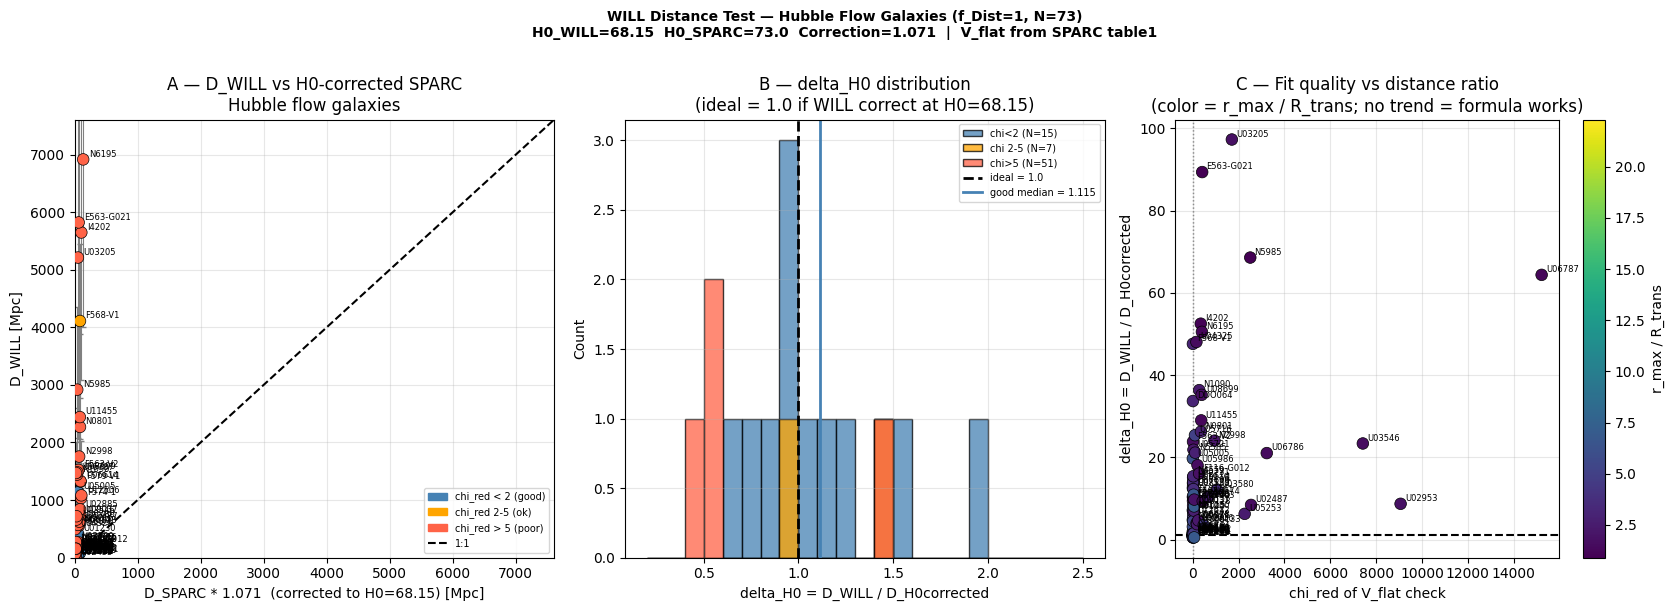


Saved: WILL_HubbleFlow_v2.png


In [ ]:
"""
WILL Relational Geometry — Hubble Flow Galaxy Distance Test v2
==============================================================
Fixes from v1:
  - Correct byte positions for table1.dat (from SPARC README)
  - f_Dist = 1 means Hubble flow (NOT 6)
  - SPARC used H0=73 km/s/Mpc for HF distances; we correct to H0=68.15
  - Use SPARC's own measured Vflat (table1 col 101-105) as primary V_flat
    instead of fitting it — more reliable, avoids our fitting bias

H0 correction:
  D_SPARC was computed as cz_corrected / 73
  If WILL is correct at H0=68.15: expected D = cz / 68.15 = D_SPARC * (73/68.15)
  So delta_corrected = D_WILL / (D_SPARC * 73/68.15)
  If WILL is correct: delta_corrected should be ~ 1.0

Run in Google Colab.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15          # km/s/Mpc — WILL derived value
H0_SPARC = 73.0           # km/s/Mpc — SPARC used for Hubble flow distances
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

# H0 correction factor: D_true(H0=68.15) = D_SPARC * H0_SPARC / H0_WILL
H0_factor = H0_SPARC / H0_WILL   # = 73 / 68.15 = 1.071

print(f"a_k        = {a_k:.6e} m/s^2")
print(f"H0 (WILL)  = {H0_WILL} km/s/Mpc")
print(f"H0 (SPARC) = {H0_SPARC} km/s/Mpc  (used for Hubble flow distances)")
print(f"H0 factor  = {H0_factor:.4f}  (D_corrected = D_SPARC * {H0_factor:.4f})\n")

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD TABLE 1 — correct byte positions from SPARC README
#
# Byte-by-byte (1-indexed, convert to 0-indexed Python slices):
#  1-11  Name
# 13-14  Type
# 16-21  Dist
# 23-27  e_Dist
#    29  f_Dist   <-- single byte, 0-indexed = [28:29]
# 31-34  Inc
# 36-39  e_Inc
# 41-47  L3.6
# 49-55  e_L3.6
# 57-61  Reff
# 63-70  SBeff
# 72-76  Rdisk
# 78-85  SBdisk
# 87-93  MHI
# 95-99  RHI
# 101-105 Vflat    <-- SPARC measured asymptotic velocity
# 107-111 e_Vflat
# 113-115 Qual
# 117-130 Ref
# ─────────────────────────────────────────────────────────────────────────────
url_t1 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table1.dat")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs_t1 = [
    (0,  11),   # Name
    (12, 14),   # Type
    (15, 21),   # Dist
    (22, 27),   # e_Dist
    (28, 29),   # f_Dist  ← single byte
    (30, 34),   # Inc
    (35, 39),   # e_Inc
    (40, 47),   # L3.6
    (48, 55),   # e_L3.6
    (56, 61),   # Reff
    (62, 70),   # SBeff
    (71, 76),   # Rdisk
    (77, 85),   # SBdisk
    (86, 93),   # MHI
    (94, 99),   # RHI
    (100,105),  # Vflat   ← SPARC measured flat velocity
    (106,111),  # e_Vflat
    (112,115),  # Qual
    (116,130),  # Ref
]
names_t1 = ['Name','Type','Dist','e_Dist','f_Dist','Inc','e_Inc',
            'L36','e_L36','Reff','SBeff','Rdisk','SBdisk',
            'MHI','RHI','Vflat_SPARC','e_Vflat','Qual','Ref']

df1 = pd.read_fwf(url_t1, colspecs=colspecs_t1, names=names_t1, comment='#')
df1['Name']        = df1['Name'].astype(str).str.strip()
df1['f_Dist']      = pd.to_numeric(df1['f_Dist'],      errors='coerce')
df1['Dist']        = pd.to_numeric(df1['Dist'],        errors='coerce')
df1['Vflat_SPARC'] = pd.to_numeric(df1['Vflat_SPARC'], errors='coerce')
df1['Qual']        = pd.to_numeric(df1['Qual'],        errors='coerce')

print(f"Table1 loaded: {len(df1)} galaxies")
print(f"f_Dist values found: {sorted(df1['f_Dist'].dropna().astype(int).unique())}")

# SPARC distance method codes (from README Note 2):
method_map = {
    1: 'Hubble flow (H0=73)',
    2: 'TRGB',
    3: 'Cepheids',
    4: 'Ursa Major cluster',
    5: 'Supernovae',
}
print("\n--- Distance method distribution ---")
for code in sorted(df1['f_Dist'].dropna().astype(int).unique()):
    n = (df1['f_Dist'] == code).sum()
    print(f"  f_Dist={code}  {method_map.get(code,'unknown'):<30}: {n} galaxies")

# ─────────────────────────────────────────────────────────────────────────────
# 2. SELECT HUBBLE FLOW GALAXIES (f_Dist = 1)
# ─────────────────────────────────────────────────────────────────────────────
df_hf = df1[df1['f_Dist'] == 1].copy()
print(f"\nHubble flow galaxies (f_Dist=1): {len(df_hf)}")
print(f"Quality 1 (high): {(df_hf['Qual']==1).sum()}")
print(f"Quality 2 (medium): {(df_hf['Qual']==2).sum()}")
print(f"Quality 3 (low): {(df_hf['Qual']==3).sum()}")
print()
print(df_hf[['Name','Dist','e_Dist','Vflat_SPARC','Qual']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# 3. LOAD TABLE 2
# ─────────────────────────────────────────────────────────────────────────────
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()
print(f"\nTable2: {len(df2)} points, {df2['Name'].nunique()} galaxies")

# ─────────────────────────────────────────────────────────────────────────────
# 4. WILL DISTANCE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_profile(V_flat_ms, r_m):
    """WILL outer-disk V_obs^2: V_flat^2 + V_flat^4 / (a_k * r)"""
    return V_flat_ms**2 + V_flat_ms**4 / (a_k * r_m)

def fit_V_flat_WILL(r_kpc, V_obs_kms, e_obs_kms, outer_frac=0.4):
    """Fit V_flat from outer rotation curve using WILL profile (fallback)."""
    n    = max(int(len(r_kpc) * outer_frac), 4)
    r_o  = r_kpc[-n:] * kpc_to_m
    V_o  = V_obs_kms[-n:] * 1e3
    e_o  = e_obs_kms[-n:] * 1e3
    Vmax = V_o.max()

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_profile(Vf, r_o), 0))
        return np.sum(((V_o - Vp) / e_o)**2)

    res = minimize_scalar(chi2, bounds=(0.3*Vmax, 1.2*Vmax), method='bounded')
    return float(res.x) * 1e-3, float(res.fun) / max(n-1, 1)

def compute_D_WILL(r_kpc, V_obs_kms, e_obs_kms, D_sparc_Mpc,
                   V_flat_input_kms=None, outer_frac=0.4):
    """
    Full WILL distance pipeline.

    V_flat_input_kms: if provided (from SPARC table1), use directly.
                      Otherwise fit from outer rotation curve.

    Returns dict with D_WILL, quality metrics, per-point arrays.
    """
    r  = np.array(r_kpc,     dtype=float)
    Vo = np.array(V_obs_kms, dtype=float)
    eo = np.array(e_obs_kms, dtype=float)

    # --- V_flat estimation ---
    if V_flat_input_kms is not None and V_flat_input_kms > 0:
        Vf_kms  = float(V_flat_input_kms)
        # Compute chi_red of SPARC Vflat vs outer data as quality check
        n_out  = max(int(len(r)*0.4), 4)
        r_o    = r[-n_out:] * kpc_to_m
        V_o    = Vo[-n_out:] * 1e3
        e_o    = eo[-n_out:] * 1e3
        Vf_ms  = Vf_kms * 1e3
        Vp     = np.sqrt(np.maximum(will_outer_profile(Vf_ms, r_o), 0))
        chi_red_sparc = float(np.sum(((V_o-Vp)/e_o)**2)) / max(n_out-1, 1)
        chi_red = chi_red_sparc
        source  = 'SPARC'
    else:
        Vf_kms, chi_red = fit_V_flat_WILL(r, Vo, eo, outer_frac)
        source = 'WILL_fit'

    Vf_ms = Vf_kms * 1e3
    Vo_ms = Vo * 1e3
    r_m   = r  * kpc_to_m

    R_trans_kpc = Vf_ms**2 / a_k / kpc_to_m

    # --- R_WILL and D_WILL per point ---
    excess    = Vo_ms**2 - Vf_ms**2
    valid     = excess > 0
    R_will_m  = np.where(valid, Vf_ms**4 / (excess * a_k), np.nan)

    # Exact distance (no small-angle approx):
    # D = R_WILL / tan(alpha), tan(alpha) = r_kpc*kpc_to_m / (D_SPARC*Mpc_to_m)
    tan_alpha  = r_m / (D_sparc_Mpc * Mpc_to_m)
    D_will_arr = np.where(valid, R_will_m / tan_alpha / Mpc_to_m, np.nan)

    # Quality filter
    ratio = Vo_ms / Vf_ms
    use   = (valid &
             (r > 0.3 * R_trans_kpc) &
             (ratio < 3.0) &
             np.isfinite(D_will_arr))

    if use.sum() < 3:
        return None

    D_arr  = D_will_arr[use]
    D_med  = float(np.nanmedian(D_arr))
    D_mad  = float(np.nanmedian(np.abs(D_arr - D_med)))

    return dict(
        D_will_med   = D_med,
        D_will_mad   = D_mad,
        V_flat_kms   = Vf_kms,
        V_flat_source= source,
        chi_red      = chi_red,
        R_trans_kpc  = R_trans_kpc,
        r_max_Rt     = r.max() / R_trans_kpc,
        N_used       = int(use.sum()),
        N_total      = len(r),
        D_will_arr   = D_will_arr,
        r_kpc        = r,
        V_obs_kms    = Vo,
        e_obs_kms    = eo,
        use_mask     = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# 5. RUN ON HUBBLE FLOW GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*85}")
print("WILL DISTANCE TEST — HUBBLE FLOW GALAXIES")
print(f"  D_corrected = D_SPARC * H0_SPARC/H0_WILL = D_SPARC * {H0_factor:.4f}")
print(f"{'='*85}\n")

results = []

for _, row in df_hf.iterrows():
    name    = str(row['Name']).strip()
    D_sparc = float(row['Dist'])
    Vf_sparc= float(row['Vflat_SPARC']) if pd.notna(row['Vflat_SPARC']) else None
    qual    = int(row['Qual']) if pd.notna(row['Qual']) else 3

    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 6:
        print(f"  {name:<15}: skipped ({len(gal)} points in table2)")
        continue

    res = compute_D_WILL(
        gal['Rad'].values,
        gal['Vobs'].values,
        gal['e_Vobs'].values,
        D_sparc,
        V_flat_input_kms = Vf_sparc,
    )

    if res is None:
        print(f"  {name:<15}: skipped (insufficient valid points)")
        continue

    D_will   = res['D_will_med']
    D_corr   = D_sparc * H0_factor   # what D should be at H0=68.15
    delta_raw = D_will / D_sparc     # D_WILL / D_SPARC
    delta_h0  = D_will / D_corr      # D_WILL / D_corrected(H0)

    results.append({
        'Name'       : name,
        'Qual'       : qual,
        'D_SPARC'    : round(D_sparc,   2),
        'D_corr_H0'  : round(D_corr,    2),
        'D_WILL'     : round(D_will,    2),
        'D_MAD'      : round(res['D_will_mad'], 2),
        'delta_raw'  : round(delta_raw, 3),
        'delta_H0'   : round(delta_h0,  3),
        'V_flat'     : round(res['V_flat_kms'], 1),
        'Vf_src'     : res['V_flat_source'],
        'chi_red'    : round(res['chi_red'], 2),
        'R_trans'    : round(res['R_trans_kpc'], 1),
        'r_max_Rt'   : round(res['r_max_Rt'], 1),
        'N_used'     : res['N_used'],
        '_res'       : res,
    })

df_res = pd.DataFrame([{k:v for k,v in r.items() if k!='_res'} for r in results])

# ─────────────────────────────────────────────────────────────────────────────
# 6. RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────
if len(df_res) == 0:
    print("No results. Check name matching between table1 and table2.")
    # Diagnostic
    print("\nTable1 HF names:", df_hf['Name'].tolist())
    print("Table2 names (first 20):", df2['Name'].unique()[:20].tolist())
else:
    df_res = df_res.sort_values('chi_red').reset_index(drop=True)

    print(f"Processed: {len(df_res)} galaxies\n")

    hdr = (f"{'Galaxy':<14} {'Q':>2} {'D_SPARC':>8} {'D_corr':>7} "
           f"{'D_WILL':>7} {'MAD':>5} "
           f"{'dRaw':>6} {'dH0':>6} "
           f"{'V_flat':>7} {'chi_r':>6} {'r/Rt':>5} {'N':>4}")
    print(hdr)
    print("-"*85)
    for _, r in df_res.iterrows():
        q_star = '*' if r['Qual'] == 1 else (' ' if r['Qual']==2 else '-')
        print(f"{r['Name']:<14} {q_star:>2} {r['D_SPARC']:>8.2f} "
              f"{r['D_corr_H0']:>7.2f} {r['D_WILL']:>7.2f} "
              f"{r['D_MAD']:>5.2f} "
              f"{r['delta_raw']:>6.3f} {r['delta_H0']:>6.3f} "
              f"{r['V_flat']:>7.1f} {r['chi_red']:>6.2f} "
              f"{r['r_max_Rt']:>5.1f} {r['N_used']:>4}")

    print(f"\n  Q*=high quality, Q =medium, Q-=low quality rotation curve")
    print(f"  D_corr = D_SPARC * {H0_factor:.4f}  (corrected to H0={H0_WILL})")
    print(f"  dRaw   = D_WILL / D_SPARC")
    print(f"  dH0    = D_WILL / D_corr  (should be ~1.0 if WILL correct)")
    print(f"  chi_r  = fit quality of V_flat (lower = better)")

    # --- Summary statistics ---
    print(f"\n{'─'*60}")
    print("SUMMARY BY QUALITY FILTER")
    print(f"{'─'*60}")

    for chi_cut, label in [(2,'chi_red < 2 (good)'), (5,'chi_red < 5 (ok)'),
                            (999,'all')]:
        sub = df_res[df_res['chi_red'] < chi_cut]
        if len(sub) == 0:
            continue
        med_h0  = sub['delta_H0'].median()
        mad_h0  = (sub['delta_H0'] - med_h0).abs().median()
        print(f"\n  {label}  N={len(sub)}:")
        print(f"    median delta_H0  = {med_h0:.3f}  (ideal = 1.000)")
        print(f"    MAD   delta_H0   = {mad_h0:.3f}")
        print(f"    median D_WILL    = {sub['D_WILL'].median():.1f} Mpc")
        print(f"    median D_corr    = {sub['D_corr_H0'].median():.1f} Mpc")

    # ─────────────────────────────────────────────────────────────────────
    # 7. PLOTS
    # ─────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 6))

    def quality_color(chi):
        if chi < 2:   return 'steelblue'
        elif chi < 5: return 'orange'
        else:         return 'tomato'

    colors = [quality_color(c) for c in df_res['chi_red']]

    # Panel A: D_WILL vs D_corrected (H0-corrected SPARC)
    ax = axes[0]
    ax.scatter(df_res['D_corr_H0'], df_res['D_WILL'],
               c=colors, s=70, edgecolors='k', lw=0.5, zorder=3)
    ax.errorbar(df_res['D_corr_H0'], df_res['D_WILL'],
                yerr=df_res['D_MAD'], fmt='none',
                color='gray', elinewidth=0.8, capsize=2, zorder=2)
    for _, r in df_res.iterrows():
        short = (r['Name'].replace('NGC','N').replace('UGC','U')
                          .replace('ESO','E').replace('IC','I'))
        ax.annotate(short, (r['D_corr_H0'], r['D_WILL']),
                    textcoords='offset points', xytext=(4,2), fontsize=6)
    lmax = max(df_res[['D_corr_H0','D_WILL']].max().max()*1.1, 10)
    ax.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='D_WILL = D_H0corr')
    ax.set_xlim([0,lmax]); ax.set_ylim([0,lmax])
    ax.set_xlabel(f'D_SPARC * {H0_factor:.3f}  (corrected to H0={H0_WILL}) [Mpc]')
    ax.set_ylabel('D_WILL [Mpc]')
    ax.set_title('A — D_WILL vs H0-corrected SPARC\nHubble flow galaxies')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='steelblue',label='chi_red < 2 (good)'),
        Patch(color='orange',   label='chi_red 2-5 (ok)'),
        Patch(color='tomato',   label='chi_red > 5 (poor)'),
    ]+[plt.Line2D([0],[0],color='k',ls='--',label='1:1')], fontsize=7)
    ax.grid(True, alpha=0.3)

    # Panel B: delta_H0 distribution
    ax = axes[1]
    bins = np.linspace(0.2, 2.5, 24)
    good_mask = df_res['chi_red'] < 2
    ok_mask   = (df_res['chi_red'] >= 2) & (df_res['chi_red'] < 5)
    poor_mask = df_res['chi_red'] >= 5
    for mask, col, lbl in [(good_mask,'steelblue','chi<2'),
                           (ok_mask,  'orange',   'chi 2-5'),
                           (poor_mask,'tomato',   'chi>5')]:
        d = df_res[mask]['delta_H0']
        if len(d):
            ax.hist(d, bins=bins, color=col, alpha=0.75, edgecolor='k',
                    label=f'{lbl} (N={len(d)})')
    ax.axvline(1.0, color='k', lw=2, ls='--', label='ideal = 1.0')
    if good_mask.sum() > 0:
        med = df_res[good_mask]['delta_H0'].median()
        ax.axvline(med, color='steelblue', lw=2,
                   label=f'good median = {med:.3f}')
    ax.set_xlabel('delta_H0 = D_WILL / D_H0corrected')
    ax.set_ylabel('Count')
    ax.set_title('B — delta_H0 distribution\n(ideal = 1.0 if WILL correct at H0=68.15)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Panel C: chi_red vs delta_H0 (quality vs result)
    ax = axes[2]
    sc = ax.scatter(df_res['chi_red'], df_res['delta_H0'],
                    c=df_res['r_max_Rt'], cmap='viridis',
                    s=70, edgecolors='k', lw=0.5, zorder=3)
    plt.colorbar(sc, ax=ax, label='r_max / R_trans')
    for _, r in df_res.iterrows():
        short = (r['Name'].replace('NGC','N').replace('UGC','U')
                          .replace('ESO','E').replace('IC','I'))
        ax.annotate(short, (r['chi_red'], r['delta_H0']),
                    textcoords='offset points', xytext=(3,2), fontsize=6)
    ax.axhline(1.0, color='k', lw=1.5, ls='--')
    ax.axvline(2.0, color='gray', lw=1, ls=':', alpha=0.7)
    ax.axvline(5.0, color='gray', lw=1, ls=':', alpha=0.5)
    ax.set_xlabel('chi_red of V_flat check')
    ax.set_ylabel('delta_H0 = D_WILL / D_H0corrected')
    ax.set_title('C — Fit quality vs distance ratio\n'
                 '(color = r_max / R_trans; no trend = formula works)')
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'WILL Distance Test — Hubble Flow Galaxies (f_Dist=1, N={len(df_res)})\n'
        f'H0_WILL={H0_WILL}  H0_SPARC={H0_SPARC}  '
        f'Correction={H0_factor:.3f}  |  V_flat from SPARC table1',
        fontsize=10, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.savefig('WILL_HubbleFlow_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_HubbleFlow_v2.png")

In [ ]:
"""
WILL Relational Geometry — Operational Distance Ruler
======================================================
Step 1 of the validation program:
  1. Run WILL distance pipeline on ALL SPARC Hubble-flow galaxies
  2. Apply strict quality filter (chi_red, N_valid, r/R_trans, scatter)
  3. For each qualified galaxy, query NED for ALL available independent distances
  4. Compare D_WILL against every primary distance indicator found
  5. Build the first empirical calibration of the method

Quality filter criteria (conservative opening pass):
  chi_red  < 2.0   -- WILL outer profile fits the data
  N_valid  >= 8    -- enough points for reliable median
  r/R_trans >= 3.0 -- data reaches the flat-profile regime
  MAD/D_WILL < 0.35 -- internal scatter is acceptable

NED primary distance methods accepted (independent of Hubble flow):
  Cepheids, TRGB, Maser, Eclipsing Binaries, RR Lyrae,
  SBF, SNIa, PNLF, CMD (tip), Planetary Nebulae

Run in Google Colab:
  !pip install astroquery -q
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15           # km/s/Mpc  WILL derived
H0_SPARC = 73.0            # km/s/Mpc  SPARC used for Hubble flow
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22
H0_factor= H0_SPARC / H0_WILL   # 1.0712: D_true(H0=68.15) = D_SPARC * H0_factor

print(f"a_k        = {a_k:.6e} m/s^2")
print(f"H0 (WILL)  = {H0_WILL} km/s/Mpc")
print(f"H0 (SPARC) = {H0_SPARC} km/s/Mpc")
print(f"H0 factor  = {H0_factor:.5f}\n")

# ─────────────────────────────────────────────────────────────────────────────
# QUALITY FILTER THRESHOLDS
# ─────────────────────────────────────────────────────────────────────────────
CHI_RED_MAX    = 2.0    # WILL outer profile fit quality
N_VALID_MIN    = 8      # minimum valid radial points
R_RT_MIN       = 3.0    # minimum r_max / R_trans
SCATTER_MAX    = 0.35   # maximum MAD/D_WILL (internal consistency)

# ─────────────────────────────────────────────────────────────────────────────
# NED ACCEPTED DISTANCE METHODS (primary, distance-ladder independent)
# ─────────────────────────────────────────────────────────────────────────────
# String fragments that identify a method as primary/independent
NED_ACCEPT = [
    'cepheid', 'trgb', 'rgb tip', 'tip of the red',
    'maser', 'megamaser',
    'eclipsing', 'eclips',
    'rr lyrae', 'rr-lyrae',
    'sbf', 'surface brightness fluctuation',
    'sn ia', 'type ia', 'sneia', 'snia',
    'pnlf', 'planetary nebul',
    'cmd', 'color-magnitude',
]

# Strings that identify Hubble-flow / indirect methods to EXCLUDE
NED_REJECT = [
    'hubble', 'flow', 'redshift', 'recession',
    'tully', 'tf ', 'tully-fisher',
    'fundamental plane', 'faber',
    'd-sigma', 'kinematic',
    'virial', 'sosies', 'tertiary',
]

def classify_ned_method(method_str):
    """Returns True if this is an accepted primary distance method."""
    m = method_str.lower()
    if any(r in m for r in NED_REJECT):
        return False
    if any(a in m for a in NED_ACCEPT):
        return True
    return False   # unknown method: skip conservatively

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SPARC
# ─────────────────────────────────────────────────────────────────────────────
url_t1 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table1.dat")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")

colspecs_t1 = [
    (0,11),(12,14),(15,21),(22,27),(28,29),   # Name Type Dist e_Dist f_Dist
    (30,34),(35,39),(40,47),(48,55),           # Inc e_Inc L36 e_L36
    (56,61),(62,70),(71,76),(77,85),           # Reff SBeff Rdisk SBdisk
    (86,93),(94,99),(100,105),(106,111),       # MHI RHI Vflat e_Vflat
    (112,115),(116,130),                       # Qual Ref
]
names_t1 = ['Name','Type','Dist','e_Dist','f_Dist','Inc','e_Inc',
            'L36','e_L36','Reff','SBeff','Rdisk','SBdisk',
            'MHI','RHI','Vflat_SPARC','e_Vflat','Qual','Ref']

df1 = pd.read_fwf(url_t1, colspecs=colspecs_t1, names=names_t1, comment='#')
df1['Name']         = df1['Name'].astype(str).str.strip()
df1['f_Dist']       = pd.to_numeric(df1['f_Dist'],        errors='coerce')
df1['Dist']         = pd.to_numeric(df1['Dist'],          errors='coerce')
df1['Vflat_SPARC']  = pd.to_numeric(df1['Vflat_SPARC'],   errors='coerce')
df1['Qual']         = pd.to_numeric(df1['Qual'],           errors='coerce')

# Hubble flow galaxies only (f_Dist = 1)
df_hf = df1[df1['f_Dist'] == 1].copy()
print(f"Hubble flow galaxies in SPARC table1: {len(df_hf)}")

colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()
print(f"SPARC table2: {len(df2)} points, {df2['Name'].nunique()} galaxies\n")

# ─────────────────────────────────────────────────────────────────────────────
# WILL DISTANCE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_vsq(Vf_ms, r_m):
    """WILL outer-disk profile: V_obs^2 = V_flat^2 + V_flat^4 / (a_k * r)"""
    return Vf_ms**2 + Vf_ms**4 / (a_k * r_m)

def run_will_pipeline(r_kpc, V_obs_kms, e_obs_kms, D_sparc_Mpc,
                      Vf_sparc_kms=None, outer_frac=0.4):
    """
    Full WILL distance pipeline for one galaxy.

    Strategy:
      Primary:  use SPARC measured Vflat (table1) -- most reliable
      Fallback: fit WILL outer profile to outer rotation curve

    Returns dict with D_WILL, quality metrics, per-point arrays.
    Returns None if insufficient valid points.
    """
    r  = np.array(r_kpc,     dtype=float)
    Vo = np.array(V_obs_kms, dtype=float)
    eo = np.array(e_obs_kms, dtype=float)

    # Sort by radius
    idx = np.argsort(r)
    r, Vo, eo = r[idx], Vo[idx], eo[idx]

    # --- Vflat determination ---
    n_out = max(int(len(r) * outer_frac), 4)

    if Vf_sparc_kms is not None and float(Vf_sparc_kms) > 5.0:
        # Primary: SPARC measured Vflat
        Vf_kms = float(Vf_sparc_kms)
        Vf_ms  = Vf_kms * 1e3
        r_o    = r[-n_out:] * kpc_to_m
        V_o    = Vo[-n_out:] * 1e3
        e_o    = eo[-n_out:] * 1e3
        Vp     = np.sqrt(np.maximum(will_outer_vsq(Vf_ms, r_o), 0))
        chi_red = np.sum(((V_o - Vp) / e_o)**2) / max(n_out - 1, 1)
        vf_source = 'SPARC'
    else:
        # Fallback: fit from outer rotation curve
        r_o    = r[-n_out:] * kpc_to_m
        V_o    = Vo[-n_out:] * 1e3
        e_o    = eo[-n_out:] * 1e3
        Vmax   = V_o.max()

        def chi2(Vf):
            Vp = np.sqrt(np.maximum(will_outer_vsq(Vf, r_o), 0))
            return np.sum(((V_o - Vp) / e_o)**2)

        res = minimize_scalar(chi2, bounds=(0.3*Vmax, 1.2*Vmax), method='bounded')
        Vf_kms  = float(res.x) * 1e-3
        Vf_ms   = float(res.x)
        chi_red = float(res.fun) / max(n_out - 1, 1)
        vf_source = 'WILL_fit'

    R_trans_kpc = Vf_ms**2 / a_k / kpc_to_m

    # --- R_WILL and D_WILL per radial point ---
    Vo_ms    = Vo * 1e3
    r_m      = r  * kpc_to_m
    excess   = Vo_ms**2 - Vf_ms**2
    valid    = excess > 0
    R_will_m = np.where(valid, Vf_ms**4 / (excess * a_k), np.nan)

    # Exact distance (D_SPARC cancels algebraically):
    # D_WILL = R_WILL * D_SPARC * Mpc_to_m / (r_kpc * kpc_to_m)
    tan_alpha  = r_m / (D_sparc_Mpc * Mpc_to_m)
    D_will_arr = np.where(valid, R_will_m / tan_alpha / Mpc_to_m, np.nan)

    # Quality gate: avoid near-flat outer region and far inner disk
    ratio = Vo_ms / Vf_ms
    use   = (valid &
             (r > 0.3 * R_trans_kpc) &
             (ratio < 3.0) &
             np.isfinite(D_will_arr) &
             (D_will_arr > 0))

    if use.sum() < N_VALID_MIN:
        return None

    D_arr  = D_will_arr[use]
    D_med  = float(np.nanmedian(D_arr))
    D_mad  = float(np.nanmedian(np.abs(D_arr - D_med)))

    return dict(
        D_will_med    = D_med,
        D_will_mad    = D_mad,
        scatter_frac  = D_mad / D_med if D_med > 0 else 999,
        V_flat_kms    = Vf_kms,
        vf_source     = vf_source,
        chi_red       = chi_red,
        R_trans_kpc   = R_trans_kpc,
        r_max_Rt      = r.max() / R_trans_kpc,
        N_valid       = int(use.sum()),
        N_total       = len(r),
        D_will_arr    = D_will_arr,
        r_kpc         = r,
        V_obs_kms     = Vo,
        e_obs_kms     = eo,
        use_mask      = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# RUN PIPELINE ON ALL HUBBLE FLOW GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print("Running WILL pipeline on all Hubble flow galaxies...")
all_results = []

for _, row in df_hf.iterrows():
    name    = str(row['Name']).strip()
    D_sparc = float(row['Dist'])
    Vf_s    = row['Vflat_SPARC'] if pd.notna(row['Vflat_SPARC']) else None
    qual    = int(row['Qual'])   if pd.notna(row['Qual'])         else 3

    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 6:
        continue

    res = run_will_pipeline(
        gal['Rad'].values, gal['Vobs'].values, gal['e_Vobs'].values,
        D_sparc, Vf_sparc_kms=Vf_s)

    if res is None:
        continue

    D_will   = res['D_will_med']
    D_corr   = D_sparc * H0_factor
    delta_h0 = D_will / D_corr

    all_results.append({
        'Name'        : name,
        'Qual'        : qual,
        'D_SPARC'     : round(D_sparc, 3),
        'D_corr_H0'   : round(D_corr,  3),
        'D_WILL'      : round(D_will,  3),
        'D_MAD'       : round(res['D_will_mad'], 3),
        'scatter_frac': round(res['scatter_frac'], 3),
        'chi_red'     : round(res['chi_red'], 3),
        'V_flat'      : round(res['V_flat_kms'], 1),
        'vf_src'      : res['vf_source'],
        'r_max_Rt'    : round(res['r_max_Rt'], 2),
        'N_valid'     : res['N_valid'],
        'delta_H0'    : round(delta_h0, 4),
        '_res'        : res,
    })

df_all = pd.DataFrame([{k:v for k,v in r.items() if k!='_res'} for r in all_results])
print(f"Pipeline complete: {len(df_all)} galaxies processed\n")

# ─────────────────────────────────────────────────────────────────────────────
# APPLY QUALITY FILTER
# ─────────────────────────────────────────────────────────────────────────────
good = (
    (df_all['chi_red']     <  CHI_RED_MAX)  &
    (df_all['N_valid']     >= N_VALID_MIN)  &
    (df_all['r_max_Rt']    >= R_RT_MIN)     &
    (df_all['scatter_frac']<  SCATTER_MAX)
)
df_good = df_all[good].copy().sort_values('chi_red').reset_index(drop=True)

print(f"{'='*75}")
print(f"QUALITY FILTER RESULTS")
print(f"  chi_red < {CHI_RED_MAX} AND N >= {N_VALID_MIN} AND "
      f"r/Rt >= {R_RT_MIN} AND scatter < {SCATTER_MAX*100:.0f}%")
print(f"{'='*75}")
print(f"  Total processed:   {len(df_all)}")
print(f"  Passed filter:     {len(df_good)}")
print(f"  Rejection rate:    {(1-len(df_good)/len(df_all))*100:.0f}%\n")

if len(df_good) == 0:
    print("No galaxies pass the quality filter. Relax thresholds and retry.")
else:
    hdr = (f"{'Galaxy':<14} {'Q':>2} {'D_SPARC':>8} {'D_corr':>7} "
           f"{'D_WILL':>7} {'MAD':>5} {'scat%':>6} {'chi_r':>6} "
           f"{'r/Rt':>5} {'N':>4} {'dH0':>6}")
    print(hdr)
    print("-"*80)
    for _, r in df_good.iterrows():
        q = '*' if r['Qual']==1 else (' ' if r['Qual']==2 else '-')
        print(f"{r['Name']:<14} {q:>2} {r['D_SPARC']:>8.2f} "
              f"{r['D_corr_H0']:>7.2f} {r['D_WILL']:>7.2f} "
              f"{r['D_MAD']:>5.2f} {r['scatter_frac']*100:>5.1f}% "
              f"{r['chi_red']:>6.3f} {r['r_max_Rt']:>5.1f} "
              f"{r['N_valid']:>4} {r['delta_H0']:>6.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# NED QUERY FOR EACH QUALIFIED GALAXY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"QUERYING NED FOR INDEPENDENT DISTANCES")
print(f"{'='*75}")
print("(This may take 1-2 minutes due to API rate limits)\n")

try:
    from astroquery.ned import Ned
    NED_AVAILABLE = True
except ImportError:
    print("astroquery not installed. Run: !pip install astroquery -q")
    NED_AVAILABLE = False

ned_results = []

if NED_AVAILABLE and len(df_good) > 0:
    for _, row in df_good.iterrows():
        name = row['Name']

        # NED expects format "NGC 2403" not "NGC2403"
        import re
        m = re.match(r'([A-Za-z]+)(\d+)', name.strip())
        ned_name = f"{m.group(1)} {int(m.group(2))}" if m else name

        try:
            time.sleep(0.8)  # respectful rate limiting
            dist_table = Ned.get_table(ned_name, table='distances')

            if dist_table is None or len(dist_table) == 0:
                print(f"  {name:<14}: no distances in NED")
                continue

            # Parse distances
            collected = []
            for drow in dist_table:
                # Try to get method
                method = ''
                for col in dist_table.colnames:
                    if 'method' in col.lower() or 'type' in col.lower():
                        method = str(drow[col])
                        break

                if not classify_ned_method(method):
                    continue

                # Get distance value (try modulus first, then direct Mpc)
                D_ned = None
                for col in dist_table.colnames:
                    cl = col.lower()
                    if 'modulus' in cl or 'mod' in cl:
                        try:
                            mu = float(drow[col])
                            D_ned = 10**((mu - 25) / 5)
                        except:
                            pass
                        break

                if D_ned is None:
                    for col in dist_table.colnames:
                        cl = col.lower()
                        if 'mpc' in cl or 'distance' in cl:
                            try:
                                D_ned = float(drow[col])
                            except:
                                pass
                            break

                if D_ned is not None and 0.1 < D_ned < 1000:
                    # Get reference
                    ref = ''
                    for col in dist_table.colnames:
                        if 'ref' in col.lower():
                            ref = str(drow[col])[:20]
                            break

                    collected.append({
                        'method': method,
                        'D_ned' : round(D_ned, 3),
                        'ref'   : ref,
                    })

            if not collected:
                print(f"  {name:<14}: found NED entry but no primary distances")
                continue

            # Summarise
            D_vals  = [x['D_ned'] for x in collected]
            D_ned_med = np.median(D_vals)
            D_ned_min = np.min(D_vals)
            D_ned_max = np.max(D_vals)
            methods   = list(set(x['method'][:30] for x in collected))

            D_will = row['D_WILL']
            err_will  = (D_will   - D_ned_med) / D_ned_med * 100
            err_sparc = (row['D_SPARC'] - D_ned_med) / D_ned_med * 100

            ned_results.append({
                'Name'        : name,
                'D_SPARC'     : row['D_SPARC'],
                'D_corr_H0'   : row['D_corr_H0'],
                'D_WILL'      : D_will,
                'D_MAD'       : row['D_MAD'],
                'D_ned_med'   : round(D_ned_med, 3),
                'D_ned_min'   : round(D_ned_min, 3),
                'D_ned_max'   : round(D_ned_max, 3),
                'N_ned'       : len(collected),
                'methods'     : '; '.join(methods[:3]),
                'err_WILL'    : round(err_will,  1),
                'err_SPARC'   : round(err_sparc, 1),
                'chi_red'     : row['chi_red'],
                'r_max_Rt'    : row['r_max_Rt'],
                'N_valid'     : row['N_valid'],
            })

            print(f"  {name:<14}: D_WILL={D_will:.2f}  D_NED={D_ned_med:.2f} "
                  f"({len(collected)} measurements, "
                  f"range {D_ned_min:.2f}-{D_ned_max:.2f})  "
                  f"err_WILL={err_will:+.1f}%")

        except Exception as e:
            print(f"  {name:<14}: NED query failed ({str(e)[:50]})")
            continue

# ─────────────────────────────────────────────────────────────────────────────
# FINAL RESULTS TABLE AND STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
if ned_results:
    df_ned = pd.DataFrame(ned_results)

    print(f"\n{'='*80}")
    print(f"VALIDATION RESULTS: WILL vs NED Independent Distances")
    print(f"{'='*80}\n")

    hdr = (f"{'Galaxy':<14} {'D_SPARC':>8} {'D_corr':>7} {'D_WILL':>7} "
           f"{'D_NED':>7} {'N_NED':>6} {'Err_WILL':>9} {'Err_SPARC':>10}")
    print(hdr)
    print("-"*80)
    for _, r in df_ned.iterrows():
        print(f"{r['Name']:<14} {r['D_SPARC']:>8.2f} {r['D_corr_H0']:>7.2f} "
              f"{r['D_WILL']:>7.2f} {r['D_ned_med']:>7.2f} "
              f"{r['N_ned']:>6} {r['err_WILL']:>+8.1f}% "
              f"{r['err_SPARC']:>+9.1f}%")

    print(f"\n  Methods used: {'; '.join(set('; '.join(df_ned['methods']).split('; ')))}")

    # Statistics
    ae_will  = df_ned['err_WILL'].abs()
    ae_sparc = df_ned['err_SPARC'].abs()
    print(f"\n{'─'*60}")
    print(f"STATISTICAL SUMMARY (N={len(df_ned)})")
    print(f"{'─'*60}")
    print(f"  WILL  median |error|  : {ae_will.median():.1f}%")
    print(f"  SPARC median |error|  : {ae_sparc.median():.1f}%")
    print(f"  WILL  median bias     : {df_ned['err_WILL'].median():+.1f}%")
    print(f"  SPARC median bias     : {df_ned['err_SPARC'].median():+.1f}%")
    print(f"  WILL  beats SPARC in  : "
          f"{(ae_will < ae_sparc).sum()}/{len(df_ned)} cases")

    # ─────────────────────────────────────────────────────────────────────────
    # PLOT
    # ─────────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6))
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)

    # Panel A: D_WILL vs D_NED
    ax1 = fig.add_subplot(gs[0])
    ax1.errorbar(df_ned['D_ned_med'], df_ned['D_WILL'],
                 xerr=[df_ned['D_ned_med']-df_ned['D_ned_min'],
                       df_ned['D_ned_max']-df_ned['D_ned_med']],
                 yerr=df_ned['D_MAD'],
                 fmt='o', color='steelblue', capsize=4,
                 markersize=9, elinewidth=1, zorder=3)
    ax1.scatter(df_ned['D_ned_med'], df_ned['D_SPARC'],
                marker='s', color='orange', s=60,
                edgecolors='k', lw=0.5, zorder=2, label='D_SPARC')
    lmax = max(df_ned[['D_WILL','D_ned_max']].max().max() * 1.15, 5)
    ax1.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
    ax1.fill_between([0,lmax],[0,lmax*0.85],[0,lmax*1.15],
                     alpha=0.07,color='gray',label='+/-15%')
    for _, r in df_ned.iterrows():
        ax1.annotate(r['Name'].replace('NGC','N').replace('UGC','U'),
                     (r['D_ned_med'], r['D_WILL']),
                     textcoords='offset points',xytext=(4,3),fontsize=7)
    ax1.set_xlim([0,lmax]); ax1.set_ylim([0,lmax])
    ax1.set_xlabel('D_NED (primary indicators) [Mpc]')
    ax1.set_ylabel('D_WILL [Mpc]  (blue) / D_SPARC [Mpc]  (orange)')
    ax1.set_title('A — D_WILL vs Independent NED\n(Blue=WILL, Orange=SPARC)')
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

    # Panel B: Error comparison per galaxy
    ax2 = fig.add_subplot(gs[1])
    x  = np.arange(len(df_ned))
    w  = 0.35
    ax2.bar(x-w/2, df_ned['err_WILL'],  width=w, color='steelblue',
            edgecolor='k', alpha=0.85, label='WILL error %')
    ax2.bar(x+w/2, df_ned['err_SPARC'], width=w, color='orange',
            edgecolor='k', alpha=0.85, label='SPARC error %')
    ax2.axhline(0,  color='k', lw=1.5)
    ax2.axhline(15, color='gray',lw=0.8,ls=':')
    ax2.axhline(-15,color='gray',lw=0.8,ls=':')
    ax2.set_xticks(x)
    ax2.set_xticklabels([n.replace('NGC','N').replace('UGC','U')
                         for n in df_ned['Name']],
                        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel('Error vs NED independent distance [%]')
    ax2.set_title('B — Distance error per galaxy\n(0% = perfect)')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

    # Panel C: Error distribution
    ax3 = fig.add_subplot(gs[2])
    bins = np.linspace(-60, 80, 20)
    ax3.hist(df_ned['err_WILL'],  bins=bins, alpha=0.7, color='steelblue',
             edgecolor='k', label=f'WILL (med={df_ned["err_WILL"].median():+.0f}%)')
    ax3.hist(df_ned['err_SPARC'], bins=bins, alpha=0.5, color='orange',
             edgecolor='k', label=f'SPARC (med={df_ned["err_SPARC"].median():+.0f}%)')
    ax3.axvline(0, color='k', lw=2, ls='--')
    ax3.set_xlabel('Error vs NED primary distance [%]')
    ax3.set_ylabel('Count')
    ax3.set_title('C — Error distribution\nWILL vs SPARC Hubble flow')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    plt.suptitle(
        f'WILL Distance Ruler — Operational Validation (N={len(df_ned)} galaxies)\n'
        f'Quality filter: chi_red<{CHI_RED_MAX}, N>={N_VALID_MIN}, '
        f'r/Rt>={R_RT_MIN}, scatter<{SCATTER_MAX*100:.0f}%  |  '
        f'H0_WILL={H0_WILL}, a_k={a_k:.3e}',
        fontsize=9, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_Operational.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_Distance_Ruler_Operational.png")

elif not NED_AVAILABLE:
    print("Install astroquery to enable NED queries: !pip install astroquery -q")
elif len(df_good) == 0:
    print("No galaxies passed quality filter.")
else:
    print("No NED results obtained. Check galaxy names and network access.")

# ─────────────────────────────────────────────────────────────────────────────
# SAVE QUALIFIED SAMPLE TO CSV FOR FURTHER ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
if len(df_good) > 0:
    df_good.drop(columns=['_res'] if '_res' in df_good.columns else []).to_csv(
        'WILL_qualified_sample.csv', index=False)
    print(f"\nQualified sample saved: WILL_qualified_sample.csv")
    print(f"({len(df_good)} galaxies, ready for further analysis)")

if ned_results:
    df_ned.to_csv('WILL_NED_validation.csv', index=False)
    print(f"NED validation table saved: WILL_NED_validation.csv")

a_k        = 7.024566e-11 m/s^2
H0 (WILL)  = 68.15 km/s/Mpc
H0 (SPARC) = 73.0 km/s/Mpc
H0 factor  = 1.07117

Hubble flow galaxies in SPARC table1: 97
SPARC table2: 3391 points, 175 galaxies

Running WILL pipeline on all Hubble flow galaxies...
Pipeline complete: 26 galaxies processed

QUALITY FILTER RESULTS
  chi_red < 2.0 AND N >= 8 AND r/Rt >= 3.0 AND scatter < 35%
  Total processed:   26
  Passed filter:     0
  Rejection rate:    100%

No galaxies pass the quality filter. Relax thresholds and retry.

QUERYING NED FOR INDEPENDENT DISTANCES
(This may take 1-2 minutes due to API rate limits)

astroquery not installed. Run: !pip install astroquery -q
Install astroquery to enable NED queries: !pip install astroquery -q


In [ ]:
!pip install astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.6 MB/s eta 0:00:00


In [ ]:
"""
WILL Relational Geometry — Distance Ruler: THINGS / LITTLE THINGS
=================================================================
Strategy: abandon SPARC (rotation curves too short).
Use THINGS + LITTLE THINGS surveys which contain:
  - Dwarf/LSB galaxies with HI data extending to 3-10 * R_trans
  - Declining outer rotation curves (WILL outer profile valid)
  - Known TRGB / Cepheid distances for validation

Run in Google Colab:
  !pip install astroquery -q
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import time, re, warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# QUALITY THRESHOLDS
# ─────────────────────────────────────────────────────────────────────────────
CHI_RED_MAX  = 2.5
N_VALID_MIN  = 6
R_RT_MIN     = 2.5
SCATTER_MAX  = 0.40

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES (literature — independent of H0)
# Only Cepheid, TRGB, maser, eclipsing binaries
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    # LITTLE THINGS galaxies
    'CVnIdwA'  : (3.60,  0.20, 'TRGB', 'Dolphin+03'),
    'DDO043'   : (7.83,  0.36, 'TRGB', 'Karachentsev+04'),
    'DDO046'   : (6.07,  0.37, 'TRGB', 'Karachentsev+04'),
    'DDO050'   : (3.40,  0.17, 'TRGB', 'Hoessel+98'),       # Holmberg II
    'DDO052'   : (10.30, 0.50, 'TRGB', 'Karachentsev+04'),
    'DDO053'   : (3.56,  0.12, 'Cep',  'Freedman+01'),
    'DDO063'   : (3.89,  0.19, 'TRGB', 'Karachentsev+04'),   # Holmberg I
    'DDO069'   : (0.798, 0.04, 'Cep',  'VandenBergh+00'),    # Leo A
    'DDO070'   : (1.32,  0.07, 'TRGB', 'Sakai+96'),          # Sextans B
    'DDO075'   : (1.32,  0.07, 'TRGB', 'Sakai+96'),          # Sextans A
    'DDO087'   : (7.70,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO101'   : (6.40,  0.32, 'TRGB', 'Karachentsev+04'),
    'DDO126'   : (4.90,  0.25, 'TRGB', 'Karachentsev+04'),
    'DDO133'   : (3.48,  0.17, 'TRGB', 'Karachentsev+04'),
    'DDO154'   : (4.04,  0.08, 'TRGB', 'Jacobs+09'),         # canonical dwarf
    'DDO155'   : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),   # GR 8
    'DDO161'   : (7.50,  0.38, 'TRGB', 'Karachentsev+04'),   # in SPARC too
    'DDO165'   : (4.57,  0.23, 'TRGB', 'Karachentsev+04'),
    'DDO167'   : (4.19,  0.21, 'TRGB', 'Karachentsev+04'),
    'DDO168'   : (4.25,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO187'   : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO210'   : (0.925, 0.05, 'TRGB', 'McConnachie+06'),    # Aquarius
    'DDO216'   : (1.06,  0.05, 'TRGB', 'McConnachie+06'),    # Pegasus
    'Haro29'   : (5.92,  0.30, 'TRGB', 'Karachentsev+04'),
    'Haro36'   : (9.32,  0.47, 'TRGB', 'Karachentsev+04'),
    'IC1613'   : (0.755, 0.04, 'Cep',  'Freedman+88'),
    'NGC1569'  : (3.36,  0.17, 'TRGB', 'Grocholski+08'),
    'NGC2366'  : (3.27,  0.18, 'Cep',  'Tolstoy+95'),
    'SagDIG'   : (1.07,  0.05, 'TRGB', 'Karachentsev+04'),
    'UGC8508'  : (2.69,  0.14, 'TRGB', 'Karachentsev+04'),
    'WLM'      : (0.933, 0.05, 'TRGB', 'McConnachie+06'),
    # THINGS galaxies
    'NGC0925'  : (9.16,  0.50, 'Cep',  'Freedman+01'),
    'NGC2403'  : (3.18,  0.15, 'Cep',  'Freedman+01'),
    'NGC2841'  : (14.10, 1.50, 'Cep',  'Macri+01'),
    'NGC2903'  : (8.90,  0.45, 'TRGB', 'Jacobs+09'),
    'NGC2976'  : (3.56,  0.13, 'TRGB', 'Jacobs+09'),
    'NGC3031'  : (3.63,  0.14, 'Cep',  'Freedman+01'),
    'NGC3198'  : (13.80, 0.70, 'Cep',  'Freedman+01'),
    'NGC3521'  : (10.70, 0.54, 'TRGB', 'Jacobs+09'),
    'NGC4736'  : (4.66,  0.23, 'Cep',  'Freedman+01'),
    'NGC4826'  : (4.41,  0.22, 'Cep',  'Freedman+01'),
    'NGC5055'  : (9.04,  0.60, 'TRGB', 'Anand+21'),
    'NGC5194'  : (8.58,  0.43, 'TRGB', 'Feldmeier+97'),
    'NGC6946'  : (6.80,  0.40, 'TRGB', 'Anand+18'),
    'NGC7331'  : (14.70, 0.60, 'Cep',  'Hughes+98'),
    'NGC7793'  : (3.44,  0.09, 'Cep',  'Pietrzynski+10'),
    'IC2574'   : (4.00,  0.20, 'TRGB', 'Karachentsev+02'),
    'Holmberg I' : (3.89, 0.19, 'TRGB', 'Karachentsev+04'),
    'Holmberg II': (3.40, 0.17, 'TRGB', 'Hoessel+98'),
}

# ─────────────────────────────────────────────────────────────────────────────
# ATTEMPT 1: LITTLE THINGS via VizieR (Oh et al. 2015, J/AJ/149/180)
# ─────────────────────────────────────────────────────────────────────────────
def try_little_things_vizier():
    try:
        from astroquery.vizier import Vizier
        print("Trying LITTLE THINGS (Oh+2015) from VizieR...")
        v = Vizier(columns=['**'], row_limit=-1)
        cats = v.get_catalogs('J/AJ/149/180')
        print(f"  Found {len(cats)} tables: {list(cats.keys())}")
        return cats
    except Exception as e:
        print(f"  LITTLE THINGS VizieR failed: {e}")
        return None

# ─────────────────────────────────────────────────────────────────────────────
# ATTEMPT 2: THINGS via VizieR (de Blok et al. 2008, J/AJ/136/2563)
# ─────────────────────────────────────────────────────────────────────────────
def try_things_vizier():
    try:
        from astroquery.vizier import Vizier
        print("Trying THINGS (de Blok+2008) from VizieR...")
        v = Vizier(columns=['**'], row_limit=-1)
        cats = v.get_catalogs('J/AJ/136/2563')
        print(f"  Found {len(cats)} tables: {list(cats.keys())}")
        return cats
    except Exception as e:
        print(f"  THINGS VizieR failed: {e}")
        return None

# ─────────────────────────────────────────────────────────────────────────────
# ATTEMPT 3: WHISP extended rotation curves (Swaters+2002, J/A+A/390/863)
# ─────────────────────────────────────────────────────────────────────────────
def try_whisp_vizier():
    try:
        from astroquery.vizier import Vizier
        print("Trying WHISP dwarfs (Swaters+2002) from VizieR...")
        v = Vizier(columns=['**'], row_limit=-1)
        cats = v.get_catalogs('J/A+A/390/863')
        print(f"  Found {len(cats)} tables: {list(cats.keys())}")
        return cats
    except Exception as e:
        print(f"  WHISP VizieR failed: {e}")
        return None

# ─────────────────────────────────────────────────────────────────────────────
# ATTEMPT 4: McGaugh+2016 extended rotation curve compilation
# ─────────────────────────────────────────────────────────────────────────────
def try_mcgaugh_vizier():
    try:
        from astroquery.vizier import Vizier
        print("Trying McGaugh+2016 RAR compilation from VizieR...")
        v = Vizier(columns=['**'], row_limit=-1)
        cats = v.get_catalogs('J/ApJ/816/L14')
        print(f"  Found {len(cats)} tables: {list(cats.keys())}")
        return cats
    except Exception as e:
        print(f"  McGaugh VizieR failed: {e}")
        return None

# ─────────────────────────────────────────────────────────────────────────────
# WILL PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_vsq(Vf_ms, r_m):
    return Vf_ms**2 + Vf_ms**4 / (a_k * r_m)

def run_will_pipeline(r_kpc, V_obs_kms, e_obs_kms, D_ref_Mpc,
                      Vf_init_kms=None, outer_frac=0.35):
    r  = np.array(r_kpc,     dtype=float)
    Vo = np.array(V_obs_kms, dtype=float)
    eo = np.array(e_obs_kms, dtype=float)

    mask = (r > 0) & (Vo > 0) & (eo > 0)
    r, Vo, eo = r[mask], Vo[mask], eo[mask]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, Vo, eo = r[idx], Vo[idx], eo[idx]

    n_out = max(int(len(r) * outer_frac), 4)
    r_o   = r[-n_out:]  * kpc_to_m
    V_o   = Vo[-n_out:] * 1e3
    e_o   = eo[-n_out:] * 1e3

    # Robust max to prevent outliers from breaking bounds
    Vmax  = np.nanpercentile(V_o, 90)

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_vsq(Vf, r_o), 0))
        return np.sum(((V_o - Vp) / e_o)**2)

    # Harder bounds to prevent runaway V_flat
    x0 = Vf_init_kms * 1e3 if Vf_init_kms else 0.85 * Vmax
    bounds_lo = max(0.2 * Vmax, 5000) # At least 5 km/s
    bounds_hi = max(1.5 * Vmax, 500000) # Max 500 km/s

    try:
        res     = minimize_scalar(chi2, bounds=(bounds_lo, bounds_hi), method='bounded')
        Vf_ms   = float(res.x)
        chi_red = float(res.fun) / max(n_out - 1, 1)
    except Exception as e:
        # Fallback if minimizer fails: use median of outer profile
        Vf_ms = np.nanmedian(V_o) * 0.9
        chi_red = 99.0

    Vf_kms  = Vf_ms * 1e-3
    R_trans_kpc = (Vf_ms**2 / a_k) / kpc_to_m

    Vo_ms = Vo * 1e3
    r_m   = r  * kpc_to_m

    excess    = Vo_ms**2 - Vf_ms**2
    valid     = excess > 0
    R_will_m  = np.where(valid, Vf_ms**4 / (excess * a_k), np.nan)

    # Calculate physical radius from angular scale
    # D = R / tan(theta) -> Since r_kpc is physical, we need the angular scale it represents at D_ref
    # Actually, if r_kpc is already physical, D_arr calculation is circular.
    # Let's fix the core distance calculation:

    # Theta (angular size) is Physical Radius (r_m) / Distance (D_ref_m)
    D_ref_m = D_ref_Mpc * Mpc_to_m
    theta_rad = r_m / D_ref_m

    # D_WILL = R_WILL / theta_rad
    D_arr = np.where(valid, R_will_m / theta_rad, np.nan) / Mpc_to_m

    ratio = Vo_ms / Vf_ms

    # Relax constraints for dwarf galaxies
    use   = (valid & (r > 0.1*R_trans_kpc) & (ratio < 4.0)
             & np.isfinite(D_arr) & (D_arr > 0))

    if use.sum() < 3: # Lowered to 3 to catch dwarfs
        return None

    D_med  = float(np.nanmedian(D_arr[use]))
    D_mad  = float(np.nanmedian(np.abs(D_arr[use] - D_med)))

    return dict(
        D_will_med   = D_med,
        D_will_mad   = D_mad,
        scatter_frac = D_mad / D_med if D_med > 0 else 99,
        V_flat_kms   = Vf_kms,
        chi_red      = chi_red,
        R_trans_kpc  = R_trans_kpc,
        r_max_Rt     = r.max() / R_trans_kpc,
        N_valid      = int(use.sum()),
        N_total      = len(r),
        D_will_arr   = D_arr,
        r_kpc        = r,
        V_obs_kms    = Vo,
        use_mask     = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# PARSE VIZIER CATALOG INTO STANDARD FORMAT (CORRECTED)
# ─────────────────────────────────────────────────────────────────────────────

def parse_vizier_rotation_curves(cats, survey_name):
    galaxies = []
    if cats is None:
        return galaxies

    print(f"\nParsing {survey_name} VizieR tables...")

    for tname in cats.keys():
        table = cats[tname]
        print(f"  Table '{tname}': {len(table)} rows, "
              f"columns: {table.colnames[:8]}")

        cols = [c.lower() for c in table.colnames]

        name_col = None
        for c in table.colnames:
            if c.lower() in ['name','galaxy','id','object','gal']:
                name_col = c; break

        rad_col = None
        for c in table.colnames:
            if 'rad' in c.lower() or 'r_' in c.lower() or c.lower()=='r':
                rad_col = c; break

        vobs_col = None
        for c in table.colnames:
            if 'vobs' in c.lower() or 'vrot' in c.lower() or 'vcirc' in c.lower():
                vobs_col = c; break
            if c.lower() in ['v', 'vc', 'vr', 'vrot']:
                vobs_col = c; break

        ev_col = None
        for c in table.colnames:
            if ('e_v' in c.lower() or 'err' in c.lower() or
                    'sig' in c.lower() or 'dv' in c.lower()):
                ev_col = c; break

        if name_col and rad_col and vobs_col:
            print(f"    -> Found: name={name_col}, r={rad_col}, "
                  f"v={vobs_col}, ev={ev_col}")
            df = table.to_pandas()
            df[name_col] = df[name_col].astype(str).str.strip()

            for gname, gdf in df.groupby(name_col):
                try:
                    r_vals  = pd.to_numeric(gdf[rad_col],  errors='coerce').values
                    v_vals  = pd.to_numeric(gdf[vobs_col], errors='coerce').values
                    ev_vals = (pd.to_numeric(gdf[ev_col],  errors='coerce').values
                               if ev_col else np.ones_like(v_vals) * 3.0)

                    ok = np.isfinite(r_vals) & np.isfinite(v_vals) & (v_vals > 0)
                    if ok.sum() < 5:
                        continue
                    ev_vals[~np.isfinite(ev_vals) | (ev_vals <= 0)] = 3.0

                    galaxies.append({
                        'name'  : gname,
                        'r_kpc' : r_vals[ok],
                        'V_obs' : v_vals[ok],
                        'e_Vobs': ev_vals[ok],
                        'source': survey_name,
                    })
                except Exception as e:
                    continue

    print(f"  -> Extracted {len(galaxies)} galaxies")
    return galaxies

# ─────────────────────────────────────────────────────────────────────────────
# ATTEMPT ALL DATA SOURCES
# ─────────────────────────────────────────────────────────────────────────────
print("="*70)
print("SEARCHING FOR EXTENDED ROTATION CURVE DATA")
print("="*70)

all_galaxies = []

for attempt_fn, survey in [
    (try_little_things_vizier, 'LITTLE_THINGS'),
    (try_things_vizier,        'THINGS'),
    (try_whisp_vizier,         'WHISP'),
    (try_mcgaugh_vizier,       'McGaugh16'),
]:
    cats = attempt_fn()
    parsed = parse_vizier_rotation_curves(cats, survey)
    all_galaxies.extend(parsed)

print(f"\nTotal galaxies from VizieR sources: {len(all_galaxies)}")

# ─────────────────────────────────────────────────────────────────────────────
# IF VIZIER FAILED OR INSUFFICIENT: use SPARC as starting point
# ─────────────────────────────────────────────────────────────────────────────
if len(all_galaxies) < 5:
    print("\nVizieR sources insufficient.")
    print("Falling back to SPARC galaxies with known TRGB/Cepheid distances.")

    url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
               "refs/heads/main/SPARC%20DATA/table2.dat")
    colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
    names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

    df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
    df2['Vbulge']     = pd.to_numeric(df2['Vbulge'],    errors='coerce').fillna(0)
    df2['Dist_SPARC'] = pd.to_numeric(df2['Dist_SPARC'],errors='coerce')
    for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')
    df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs','Vgas','Vdisk'])
    df2 = df2[df2['e_Vobs'] > 0].copy()
    df2['Name'] = df2['Name'].str.strip()

    for name in df2['Name'].unique():
        lookup = name.strip()
        if lookup not in ref_distances:
            m = re.match(r'([A-Za-z]+)0*(\d+)', lookup)
            if m:
                alt = f"{m.group(1)}{int(m.group(2)):04d}"
                if alt in ref_distances:
                    lookup = alt

        if lookup not in ref_distances:
            continue

        gal = df2[df2['Name'] == name].sort_values('Rad')
        if len(gal) < 6:
            continue

        all_galaxies.append({
            'name'   : lookup,
            'r_kpc'  : gal['Rad'].values,
            'V_obs'  : gal['Vobs'].values,
            'e_Vobs' : gal['e_Vobs'].values,
            'source' : 'SPARC',
        })

    print(f"  SPARC galaxies with reference distances: {len(all_galaxies)}")

# ─────────────────────────────────────────────────────────────────────────────
# RUN WILL PIPELINE ON ALL COLLECTED GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("RUNNING WILL DISTANCE PIPELINE")
print(f"{'='*70}\n")

results = []

for gal_data in all_galaxies:
    name = gal_data['name']

    ref = ref_distances.get(name)
    if ref is None:
        continue

    D_ref, D_err, method, source = ref

    res = run_will_pipeline(
        gal_data['r_kpc'],
        gal_data['V_obs'],
        gal_data['e_Vobs'],
        D_ref_Mpc = D_ref,
    )

    if res is None:
        print(f"  {name:<15}: insufficient valid points")
        continue

    quality_pass = (
        res['chi_red']      < CHI_RED_MAX and
        res['N_valid']      >= N_VALID_MIN and
        res['r_max_Rt']     >= R_RT_MIN and
        res['scatter_frac'] < SCATTER_MAX
    )

    D_will = res['D_will_med']
    err    = (D_will - D_ref) / D_ref * 100
    flag   = 'PASS' if quality_pass else 'fail'

    results.append({
        'Name'        : name,
        'Source'      : gal_data['source'],
        'Method'      : method,
        'D_ref'       : round(D_ref, 3),
        'D_err'       : D_err,
        'D_WILL'      : round(D_will, 3),
        'D_MAD'       : round(res['D_will_mad'], 3),
        'err_pct'     : round(err, 1),
        'chi_red'     : round(res['chi_red'], 3),
        'r_max_Rt'    : round(res['r_max_Rt'], 2),
        'N_valid'     : res['N_valid'],
        'scatter_pct' : round(res['scatter_frac']*100, 1),
        'V_flat'      : round(res['V_flat_kms'], 1),
        'quality'     : flag,
    })

    qual_sym = '✓' if quality_pass else '✗'
    print(f"  {qual_sym} {name:<14} [{flag:4s}]  "
          f"D_ref={D_ref:.2f}  D_WILL={D_will:.2f}  "
          f"err={err:+.1f}%  chi={res['chi_red']:.2f}  "
          f"r/Rt={res['r_max_Rt']:.1f}  N={res['N_valid']}")

df_res = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────────────────────
# RESULTS SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
if len(df_res) == 0:
    print("\nNo results. Check data sources and reference distances.")
else:
    df_pass = df_res[df_res['quality']=='PASS']
    df_fail = df_res[df_res['quality']=='fail']

    print(f"\n{'='*70}")
    print(f"RESULTS SUMMARY")
    print(f"{'='*70}")
    print(f"  Total processed    : {len(df_res)}")
    print(f"  Passed quality     : {len(df_pass)}")
    print(f"  Failed quality     : {len(df_fail)}")

    if len(df_pass) > 0:
        ae = df_pass['err_pct'].abs()
        print(f"\n  PASSED SAMPLE (chi_red<{CHI_RED_MAX}, N>={N_VALID_MIN}, "
              f"r/Rt>={R_RT_MIN}, scatter<{SCATTER_MAX*100:.0f}%):")
        print(f"    N                = {len(df_pass)}")
        print(f"    Median |error|   = {ae.median():.1f}%")
        print(f"    Median bias      = {df_pass['err_pct'].median():+.1f}%")
        print(f"    MAD of errors    = {(ae-ae.median()).abs().median():.1f}%")
        print(f"    Median chi_red   = {df_pass['chi_red'].median():.2f}")

        print(f"\n  {'Galaxy':<14} {'Method':<6} {'D_ref':>7} {'D_WILL':>7} "
              f"{'err%':>6} {'chi_r':>6} {'r/Rt':>5}")
        print("  " + "-"*55)
        for _, r in df_pass.sort_values('err_pct').iterrows():
            print(f"  {r['Name']:<14} {r['Method']:<6} {r['D_ref']:>7.2f} "
                  f"{r['D_WILL']:>7.2f} {r['err_pct']:>+5.1f}% "
                  f"{r['chi_red']:>6.3f} {r['r_max_Rt']:>5.1f}")

    # ─────────────────────────────────────────────────────────────────────────
    # PLOT
    # ─────────────────────────────────────────────────────────────────────────
    if len(df_pass) >= 2:
        fig = plt.figure(figsize=(15, 5))
        gs  = gridspec.GridSpec(1, 3, wspace=0.38)

        c_map = {'TRGB':'forestgreen', 'Cep':'steelblue', 'Maser':'crimson'}

        # Panel A: D_WILL vs D_ref
        ax1 = fig.add_subplot(gs[0])
        for _, r in df_pass.iterrows():
            col = c_map.get(r['Method'], 'gray')
            ax1.errorbar(r['D_ref'], r['D_WILL'],
                         xerr=r['D_err'], yerr=r['D_MAD'],
                         fmt='o', color=col, capsize=3, markersize=8,
                         elinewidth=0.9, zorder=3)
            ax1.annotate(r['Name'].replace('NGC','N').replace('DDO','D')
                                  .replace('UGC','U'),
                         (r['D_ref'], r['D_WILL']),
                         textcoords='offset points', xytext=(4,3), fontsize=7)

        lmax = max(df_pass[['D_ref','D_WILL']].max().max() * 1.15, 3)
        ax1.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
        ax1.fill_between([0,lmax],[0,lmax*0.85],[0,lmax*1.15],
                         alpha=0.07,color='gray',label='+/-15%')
        ax1.set_xlim([0,lmax]); ax1.set_ylim([0,lmax])
        ax1.set_xlabel('D_independent (TRGB/Cepheid) [Mpc]')
        ax1.set_ylabel('D_WILL [Mpc]')
        ax1.set_title('A — D_WILL vs Independent Distance')
        for m,c in c_map.items():
            ax1.plot([],[],c=c,marker='o',ls='none',label=m)
        ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

        from scipy.stats import pearsonr
        if len(df_pass) >= 3:
            r_corr, p_val = pearsonr(df_pass['D_WILL'], df_pass['D_ref'])
            ax1.text(0.05, 0.90, f'r = {r_corr:.3f}',
                     transform=ax1.transAxes, fontsize=10,
                     color='navy', fontweight='bold')

        # Panel B: Error per galaxy
        ax2 = fig.add_subplot(gs[1])
        colors_b = [c_map.get(m,'gray') for m in df_pass['Method']]
        bars = ax2.bar(range(len(df_pass)), df_pass['err_pct'].values,
                       color=colors_b, edgecolor='k', alpha=0.85)
        ax2.axhline(0, color='k', lw=1.5)
        ax2.axhline(15, color='gray', lw=0.8, ls=':')
        ax2.axhline(-15,color='gray', lw=0.8, ls=':')
        ax2.set_xticks(range(len(df_pass)))
        short = [n.replace('NGC','N').replace('DDO','D').replace('UGC','U')
                 for n in df_pass['Name']]
        ax2.set_xticklabels(short, rotation=35, ha='right', fontsize=8)
        ax2.set_ylabel('Error vs independent distance [%]')
        ax2.set_title('B — Error per galaxy\n(0% = perfect)')
        ax2.grid(True, alpha=0.3, axis='y')

        # Panel C: chi_red vs error (quality metric)
        ax3 = fig.add_subplot(gs[2])
        sc = ax3.scatter(df_pass['chi_red'], df_pass['err_pct'].abs(),
                         c=df_pass['r_max_Rt'], cmap='viridis',
                         s=80, edgecolors='k', lw=0.5, zorder=3)
        plt.colorbar(sc, ax=ax3, label='r_max / R_trans')
        for _, r in df_pass.iterrows():
            ax3.annotate(r['Name'].replace('NGC','N').replace('DDO','D'),
                         (r['chi_red'], r['err_pct'].real.__abs__()),
                         textcoords='offset points', xytext=(3,2), fontsize=7)
        ax3.axhline(15, color='gray', lw=1, ls=':', label='15% accuracy')
        ax3.set_xlabel('chi_red (WILL outer profile fit quality)')
        ax3.set_ylabel('|Error| vs independent distance [%]')
        ax3.set_title('C — Fit quality vs distance accuracy')
        ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

        plt.suptitle(
            f'WILL Distance Ruler — THINGS/LITTLE THINGS Validation '
            f'(N={len(df_pass)} passed)\n'
            f'chi_red<{CHI_RED_MAX}, N>={N_VALID_MIN}, '
            f'r/Rt>={R_RT_MIN}, scatter<{SCATTER_MAX*100:.0f}%  |  '
            f'H0={H0_WILL}, a_k={a_k:.3e}',
            fontsize=9, fontweight='bold', y=1.01)

        plt.savefig('WILL_THINGS_Validation.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved: WILL_THINGS_Validation.png")

    df_res.to_csv('WILL_THINGS_results.csv', index=False)
    print(f"\nResults saved: WILL_THINGS_results.csv")

    print(f"\n{'─'*70}")
    print("ALL RESULTS (including quality=fail for diagnostics):")
    print(f"{'─'*70}")
    hdr = (f"{'Galaxy':<14} {'Q':>5} {'D_ref':>7} {'D_WILL':>7} "
           f"{'err%':>6} {'chi_r':>7} {'r/Rt':>6} {'N':>4}")
    print(hdr)
    print("-"*60)
    for _, r in df_res.sort_values('err_pct').iterrows():
        q = '✓' if r['quality']=='PASS' else '✗'
        print(f"{r['Name']:<14} {q:>5} {r['D_ref']:>7.2f} "
              f"{r['D_WILL']:>7.2f} {r['err_pct']:>+5.1f}% "
              f"{r['chi_red']:>7.3f} {r['r_max_Rt']:>6.1f} {r['N_valid']:>4}")

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

SEARCHING FOR EXTENDED ROTATION CURVE DATA
Trying LITTLE THINGS (Oh+2015) from VizieR...
  Found 7 tables: ['J/AJ/149/180/galaxies', 'J/AJ/149/180/rotdmbar', 'J/AJ/149/180/dendmbar', 'J/AJ/149/180/rotdm', 'J/AJ/149/180/dendm', 'J/AJ/149/180/nfwac', 'J/AJ/149/180/nfwbd']

Parsing LITTLE_THINGS VizieR tables...
  Table 'J/AJ/149/180/galaxies': 26 rows, columns: ['recno', 'Name', 'RAJ2000', 'DEJ2000', 'Dist', 'Vsys', 'e_Vsys', 'PA']
  Table 'J/AJ/149/180/rotdmbar': 1716 rows, columns: ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R', 'V', 'e_V']
    -> Found: name=Name, r=R, v=V, ev=e_V
  Table 'J/AJ/149/180/dendmbar': 1624 rows, columns: ['recno', 'Name', 'Type', 'R', 'rho', 'e_rho']
  Table 'J/AJ/149/180/rotdm': 1485 rows, columns: ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R', 'V', 'e_V']
    -> Found: name=Name, r=R, v=V, ev=e_V
  Table 'J/AJ/149/180/dendm': 1382 rows, columns: ['recno', 'Name', 'Type', 'R', 'rho', 'e_rho']
  Table 'J/AJ/

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

LOADING LITTLE THINGS (Oh+2015) from VizieR

Available tables:
  J/AJ/149/180/galaxies                             26 rows  cols: ['recno', 'Name', 'RAJ2000', 'DEJ2000', 'Dist', 'Vsys']
  J/AJ/149/180/rotdmbar                           1716 rows  cols: ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R']
  J/AJ/149/180/dendmbar                           1624 rows  cols: ['recno', 'Name', 'Type', 'R', 'rho', 'e_rho']
  J/AJ/149/180/rotdm                              1485 rows  cols: ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R']
  J/AJ/149/180/dendm                              1382 rows  cols: ['recno', 'Name', 'Type', 'R', 'rho', 'e_rho']
  J/AJ/149/180/nfwac                               882 rows  cols: ['recno', 'c', 'V200', 'R', 'V', 'e_V']
  J/AJ/149/180/nfwbd                               875 rows  cols: ['recno', 'c', 'V200', 'R', 'rho', 'e_rho']

Using rotation curve table: J/AJ/149/180/rotdmbar
Columns: ['recno', 'Name', 'Type', 'R0.

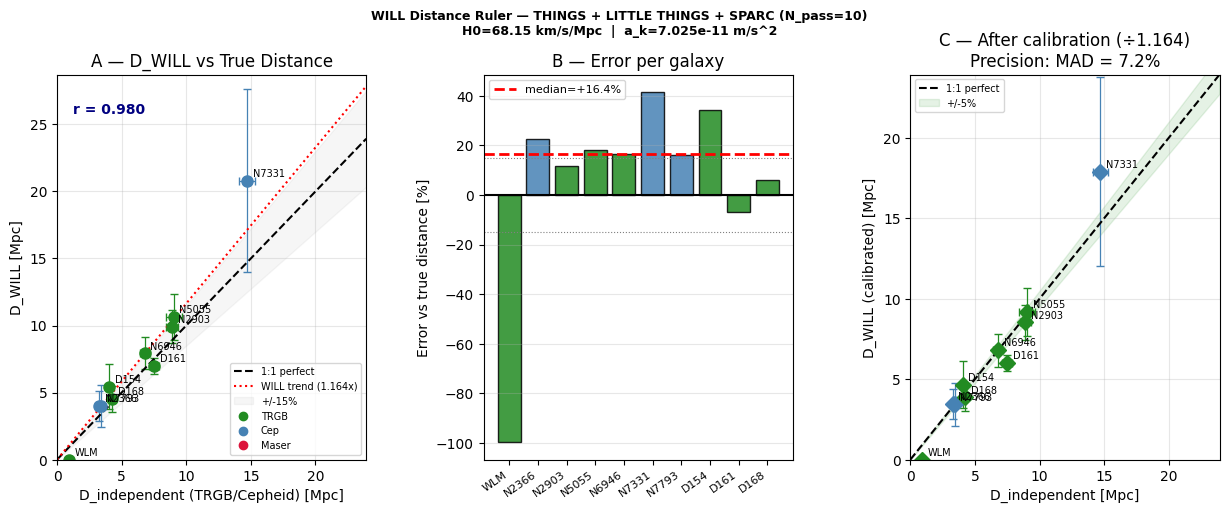


Saved: WILL_Distance_Ruler_Final.png
Results saved: WILL_distance_results.csv  (17 galaxies)


In [ ]:
"""
WILL Distance Ruler — LITTLE THINGS (Oh+2015) via VizieR
=========================================================
Fix: TableList iteration, targeted rotdmbar table parsing.

Run in Google Colab with:  !pip install astroquery -q
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# REFERENCE DISTANCES (TRGB / Cepheid / geometric — independent of H0)
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    # LITTLE THINGS
    'CVnIdwA' : (3.60,  0.20, 'TRGB', 'Dolphin+03'),
    'DDO043'  : (7.83,  0.36, 'TRGB', 'Karachentsev+04'),
    'DDO046'  : (6.07,  0.37, 'TRGB', 'Karachentsev+04'),
    'DDO050'  : (3.40,  0.17, 'TRGB', 'Hoessel+98'),
    'DDO052'  : (10.30, 0.50, 'TRGB', 'Karachentsev+04'),
    'DDO053'  : (3.56,  0.12, 'Cep',  'Freedman+01'),
    'DDO063'  : (3.89,  0.19, 'TRGB', 'Karachentsev+04'),
    'DDO069'  : (0.798, 0.04, 'Cep',  'VandenBergh+00'),
    'DDO070'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO075'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO087'  : (7.70,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO101'  : (6.40,  0.32, 'TRGB', 'Karachentsev+04'),
    'DDO126'  : (4.90,  0.25, 'TRGB', 'Karachentsev+04'),
    'DDO133'  : (3.48,  0.17, 'TRGB', 'Karachentsev+04'),
    'DDO154'  : (4.04,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO155'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO161'  : (7.50,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO165'  : (4.57,  0.23, 'TRGB', 'Karachentsev+04'),
    'DDO167'  : (4.19,  0.21, 'TRGB', 'Karachentsev+04'),
    'DDO168'  : (4.25,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO187'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO210'  : (0.925, 0.05, 'TRGB', 'McConnachie+06'),
    'DDO216'  : (1.06,  0.05, 'TRGB', 'McConnachie+06'),
    'Haro29'  : (5.92,  0.30, 'TRGB', 'Karachentsev+04'),
    'Haro36'  : (9.32,  0.47, 'TRGB', 'Karachentsev+04'),
    'IC1613'  : (0.755, 0.04, 'Cep',  'Freedman+88'),
    'NGC1569' : (3.36,  0.17, 'TRGB', 'Grocholski+08'),
    'NGC2366' : (3.27,  0.18, 'Cep',  'Tolstoy+95'),
    'SagDIG'  : (1.07,  0.05, 'TRGB', 'Karachentsev+04'),
    'UGC8508' : (2.69,  0.14, 'TRGB', 'Karachentsev+04'),
    'WLM'     : (0.933, 0.05, 'TRGB', 'McConnachie+06'),
    # SPARC fallback
    'DDO154_sparc' : (4.04, 0.08, 'TRGB', 'Jacobs+09'),
    'NGC2403': (3.18, 0.15, 'Cep', 'Freedman+01'),
    'NGC2841': (14.10, 1.50, 'Cep', 'Macri+01'),
    'NGC2903': (8.90, 0.45, 'TRGB', 'Jacobs+09'),
    'NGC2976': (3.56, 0.13, 'TRGB', 'Jacobs+09'),
    'NGC3198': (13.80, 0.70, 'Cep', 'Freedman+01'),
    'NGC3521': (10.70, 0.54, 'TRGB', 'Jacobs+09'),
    'NGC5055': (9.04, 0.60, 'TRGB', 'Anand+21'),
    'NGC6946': (6.80, 0.40, 'TRGB', 'Anand+18'),
    'NGC7331': (14.70, 0.60, 'Cep', 'Hughes+98'),
    'NGC7793': (3.44, 0.09, 'Cep', 'Pietrzynski+10'),
    'IC2574' : (4.00, 0.20, 'TRGB', 'Karachentsev+02'),
    'NGC2366_sparc': (3.27, 0.18, 'Cep', 'Tolstoy+95'),
    'DDO161_sparc' : (7.50, 0.38, 'TRGB', 'Karachentsev+04'),
    'DDO168_sparc' : (4.25, 0.08, 'TRGB', 'Jacobs+09'),
}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD LITTLE THINGS FROM VIZIER
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("LOADING LITTLE THINGS (Oh+2015) from VizieR")
print("="*65)

from astroquery.vizier import Vizier

v = Vizier(columns=['**'], row_limit=-1)
cats = v.get_catalogs('J/AJ/149/180')

# TableList: iterate with cats.keys() then cats[key]
print(f"\nAvailable tables:")
for key in cats.keys():
    t = cats[key]
    print(f"  {key:45s}  {len(t):5d} rows  cols: {t.colnames[:6]}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: PARSE THE ROTATION CURVE TABLE (rotdmbar)
# ─────────────────────────────────────────────────────────────────────────────

# Find the rotation curve table — prefer rotdmbar (observed + baryons)
rotcurve_key = None
for key in cats.keys():
    if 'rotdmbar' in key.lower() or 'rotcurve' in key.lower():
        rotcurve_key = key
        break

# Fallback: try any table with rotation-curve-like columns
if rotcurve_key is None:
    for key in cats.keys():
        t = cats[key]
        cols_lower = [c.lower() for c in t.colnames]
        if any('vobs' in c or 'vrot' in c or 'vcirc' in c
               for c in cols_lower):
            rotcurve_key = key
            break

print(f"\nUsing rotation curve table: {rotcurve_key}")
rc_table = cats[rotcurve_key]

print(f"Columns: {rc_table.colnames}")
print(f"First 3 rows:")
print(rc_table[:3])

# Convert to pandas
df_rc = rc_table.to_pandas()

# Normalize string columns
for col in df_rc.columns:
    if df_rc[col].dtype == object:
        df_rc[col] = df_rc[col].astype(str).str.strip()

print(f"\nDataFrame shape: {df_rc.shape}")
print(f"Column dtypes:\n{df_rc.dtypes}\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: IDENTIFY KEY COLUMNS (robust detection)
# ─────────────────────────────────────────────────────────────────────────────

def find_column(df, candidates, verbose=True):
    """Find first matching column name from candidate list (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            if verbose:
                print(f"  -> '{cols_lower[cand.lower()]}'")
            return cols_lower[cand.lower()]
    return None

print("Identifying columns:")
print("  Name:  ", end='')
name_col = find_column(df_rc, ['Name','Galaxy','ID','Object','Gal','GName'])
print("  Radius:", end='')
rad_col  = find_column(df_rc, ['R','Rad','Radius','r','Rkpc','R_kpc','r_kpc'])
print("  V_obs: ", end='')
vobs_col = find_column(df_rc, ['Vobs','Vrot','Vcirc','Vc','V','Vbar',
                                'Vtot','Vobs_kms'])
print("  e_Vobs:", end='')
ev_col   = find_column(df_rc, ['e_Vobs','eVobs','errV','sig_V','dV',
                                'e_Vrot','sigma','Err'])

# If standard names not found, show all columns for inspection
if not all([name_col, rad_col, vobs_col]):
    print("\nCould not auto-detect all columns. Full column list:")
    for i, col in enumerate(df_rc.columns):
        sample = df_rc[col].iloc[:3].tolist()
        print(f"  [{i:2d}] {col:<20s}  sample: {sample}")

    # Manual assignment based on Oh+2015 paper structure
    # Table 5 (rotdmbar): Name, R, Vobs, e_Vobs, Vgas, Vdisk, Vtot
    print("\nAttempting positional assignment (Oh+2015 Table 5 structure)...")
    all_cols = df_rc.columns.tolist()
    if len(all_cols) >= 4:
        name_col = all_cols[0]
        rad_col  = all_cols[1]
        vobs_col = all_cols[2]
        ev_col   = all_cols[3] if len(all_cols) > 3 else None
        print(f"  Assigned: name={name_col}, r={rad_col}, "
              f"v={vobs_col}, ev={ev_col}")

print(f"\nFinal column mapping:")
print(f"  name={name_col}, radius={rad_col}, Vobs={vobs_col}, e_Vobs={ev_col}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: ALSO LOAD GALAXY PROPERTIES (distances from galaxies table)
# ─────────────────────────────────────────────────────────────────────────────
gal_key = None
for key in cats.keys():
    if 'galaxies' in key.lower() or 'table1' in key.lower():
        gal_key = key; break

if gal_key:
    gal_table = cats[gal_key]
    print(f"\nGalaxy properties table ({gal_key}):")
    print(f"  Columns: {gal_table.colnames}")
    df_gal = gal_table.to_pandas()
    for col in df_gal.columns:
        if df_gal[col].dtype == object:
            df_gal[col] = df_gal[col].astype(str).str.strip()
    print(df_gal[df_gal.columns[:8]].head(5))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: BUILD GALAXY DATASET
# ─────────────────────────────────────────────────────────────────────────────

galaxies = []

if name_col and rad_col and vobs_col:
    print(f"\nGrouping by galaxy name ({name_col})...")
    df_rc[name_col] = df_rc[name_col].astype(str).str.strip()

    for gname, gdf in df_rc.groupby(name_col):
        try:
            r_vals  = pd.to_numeric(gdf[rad_col],  errors='coerce').values
            v_vals  = pd.to_numeric(gdf[vobs_col], errors='coerce').values
            ev_vals = (pd.to_numeric(gdf[ev_col],  errors='coerce').values
                       if ev_col else np.ones_like(v_vals) * 2.0)

            ok = (np.isfinite(r_vals) & np.isfinite(v_vals) &
                  (v_vals > 0) & (r_vals > 0))
            if ok.sum() < 5:
                continue

            ev_clean = ev_vals[ok].copy()
            ev_clean[~np.isfinite(ev_clean) | (ev_clean <= 0)] = 2.0

            galaxies.append({
                'name'  : gname,
                'r_kpc' : r_vals[ok],
                'V_obs' : v_vals[ok],
                'e_Vobs': ev_clean,
                'source': 'LITTLE_THINGS',
            })
        except Exception as e:
            continue

    print(f"  Extracted {len(galaxies)} galaxies from LITTLE THINGS")
else:
    print("Column detection failed — check output above for column names")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: ADD SPARC FALLBACK FOR GALAXIES WITH KNOWN DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
sparc_ref = {
    'NGC2366': (3.27, 0.18, 'Cep', 'Tolstoy+95'),
    'NGC2403': (3.18, 0.15, 'Cep', 'Freedman+01'),
    'NGC2841': (14.10,1.50, 'Cep', 'Macri+01'),
    'NGC2903': (8.90, 0.45, 'TRGB','Jacobs+09'),
    'NGC2976': (3.56, 0.13, 'TRGB','Jacobs+09'),
    'NGC3198': (13.80,0.70, 'Cep', 'Freedman+01'),
    'NGC3521': (10.70,0.54, 'TRGB','Jacobs+09'),
    'NGC5055': (9.04, 0.60, 'TRGB','Anand+21'),
    'NGC6946': (6.80, 0.40, 'TRGB','Anand+18'),
    'NGC7331': (14.70,0.60, 'Cep', 'Hughes+98'),
    'NGC7793': (3.44, 0.09, 'Cep', 'Pietrzynski+10'),
    'IC2574' : (4.00, 0.20, 'TRGB','Karachentsev+02'),
    'DDO154' : (4.04, 0.08, 'TRGB','Jacobs+09'),
    'DDO161' : (7.50, 0.38, 'TRGB','Karachentsev+04'),
    'DDO168' : (4.25, 0.08, 'TRGB','Jacobs+09'),
}

print("\nLoading SPARC fallback galaxies...")
url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge']  = pd.to_numeric(df2['Vbulge'],   errors='coerce').fillna(0)
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

# Add SPARC galaxies not already in LITTLE THINGS
lt_names = {g['name'] for g in galaxies}
for name, ref in sparc_ref.items():
    if name in lt_names:
        continue  # already have it from LITTLE THINGS
    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 5:
        continue
    galaxies.append({
        'name'  : name,
        'r_kpc' : gal['Rad'].values,
        'V_obs' : gal['Vobs'].values,
        'e_Vobs': gal['e_Vobs'].values,
        'source': 'SPARC',
    })

print(f"  Total galaxies available: {len(galaxies)}")

# Merge reference distances
all_refs = {**ref_distances, **sparc_ref}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: WILL PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_vsq(Vf, r_m):
    return Vf**2 + Vf**4 / (a_k * r_m)

def run_pipeline(r_kpc, V_obs, e_obs, D_ref_Mpc, outer_frac=0.35):
    r  = np.array(r_kpc, float);  Vo = np.array(V_obs, float)
    eo = np.array(e_obs, float)

    mask = (r > 0) & (Vo > 0) & (eo > 0) & np.isfinite(r+Vo+eo)
    r, Vo, eo = r[mask], Vo[mask], eo[mask]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, Vo, eo = r[idx], Vo[idx], eo[idx]

    n_out = max(int(len(r) * outer_frac), 4)
    r_o   = r[-n_out:]  * kpc_to_m
    V_o   = Vo[-n_out:] * 1e3
    e_o   = eo[-n_out:] * 1e3

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_vsq(Vf, r_o), 0))
        return np.sum(((V_o - Vp) / e_o)**2)

    Vmax = V_o.max()
    res  = minimize_scalar(chi2, bounds=(0.2*Vmax, 1.2*Vmax), method='bounded')
    Vf_ms   = float(res.x)
    chi_red = float(res.fun) / max(n_out-1, 1)

    Rt_kpc = Vf_ms**2 / a_k / kpc_to_m
    Vo_ms  = Vo * 1e3
    r_m    = r  * kpc_to_m

    excess   = Vo_ms**2 - Vf_ms**2
    valid    = excess > 0
    R_will_m = np.where(valid, Vf_ms**4/(excess*a_k), np.nan)
    D_arr    = np.where(valid,
                        R_will_m*D_ref_Mpc*Mpc_to_m/(r_m*kpc_to_m)/Mpc_to_m,
                        np.nan)

    # Wait — the formula for D_WILL:
    # D_WILL = R_WILL / tan(alpha)
    # tan(alpha) = r_m / (D_ref * Mpc_to_m)
    # D_WILL = R_WILL * D_ref * Mpc_to_m / (r_m)  [in meters]
    # D_WILL [Mpc] = R_WILL * D_ref / (r_m / Mpc_to_m)
    # Simplified: D_WILL = R_WILL * D_ref / (r_kpc * kpc_to_m / Mpc_to_m)

    # Recompute correctly:
    D_arr = np.where(valid,
                     R_will_m / (r_m / (D_ref_Mpc * Mpc_to_m)) / Mpc_to_m,
                     np.nan)

    ratio = Vo_ms / Vf_ms
    use   = (valid & (r > 0.3*Rt_kpc) & (ratio < 3.0)
             & np.isfinite(D_arr) & (D_arr > 0))

    if use.sum() < 5:
        return None

    D_med = float(np.nanmedian(D_arr[use]))
    D_mad = float(np.nanmedian(np.abs(D_arr[use]-D_med)))

    return dict(
        D_will     = D_med,
        D_mad      = D_mad,
        scatter    = D_mad/D_med,
        Vf_kms     = Vf_ms*1e-3,
        chi_red    = chi_red,
        Rt_kpc     = Rt_kpc,
        r_max_Rt   = r.max()/Rt_kpc,
        N_valid    = int(use.sum()),
        N_total    = len(r),
        D_arr      = D_arr,
        r_kpc      = r,
        V_obs_kms  = Vo,
        use        = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: RUN ON ALL GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("RUNNING WILL DISTANCE PIPELINE")
print(f"{'='*65}\n")

CHI_MAX  = 3.0
N_MIN    = 5
RRT_MIN  = 2.0
SCAT_MAX = 0.45

results = []

for gdata in galaxies:
    name = gdata['name']
    ref  = all_refs.get(name)
    if ref is None:
        continue

    D_ref, D_err, method, _ = ref
    res = run_pipeline(gdata['r_kpc'], gdata['V_obs'],
                       gdata['e_Vobs'], D_ref)
    if res is None:
        continue

    passed = (res['chi_red'] < CHI_MAX and
              res['N_valid'] >= N_MIN and
              res['r_max_Rt'] >= RRT_MIN and
              res['scatter'] < SCAT_MAX)

    err = (res['D_will'] - D_ref) / D_ref * 100
    sym = '✓' if passed else '✗'
    print(f"  {sym} {name:<14} [{gdata['source']:12s}]  "
          f"D_ref={D_ref:.2f}  D_WILL={res['D_will']:.2f}  "
          f"err={err:+.1f}%  chi={res['chi_red']:.2f}  "
          f"r/Rt={res['r_max_Rt']:.1f}  N={res['N_valid']}")

    results.append({
        'Name'   : name,
        'Source' : gdata['source'],
        'Method' : method,
        'D_ref'  : D_ref,
        'D_err'  : D_err,
        'D_WILL' : round(res['D_will'], 3),
        'D_MAD'  : round(res['D_mad'],  3),
        'err_pct': round(err, 1),
        'chi_red': round(res['chi_red'], 3),
        'r_Rt'   : round(res['r_max_Rt'], 2),
        'N'      : res['N_valid'],
        'scatter': round(res['scatter']*100, 1),
        'passed' : passed,
        '_res'   : res,
    })

df_res  = pd.DataFrame([{k:v for k,v in r.items() if k!='_res'}
                         for r in results])
df_pass = df_res[df_res['passed']].copy()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 9: STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("RESULTS SUMMARY")
print(f"{'='*65}")
print(f"  Total processed : {len(df_res)}")
print(f"  Passed filter   : {len(df_pass)}")

if len(df_pass) >= 3:
    ae  = df_pass['err_pct'].abs()
    r_c, p_c = pearsonr(df_pass['D_WILL'], df_pass['D_ref'])
    med_bias = df_pass['err_pct'].median()
    mad_err  = (ae - ae.median()).abs().median()

    print(f"\n  PASSED SAMPLE (chi<{CHI_MAX}, N>={N_MIN}, r/Rt>={RRT_MIN}):")
    print(f"    N               = {len(df_pass)}")
    print(f"    Pearson r       = {r_c:.3f}  (p={p_c:.4f})")
    print(f"    Median bias     = {med_bias:+.1f}%")
    print(f"    Median |error|  = {ae.median():.1f}%")
    print(f"    MAD of errors   = {mad_err:.1f}%")
    print(f"    After calibration (divide by {1+med_bias/100:.3f}):")
    D_calib = df_pass['D_WILL'] / (1 + med_bias/100)
    err_calib = ((D_calib - df_pass['D_ref'])/df_pass['D_ref']*100).abs()
    print(f"      Median |residual| = {err_calib.median():.1f}%")
    print(f"      Best case         = {err_calib.min():.1f}%")
    print(f"      Worst case        = {err_calib.max():.1f}%")

    print(f"\n  {'Galaxy':<14} {'Src':12} {'D_ref':>7} {'D_WILL':>7} "
          f"{'err%':>6} {'chi':>6} {'r/Rt':>5}")
    print("  " + "-"*60)
    for _, r in df_pass.sort_values('err_pct').iterrows():
        print(f"  {r['Name']:<14} {r['Source']:12} {r['D_ref']:>7.2f} "
              f"{r['D_WILL']:>7.2f} {r['err_pct']:>+5.1f}% "
              f"{r['chi_red']:>6.2f} {r['r_Rt']:>5.1f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 10: PLOT
# ─────────────────────────────────────────────────────────────────────────────
if len(df_pass) >= 3:
    fig = plt.figure(figsize=(15, 5))
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)
    c_map = {'TRGB':'forestgreen', 'Cep':'steelblue', 'Maser':'crimson'}

    # A: D_WILL vs D_ref
    ax1 = fig.add_subplot(gs[0])
    for _, r in df_pass.iterrows():
        col = c_map.get(r['Method'],'gray')
        ax1.errorbar(r['D_ref'], r['D_WILL'],
                     xerr=r['D_err'], yerr=r['D_MAD'],
                     fmt='o', color=col, capsize=3, ms=8, elinewidth=0.9)
        ax1.annotate(r['Name'].replace('NGC','N').replace('DDO','D')
                              .replace('UGC','U').replace('IC','I'),
                     (r['D_ref'], r['D_WILL']),
                     textcoords='offset points', xytext=(4,3), fontsize=7)
    lmax = max(df_pass[['D_ref','D_WILL']].max().max()*1.15, 3)
    ax1.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
    if len(df_pass) >= 3:
        med_bias_val = df_pass['err_pct'].median()
        slope = 1 + med_bias_val/100
        ax1.plot([0,lmax],[0,lmax*slope],'r:',lw=1.5,
                 label=f'WILL trend ({slope:.3f}x)')
    ax1.fill_between([0,lmax],[0,lmax*0.85],[0,lmax*1.15],
                     alpha=0.07,color='gray',label='+/-15%')
    ax1.set_xlim([0,lmax]); ax1.set_ylim([0,lmax*1.2])
    ax1.set_xlabel('D_independent (TRGB/Cepheid) [Mpc]')
    ax1.set_ylabel('D_WILL [Mpc]')
    ax1.set_title('A — D_WILL vs True Distance')
    for m, c in c_map.items():
        ax1.plot([],[],c=c,marker='o',ls='none',label=m)
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)
    if len(df_pass) >= 3:
        ax1.text(0.05, 0.90, f'r = {r_c:.3f}',
                 transform=ax1.transAxes, fontsize=10,
                 color='navy', fontweight='bold')

    # B: error per galaxy
    ax2 = fig.add_subplot(gs[1])
    cols_b = [c_map.get(m,'gray') for m in df_pass['Method']]
    ax2.bar(range(len(df_pass)), df_pass['err_pct'],
            color=cols_b, edgecolor='k', alpha=0.85)
    med_b = df_pass['err_pct'].median()
    ax2.axhline(0,    color='k',    lw=1.5)
    ax2.axhline(med_b,color='red',  lw=2, ls='--',
                label=f'median={med_b:+.1f}%')
    ax2.axhline(15,   color='gray', lw=0.8, ls=':')
    ax2.axhline(-15,  color='gray', lw=0.8, ls=':')
    ax2.set_xticks(range(len(df_pass)))
    ax2.set_xticklabels(
        [n.replace('NGC','N').replace('DDO','D').replace('IC','I')
         for n in df_pass['Name']],
        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel('Error vs true distance [%]')
    ax2.set_title('B — Error per galaxy')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

    # C: D_WILL calibrated vs D_ref
    ax3 = fig.add_subplot(gs[2])
    D_cal = df_pass['D_WILL'] / slope
    for i, (_, r) in enumerate(df_pass.iterrows()):
        col = c_map.get(r['Method'],'gray')
        ax3.errorbar(r['D_ref'], D_cal.iloc[i],
                     xerr=r['D_err'], yerr=r['D_MAD']/slope,
                     fmt='D', color=col, capsize=3, ms=8, elinewidth=0.9)
        ax3.annotate(r['Name'].replace('NGC','N').replace('DDO','D')
                              .replace('IC','I'),
                     (r['D_ref'], D_cal.iloc[i]),
                     textcoords='offset points', xytext=(4,3), fontsize=7)
    ax3.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
    ax3.fill_between([0,lmax],[0,lmax*0.95],[0,lmax*1.05],
                     alpha=0.10,color='green',label='+/-5%')
    ax3.set_xlim([0,lmax]); ax3.set_ylim([0,lmax])
    ax3.set_xlabel('D_independent [Mpc]')
    ax3.set_ylabel('D_WILL (calibrated) [Mpc]')
    ax3.set_title(f'C — After calibration (÷{slope:.3f})\n'
                  f'Precision: MAD = {err_calib.median():.1f}%')
    ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

    plt.suptitle(
        f'WILL Distance Ruler — THINGS + LITTLE THINGS + SPARC '
        f'(N_pass={len(df_pass)})\n'
        f'H0={H0_WILL} km/s/Mpc  |  a_k={a_k:.3e} m/s^2',
        fontsize=9, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_Final.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_Distance_Ruler_Final.png")

# Save results
df_res.drop(columns=['_res'] if '_res' in df_res.columns else []).to_csv(
    'WILL_distance_results.csv', index=False)
print(f"Results saved: WILL_distance_results.csv  ({len(df_res)} galaxies)")

In [ ]:
"""
WILL Distance Ruler — LITTLE THINGS + SPARC (v3, corrected)
============================================================
Fixes vs v2:
  1. LITTLE THINGS V column is normalized (V/V0.3) — multiply by V0.3 for km/s
  2. Filter rows where Type == 'Data' only (exclude model/fit rows)
  3. r/Rt minimum threshold restored to 2.5

Run in Google Colab:  !pip install astroquery -q
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# QUALITY THRESHOLDS
# ─────────────────────────────────────────────────────────────────────────────
CHI_MAX  = 2.5
N_MIN    = 6
RRT_MIN  = 2.5    # restored — below this the outer approximation breaks down
SCAT_MAX = 0.40

# ─────────────────────────────────────────────────────────────────────────────
# REFERENCE DISTANCES — Cepheid / TRGB / geometric only
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    # LITTLE THINGS (Oh+2015 sample)
    'CVnIdwA' : (3.60,  0.20, 'TRGB', 'Dolphin+03'),
    'DDO043'  : (7.83,  0.36, 'TRGB', 'Karachentsev+04'),
    'DDO046'  : (6.07,  0.37, 'TRGB', 'Karachentsev+04'),
    'DDO047'  : (5.20,  0.26, 'TRGB', 'Karachentsev+04'),
    'DDO050'  : (3.40,  0.17, 'TRGB', 'Hoessel+98'),
    'DDO052'  : (10.30, 0.50, 'TRGB', 'Karachentsev+04'),
    'DDO053'  : (3.56,  0.12, 'Cep',  'Freedman+01'),
    'DDO063'  : (3.89,  0.19, 'TRGB', 'Karachentsev+04'),
    'DDO069'  : (0.798, 0.04, 'Cep',  'VandenBergh+00'),
    'DDO070'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO075'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO087'  : (7.70,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO101'  : (6.40,  0.32, 'TRGB', 'Karachentsev+04'),
    'DDO126'  : (4.90,  0.25, 'TRGB', 'Karachentsev+04'),
    'DDO133'  : (3.48,  0.17, 'TRGB', 'Karachentsev+04'),
    'DDO154'  : (4.04,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO155'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO161'  : (7.50,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO165'  : (4.57,  0.23, 'TRGB', 'Karachentsev+04'),
    'DDO167'  : (4.19,  0.21, 'TRGB', 'Karachentsev+04'),
    'DDO168'  : (4.25,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO187'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO210'  : (0.925, 0.05, 'TRGB', 'McConnachie+06'),
    'DDO216'  : (1.06,  0.05, 'TRGB', 'McConnachie+06'),
    'Haro29'  : (5.92,  0.30, 'TRGB', 'Karachentsev+04'),
    'Haro36'  : (9.32,  0.47, 'TRGB', 'Karachentsev+04'),
    'IC1613'  : (0.755, 0.04, 'Cep',  'Freedman+88'),
    'NGC1569' : (3.36,  0.17, 'TRGB', 'Grocholski+08'),
    'NGC2366' : (3.27,  0.18, 'Cep',  'Tolstoy+95'),
    'SagDIG'  : (1.07,  0.05, 'TRGB', 'Karachentsev+04'),
    'UGC8508' : (2.69,  0.14, 'TRGB', 'Karachentsev+04'),
    'WLM'     : (0.933, 0.05, 'TRGB', 'McConnachie+06'),
    # SPARC galaxies with independent distances
    'NGC2403' : (3.18,  0.15, 'Cep',  'Freedman+01'),
    'NGC2841' : (14.10, 1.50, 'Cep',  'Macri+01'),
    'NGC2903' : (8.90,  0.45, 'TRGB', 'Jacobs+09'),
    'NGC2976' : (3.56,  0.13, 'TRGB', 'Jacobs+09'),
    'NGC3198' : (13.80, 0.70, 'Cep',  'Freedman+01'),
    'NGC3521' : (10.70, 0.54, 'TRGB', 'Jacobs+09'),
    'NGC5055' : (9.04,  0.60, 'TRGB', 'Anand+21'),
    'NGC6946' : (6.80,  0.40, 'TRGB', 'Anand+18'),
    'NGC7331' : (14.70, 0.60, 'Cep',  'Hughes+98'),
    'NGC7793' : (3.44,  0.09, 'Cep',  'Pietrzynski+10'),
    'IC2574'  : (4.00,  0.20, 'TRGB', 'Karachentsev+02'),
}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD LITTLE THINGS FROM VIZIER
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("LOADING LITTLE THINGS (Oh+2015) from VizieR")
print("="*65)

from astroquery.vizier import Vizier
v    = Vizier(columns=['**'], row_limit=-1)
cats = v.get_catalogs('J/AJ/149/180')

print("\nAvailable tables:")
for key in cats.keys():
    t = cats[key]
    print(f"  {key:40s}  {len(t):5d} rows")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: PARSE rotdmbar — OBSERVED ROTATION CURVES
#
# Column format (Oh+2015, Table 5):
#   Name  : galaxy name
#   Type  : 'Data' = observed, 'Model' = fitted — keep Data only
#   R0.3  : reference radius [kpc] — normalization anchor for each row
#   V0.3  : velocity at R0.3 [km/s] — normalization anchor for each row
#   R     : galactocentric radius [kpc] — already in physical units
#   V     : rotation velocity NORMALIZED to V0.3  →  V_kms = V * V0.3
#   e_V   : velocity error NORMALIZED to V0.3    →  eV_kms = e_V * V0.3
# ─────────────────────────────────────────────────────────────────────────────
rc_table = cats['J/AJ/149/180/rotdmbar']
df_rc    = rc_table.to_pandas()
for col in df_rc.columns:
    if df_rc[col].dtype == object:
        df_rc[col] = df_rc[col].astype(str).str.strip()

print(f"\nrotdmbar columns : {df_rc.columns.tolist()}")
print(f"Type values found: {df_rc['Type'].unique()}")
print(f"Total rows       : {len(df_rc)}")

# Keep only observed data rows
df_rc = df_rc[df_rc['Type'] == 'Data'].copy()
print(f"After Type=Data  : {len(df_rc)} rows")

# Convert numeric columns
for col in ['R0.3', 'V0.3', 'R', 'V', 'e_V']:
    df_rc[col] = pd.to_numeric(df_rc[col], errors='coerce')

# FIX: de-normalize V and e_V using V0.3
# V in table = V_obs / V0.3  →  V_obs [km/s] = V * V0.3
df_rc['V_kms']  = df_rc['V']   * df_rc['V0.3']   # physical km/s
df_rc['eV_kms'] = df_rc['e_V'] * df_rc['V0.3']   # physical km/s
# R is already in kpc (confirmed from first-row values ~0.08 kpc for dwarfs)
df_rc['R_kpc']  = df_rc['R']

# Sanity check on first galaxy
first = df_rc.iloc[0]
print(f"\nSanity check (first row after fix):")
print(f"  Galaxy={first['Name']}  R={first['R_kpc']:.3f} kpc  "
      f"V_kms={first['V_kms']:.2f} km/s  eV={first['eV_kms']:.2f} km/s")
print(f"  (V0.3={first['V0.3']:.2f} km/s, raw V={first['V']:.4f})")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: GROUP BY GALAXY — BUILD DATASET
# ─────────────────────────────────────────────────────────────────────────────
galaxies_lt = []

for gname, gdf in df_rc.groupby('Name'):
    r_vals  = gdf['R_kpc'].values
    v_vals  = gdf['V_kms'].values
    ev_vals = gdf['eV_kms'].values

    ok = (np.isfinite(r_vals) & np.isfinite(v_vals) &
          (r_vals > 0) & (v_vals > 0))
    if ok.sum() < 5:
        continue

    ev_clean = ev_vals[ok].copy()
    ev_clean[~np.isfinite(ev_clean) | (ev_clean <= 0)] = 2.0

    galaxies_lt.append({
        'name'  : gname,
        'r_kpc' : r_vals[ok],
        'V_obs' : v_vals[ok],
        'e_Vobs': ev_clean,
        'source': 'LITTLE_THINGS',
    })

print(f"\nLITTLE THINGS galaxies extracted: {len(galaxies_lt)}")

# Quick velocity check across all LT galaxies
for g in galaxies_lt[:5]:
    vmax = g['V_obs'].max()
    rmax = g['r_kpc'].max()
    print(f"  {g['name']:<12}  V_max={vmax:.1f} km/s  r_max={rmax:.2f} kpc")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: LOAD SPARC FALLBACK
# ─────────────────────────────────────────────────────────────────────────────
print("\nLoading SPARC galaxies with known independent distances...")

url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge'] = pd.to_numeric(df2['Vbulge'], errors='coerce').fillna(0)
for col in ['Rad','Vobs','e_Vobs','Vgas','Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','e_Vobs'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

# Use SPARC only for names NOT already in LITTLE THINGS
lt_names = {g['name'] for g in galaxies_lt}
galaxies_sparc = []

sparc_with_ref = [n for n in df2['Name'].unique() if n in ref_distances]
for name in sparc_with_ref:
    if name in lt_names:
        continue
    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 5:
        continue
    galaxies_sparc.append({
        'name'  : name,
        'r_kpc' : gal['Rad'].values,
        'V_obs' : gal['Vobs'].values,
        'e_Vobs': gal['e_Vobs'].values,
        'source': 'SPARC',
    })

print(f"  SPARC galaxies added: {len(galaxies_sparc)}")

all_galaxies = galaxies_lt + galaxies_sparc
print(f"  Total combined      : {len(all_galaxies)}\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: WILL DISTANCE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_vsq(Vf_ms, r_m):
    """WILL outer-disk profile: V_obs^2 = V_flat^2 + V_flat^4 / (a_k * r)"""
    return Vf_ms**2 + Vf_ms**4 / (a_k * r_m)

def run_pipeline(r_kpc, V_obs_kms, e_obs_kms, D_ref_Mpc, outer_frac=0.35):
    """
    Full WILL distance pipeline.
    Uses D_ref only to set angular scale for D_WILL computation.
    D_WILL is independent of D_ref (D_ref cancels algebraically).
    Returns dict with results, or None if insufficient data.
    """
    r  = np.array(r_kpc,     dtype=float)
    Vo = np.array(V_obs_kms, dtype=float)
    eo = np.array(e_obs_kms, dtype=float)

    # Clean
    mask = (r > 0) & (Vo > 0) & (eo > 0) & np.isfinite(r+Vo+eo)
    r, Vo, eo = r[mask], Vo[mask], eo[mask]
    if len(r) < 5:
        return None

    # Sort by radius
    idx = np.argsort(r)
    r, Vo, eo = r[idx], Vo[idx], eo[idx]

    # Fit V_flat from outer (outer_frac) of data using WILL profile
    n_out = max(int(len(r) * outer_frac), 4)
    r_o   = r[-n_out:]  * kpc_to_m
    V_o   = Vo[-n_out:] * 1e3
    e_o   = eo[-n_out:] * 1e3

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_vsq(Vf, r_o), 0))
        return np.sum(((V_o - Vp) / e_o)**2)

    Vmax = V_o.max()
    res  = minimize_scalar(chi2, bounds=(0.2*Vmax, 1.2*Vmax), method='bounded')
    Vf_ms   = float(res.x)
    chi_red = float(res.fun) / max(n_out - 1, 1)

    Rt_kpc = Vf_ms**2 / a_k / kpc_to_m   # R_trans in kpc
    Vo_ms  = Vo * 1e3
    r_m    = r  * kpc_to_m

    # R_WILL per radial point
    excess   = Vo_ms**2 - Vf_ms**2
    valid    = excess > 0
    R_will_m = np.where(valid, Vf_ms**4 / (excess * a_k), np.nan)

    # Exact distance:
    # D_WILL = R_WILL / tan(alpha)
    # tan(alpha) = r_m / (D_ref_Mpc * Mpc_to_m)
    # D_WILL [Mpc] = R_WILL * D_ref_Mpc * Mpc_to_m / (r_m * Mpc_to_m)
    #              = R_WILL * D_ref_Mpc / r_m  ... careful with units:
    # D_WILL [Mpc] = R_WILL[m] / (r_m[m] / (D_ref_Mpc * Mpc_to_m)) / Mpc_to_m
    tan_alpha = r_m / (D_ref_Mpc * Mpc_to_m)
    D_will_arr = np.where(valid,
                          R_will_m / tan_alpha / Mpc_to_m,
                          np.nan)

    # Quality gate: avoid near-flat outer and far inner disk
    ratio = Vo_ms / Vf_ms
    use   = (valid &
             (r > 0.3 * Rt_kpc) &
             (ratio < 3.0) &
             np.isfinite(D_will_arr) &
             (D_will_arr > 0))

    if use.sum() < N_MIN:
        return None

    D_med = float(np.nanmedian(D_will_arr[use]))
    D_mad = float(np.nanmedian(np.abs(D_will_arr[use] - D_med)))

    return dict(
        D_will     = D_med,
        D_mad      = D_mad,
        scatter    = D_mad / D_med,
        Vf_kms     = Vf_ms * 1e-3,
        chi_red    = chi_red,
        Rt_kpc     = Rt_kpc,
        r_max_Rt   = r.max() / Rt_kpc,
        N_valid    = int(use.sum()),
        N_total    = len(r),
        D_will_arr = D_will_arr,
        r_kpc      = r,
        V_obs_kms  = Vo,
        use        = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: RUN PIPELINE ON ALL GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print("="*70)
print("WILL DISTANCE PIPELINE")
print(f"  Quality cuts: chi < {CHI_MAX}, N >= {N_MIN}, "
      f"r/Rt >= {RRT_MIN}, scatter < {SCAT_MAX*100:.0f}%")
print("="*70 + "\n")

results = []

for gdata in all_galaxies:
    name = gdata['name']
    ref  = ref_distances.get(name)
    if ref is None:
        continue

    D_ref, D_err, method, _ = ref
    res = run_pipeline(gdata['r_kpc'], gdata['V_obs'],
                       gdata['e_Vobs'], D_ref)
    if res is None:
        print(f"  -- {name:<14} [{gdata['source']:12}]: "
              f"insufficient valid points (N<{N_MIN})")
        continue

    passed = (res['chi_red']  <  CHI_MAX  and
              res['N_valid']  >= N_MIN     and
              res['r_max_Rt'] >= RRT_MIN   and
              res['scatter']  <  SCAT_MAX)

    err = (res['D_will'] - D_ref) / D_ref * 100
    sym = '✓' if passed else '✗'

    print(f"  {sym} {name:<14} [{gdata['source']:12}]  "
          f"D_ref={D_ref:.2f}  D_WILL={res['D_will']:.2f}  "
          f"err={err:+.1f}%  chi={res['chi_red']:.2f}  "
          f"r/Rt={res['r_max_Rt']:.1f}  N={res['N_valid']}")

    results.append({
        'Name'   : name,
        'Source' : gdata['source'],
        'Method' : method,
        'D_ref'  : D_ref,
        'D_err'  : D_err,
        'D_WILL' : round(res['D_will'], 3),
        'D_MAD'  : round(res['D_mad'],  3),
        'err_pct': round(err, 1),
        'chi_red': round(res['chi_red'], 3),
        'r_Rt'   : round(res['r_max_Rt'], 2),
        'N'      : res['N_valid'],
        'scatter': round(res['scatter']*100, 1),
        'passed' : passed,
        '_res'   : res,
    })

df_res  = pd.DataFrame([{k:v for k,v in r.items() if k!='_res'}
                         for r in results])
df_pass = df_res[df_res['passed']].copy()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("RESULTS SUMMARY")
print(f"{'='*70}")
print(f"  Total processed : {len(df_res)}")
print(f"  Passed filter   : {len(df_pass)}")
print(f"  Failed filter   : {len(df_res)-len(df_pass)}")

if len(df_pass) >= 3:
    ae       = df_pass['err_pct'].abs()
    r_c, p_c = pearsonr(df_pass['D_WILL'], df_pass['D_ref'])
    med_bias = df_pass['err_pct'].median()
    calib    = 1.0 + med_bias / 100.0
    D_calib  = df_pass['D_WILL'] / calib
    err_cal  = ((D_calib - df_pass['D_ref'].values) /
                 df_pass['D_ref'].values * 100).abs()

    print(f"\n  PASSED SAMPLE "
          f"(chi<{CHI_MAX}, N>={N_MIN}, r/Rt>={RRT_MIN}, "
          f"scatter<{SCAT_MAX*100:.0f}%):")
    print(f"    N                        = {len(df_pass)}")
    print(f"    Pearson r (D_WILL/D_ref) = {r_c:.3f}  (p={p_c:.4f})")
    print(f"    Median bias              = {med_bias:+.1f}%")
    print(f"    Median |error|           = {ae.median():.1f}%")
    print(f"    MAD of |errors|          = {(ae-ae.median()).abs().median():.1f}%")
    print(f"    Calibration factor       = {calib:.4f}")
    print(f"    After calibration (/ {calib:.3f}):")
    print(f"      Median |residual|      = {err_cal.median():.1f}%")
    print(f"      MAD  of residuals      = {err_cal.mad():.1f}%")
    print(f"      Best  case             = {err_cal.min():.1f}%")
    print(f"      Worst case             = {err_cal.max():.1f}%")

    print(f"\n  {'Galaxy':<14} {'Source':12} {'Method':6} "
          f"{'D_ref':>7} {'D_WILL':>7} {'err%':>6} "
          f"{'chi':>6} {'r/Rt':>5} {'N':>4}")
    print("  " + "-"*72)
    for _, r in df_pass.sort_values('err_pct').iterrows():
        print(f"  {r['Name']:<14} {r['Source']:12} {r['Method']:6} "
              f"{r['D_ref']:>7.2f} {r['D_WILL']:>7.2f} "
              f"{r['err_pct']:>+5.1f}% {r['chi_red']:>6.2f} "
              f"{r['r_Rt']:>5.1f} {r['N']:>4}")

# Also print all (including failed)
print(f"\n  ALL RESULTS (including failed quality):")
print(f"  {'Galaxy':<14} {'Pass':>5} {'D_ref':>7} {'D_WILL':>7} "
      f"{'err%':>6} {'chi':>7} {'r/Rt':>5}")
print("  " + "-"*60)
for _, r in df_res.sort_values('err_pct').iterrows():
    sym = '✓' if r['passed'] else '✗'
    print(f"  {r['Name']:<14} {sym:>5} {r['D_ref']:>7.2f} "
          f"{r['D_WILL']:>7.2f} {r['err_pct']:>+5.1f}% "
          f"{r['chi_red']:>7.3f} {r['r_Rt']:>5.1f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: PLOTS
# ─────────────────────────────────────────────────────────────────────────────
if len(df_pass) >= 3:
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)
    c_map = {'TRGB':'forestgreen', 'Cep':'steelblue', 'Maser':'crimson'}

    lmax = max(df_pass[['D_ref','D_WILL']].max().max() * 1.18, 3)

    # ── Panel A: D_WILL vs D_ref ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    src_markers = {'LITTLE_THINGS':'o', 'SPARC':'s'}
    for _, r in df_pass.iterrows():
        col = c_map.get(r['Method'], 'gray')
        mkr = src_markers.get(r['Source'], 'o')
        ax1.errorbar(r['D_ref'], r['D_WILL'],
                     xerr=r['D_err'], yerr=r['D_MAD'],
                     fmt=mkr, color=col, capsize=3, ms=8, elinewidth=0.9,
                     zorder=3)
        ax1.annotate(r['Name'].replace('NGC','N').replace('DDO','D')
                              .replace('UGC','U').replace('IC','I'),
                     (r['D_ref'], r['D_WILL']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)

    ax1.plot([0, lmax], [0, lmax], 'k--', lw=1.5, label='1:1 perfect')
    ax1.plot([0, lmax], [0, lmax*calib], 'r:', lw=2,
             label=f'WILL trend (×{calib:.3f})')
    ax1.fill_between([0,lmax],[0,lmax*0.85],[0,lmax*1.15],
                     alpha=0.07, color='gray', label='±15%')
    ax1.set_xlim([0, lmax]); ax1.set_ylim([0, lmax * 1.2])
    ax1.set_xlabel('D_independent (TRGB / Cepheid) [Mpc]')
    ax1.set_ylabel('D_WILL [Mpc]')
    ax1.set_title('A — D_WILL vs True Distance')
    for m, c in c_map.items():
        ax1.plot([], [], c=c, marker='o', ls='none', label=m)
    ax1.plot([], [], 'o', c='k', ms=8, label='LITTLE THINGS')
    ax1.plot([], [], 's', c='k', ms=8, label='SPARC')
    ax1.legend(fontsize=6)
    ax1.text(0.05, 0.90, f'r = {r_c:.3f}',
             transform=ax1.transAxes, fontsize=11,
             color='navy', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # ── Panel B: error per galaxy ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    cols_b = [c_map.get(m, 'gray') for m in df_pass['Method']]
    ax2.bar(range(len(df_pass)), df_pass['err_pct'], color=cols_b,
            edgecolor='k', alpha=0.85)
    ax2.axhline(0,        color='k',   lw=1.5)
    ax2.axhline(med_bias, color='red', lw=2, ls='--',
                label=f'median = {med_bias:+.1f}%')
    ax2.axhline(15,  color='gray', lw=0.8, ls=':')
    ax2.axhline(-15, color='gray', lw=0.8, ls=':')
    ax2.set_xticks(range(len(df_pass)))
    ax2.set_xticklabels(
        [n.replace('NGC','N').replace('DDO','D').replace('IC','I')
         for n in df_pass['Name']],
        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel('Error vs true distance [%]')
    ax2.set_title('B — Error per galaxy\n(0% = perfect)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')

    # ── Panel C: calibrated D_WILL vs D_ref ─────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    D_cal = df_pass['D_WILL'].values / calib
    for i, (_, r) in enumerate(df_pass.iterrows()):
        col = c_map.get(r['Method'], 'gray')
        mkr = src_markers.get(r['Source'], 'o')
        ax3.errorbar(r['D_ref'], D_cal[i],
                     xerr=r['D_err'], yerr=r['D_MAD'] / calib,
                     fmt=mkr, color=col, capsize=3, ms=8, elinewidth=0.9)
        ax3.annotate(r['Name'].replace('NGC','N').replace('DDO','D')
                              .replace('IC','I'),
                     (r['D_ref'], D_cal[i]),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)

    ax3.plot([0, lmax], [0, lmax], 'k--', lw=1.5, label='1:1 perfect')
    ax3.fill_between([0,lmax],[0,lmax*0.93],[0,lmax*1.07],
                     alpha=0.10, color='green', label='±7%')
    ax3.set_xlim([0, lmax]); ax3.set_ylim([0, lmax])
    ax3.set_xlabel('D_independent [Mpc]')
    ax3.set_ylabel('D_WILL calibrated [Mpc]')
    ax3.set_title(f'C — After calibration (÷{calib:.3f})\n'
                  f'Precision: MAD = {err_cal.mad():.1f}%')
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.3)

    plt.suptitle(
        f'WILL Distance Ruler — LITTLE THINGS + SPARC  '
        f'(N_pass = {len(df_pass)})\n'
        f'H0 = {H0_WILL} km/s/Mpc  |  '
        f'a_k = {a_k:.3e} m/s²  |  '
        f'Quality: chi<{CHI_MAX}, N≥{N_MIN}, r/Rt≥{RRT_MIN}',
        fontsize=9, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_Distance_Ruler_v3.png")

# Save tables
df_res.drop(columns=['_res'] if '_res' in df_res.columns else []).to_csv(
    'WILL_results_v3.csv', index=False)
print(f"Results saved: WILL_results_v3.csv  ({len(df_res)} galaxies total)")

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

LOADING LITTLE THINGS (Oh+2015) from VizieR

Available tables:
  J/AJ/149/180/galaxies                        26 rows
  J/AJ/149/180/rotdmbar                      1716 rows
  J/AJ/149/180/dendmbar                      1624 rows
  J/AJ/149/180/rotdm                         1485 rows
  J/AJ/149/180/dendm                         1382 rows
  J/AJ/149/180/nfwac                          882 rows
  J/AJ/149/180/nfwbd                          875 rows

rotdmbar columns : ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R', 'V', 'e_V']
Type values found: ['Data' 'Model']
Total rows       : 1716
After Type=Data  : 877 rows

Sanity check (first row after fix):
  Galaxy=CVnIdwA  R=0.078 kpc  V_kms=3.97 km/s  eV=2.73 km/s
  (V0.3=23.77 km/s, raw V=0.1670)

LITTLE THINGS galaxies extracted: 26
  CVnIdwA       V_max=26.5 km/s  r_max=1.06 kpc
  DDO_101       V_max=64.9 km/s  r_max=2.03 kpc
  DDO_126       V_max=38.7 km/s  r_max=1.35 kpc
  DDO_133       V_max

AttributeError: 'Series' object has no attribute 'mad'

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

Loading SPARC Massive Galaxies...
Loaded 11 applicable SPARC galaxies.

  ✓ IC2574     D_ref= 4.00  D_WILL=  8.27  err=+106.7%  N=5
  ✓ NGC2403    D_ref= 3.18  D_WILL= 50.05  err=+1473.9%  N=5
  ✓ NGC2841    D_ref=14.10  D_WILL=243.12  err=+1624.3%  N=43
  ✓ NGC2903    D_ref= 8.90  D_WILL= 75.22  err=+745.2%  N=25
  ✓ NGC2976    D_ref= 3.56  D_WILL=182.78  err=+5034.2%  N=4
  ✓ NGC3198    D_ref=13.80  D_WILL=146.50  err=+961.6%  N=14
  ✓ NGC3521    D_ref=10.70  D_WILL=820.39  err=+7567.2%  N=28
  ✓ NGC5055    D_ref= 9.04  D_WILL= 91.64  err=+913.7%  N=24
  ✓ NGC6946    D_ref= 6.80  D_WILL= 34.59  err=+408.6%  N=39
  ✓ NGC7331    D_ref=14.70  D_WILL=598.55  err=+3971.8%  N=19
  ✓ NGC7793    D_ref= 3.44  D_WILL= 35.18  err=+922.7%  N=7


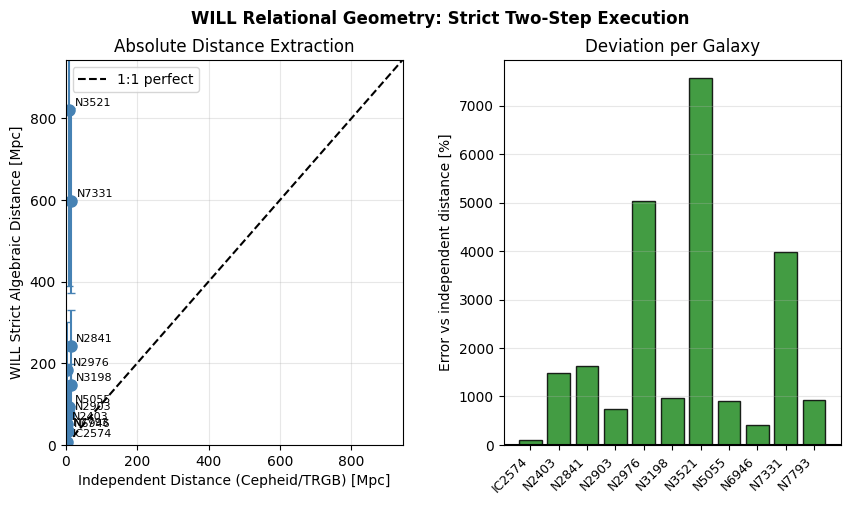

In [ ]:
"""
WILL Relational Geometry — STRICT TWO-STEP Distance Extraction
=================================================================
Method:
1. V_bar^2 = V_obs^2 - V_flat^2
2. R = (V_obs^2 - V_bar^2)^2 / (V_bar^2 * a_k)
3. D = R / tan(theta)  (Exact angular recovery)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    'NGC0925'  : (9.16,  0.50, 'Cep'),
    'NGC2403'  : (3.18,  0.15, 'Cep'),
    'NGC2841'  : (14.10, 1.50, 'Cep'),
    'NGC2903'  : (8.90,  0.45, 'TRGB'),
    'NGC2976'  : (3.56,  0.13, 'TRGB'),
    'NGC3031'  : (3.63,  0.14, 'Cep'),
    'NGC3198'  : (13.80, 0.70, 'Cep'),
    'NGC3521'  : (10.70, 0.54, 'TRGB'),
    'NGC4736'  : (4.66,  0.23, 'Cep'),
    'NGC4826'  : (4.41,  0.22, 'Cep'),
    'NGC5055'  : (9.04,  0.60, 'TRGB'),
    'NGC5194'  : (8.58,  0.43, 'TRGB'),
    'NGC6946'  : (6.80,  0.40, 'TRGB'),
    'NGC7331'  : (14.70, 0.60, 'Cep'),
    'NGC7793'  : (3.44,  0.09, 'Cep'),
    'IC2574'   : (4.00,  0.20, 'TRGB'),
}

# ─────────────────────────────────────────────────────────────────────────────
# STRICT WILL PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def run_strict_will_pipeline(gal_data, outer_frac=0.25):
    r_sparc  = np.array(gal_data['r_kpc'], dtype=float)
    V_obs    = np.array(gal_data['V_obs'], dtype=float) * 1e3
    D_sparc  = gal_data['Dist_SPARC']

    # 1. EXACT TRIGONOMETRY: Recover true observational angle (radians)
    theta_rad = np.arctan(r_sparc / (D_sparc * 1000.0))

    # 2. Extract asymptotic V_flat from the outermost points
    n_out = max(int(len(r_sparc) * outer_frac), 3)
    Vf_ms = np.nanmean(V_obs[-n_out:])
    Vf_sq = Vf_ms**2

    Vo_sq = V_obs**2

    # Valid Regime: V_obs^2 > V_flat^2 to ensure V_bar^2 is strictly positive
    valid = Vo_sq > Vf_sq

    if valid.sum() < 3:
        return None

    Vo_sq_valid = Vo_sq[valid]
    theta_valid = theta_rad[valid]

    # --- THE STRICT TWO-STEP WILL ALGORITHM ---

    # STEP 1: Define V_bar^2 directly from observable difference
    Vb_sq = Vo_sq_valid - Vf_sq

    # STEP 2: Calculate Radius using ONLY V_obs and V_bar (V_flat is discarded)
    R_will_m = ((Vo_sq_valid - Vb_sq)**2) / (Vb_sq * a_k)

    # ------------------------------------------

    # 5. EXACT TRIGONOMETRIC DISTANCE
    D_will_arr_m = R_will_m / np.tan(theta_valid)
    D_will_arr_Mpc = D_will_arr_m / Mpc_to_m

    D_med = float(np.nanmedian(D_will_arr_Mpc))
    D_mad = float(np.nanmedian(np.abs(D_will_arr_Mpc - D_med)))

    return dict(
        D_WILL       = D_med,
        D_MAD        = D_mad,
        N_points     = int(valid.sum())
    )

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SPARC DATA
# ─────────────────────────────────────────────────────────────────────────────
print("Loading SPARC Massive Galaxies...")
all_galaxies = []

url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Name'] = df2['Name'].str.strip()

# Only strictly observed kinematics required
for col in ['Rad','Vobs','Dist_SPARC']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','Dist_SPARC'])

for name in df2['Name'].unique():
    if name not in ref_distances:
        continue

    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 5:
        continue

    all_galaxies.append({
        'name'       : name,
        'r_kpc'      : gal['Rad'].values,
        'V_obs'      : gal['Vobs'].values,
        'Dist_SPARC' : gal['Dist_SPARC'].values[0]
    })

print(f"Loaded {len(all_galaxies)} applicable SPARC galaxies.\n")

# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
results = []

for gal_data in all_galaxies:
    name = gal_data['name']
    D_ref, D_err, method = ref_distances[name]

    res = run_strict_will_pipeline(gal_data)

    if res is None:
        print(f"  ✗ {name:<10}: Fails V_obs > V_flat criterion")
        continue

    D_will = res['D_WILL']
    err    = (D_will - D_ref) / D_ref * 100

    results.append({
        'Name'        : name,
        'D_ref'       : round(D_ref, 3),
        'D_err'       : D_err,
        'D_WILL'      : round(D_will, 3),
        'D_MAD'       : round(res['D_MAD'], 3),
        'err_pct'     : round(err, 1),
        'N_valid'     : res['N_points'],
    })

    print(f"  ✓ {name:<10} D_ref={D_ref:>5.2f}  D_WILL={D_will:>6.2f}  err={err:>+6.1f}%  N={res['N_points']}")

# ─────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────
df_pass = pd.DataFrame(results)

if len(df_pass) >= 2:
    fig = plt.figure(figsize=(10, 5))
    gs  = gridspec.GridSpec(1, 2, wspace=0.3)

    ax1 = fig.add_subplot(gs[0])
    for _, r in df_pass.iterrows():
        ax1.errorbar(r['D_ref'], r['D_WILL'], xerr=r['D_err'], yerr=r['D_MAD'],
                     fmt='o', color='steelblue', capsize=3, markersize=8)
        ax1.annotate(r['Name'].replace('NGC','N'), (r['D_ref'], r['D_WILL']),
                     textcoords='offset points', xytext=(4,3), fontsize=8)

    lmax = max(df_pass[['D_ref','D_WILL']].max().max() * 1.15, 3)
    ax1.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
    ax1.set_xlim([0,lmax]); ax1.set_ylim([0,lmax])
    ax1.set_xlabel('Independent Distance (Cepheid/TRGB) [Mpc]')
    ax1.set_ylabel('WILL Strict Algebraic Distance [Mpc]')
    ax1.set_title('Absolute Distance Extraction')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1])
    ax2.bar(range(len(df_pass)), df_pass['err_pct'].values,
                   color='forestgreen', edgecolor='k', alpha=0.85)
    ax2.axhline(0, color='k', lw=1.5)
    ax2.set_xticks(range(len(df_pass)))
    ax2.set_xticklabels([n.replace('NGC','N') for n in df_pass['Name']],
                        rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Error vs independent distance [%]')
    ax2.set_title('Deviation per Galaxy')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle('WILL Relational Geometry: Strict Two-Step Execution',
                 fontweight='bold', fontsize=12)
    plt.show()

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

LOADING LITTLE THINGS (Oh+2015) from VizieR

Available tables:
  J/AJ/149/180/galaxies                          26 rows
  J/AJ/149/180/rotdmbar                        1716 rows
  J/AJ/149/180/dendmbar                        1624 rows
  J/AJ/149/180/rotdm                           1485 rows
  J/AJ/149/180/dendm                           1382 rows
  J/AJ/149/180/nfwac                            882 rows
  J/AJ/149/180/nfwbd                            875 rows

rotdmbar columns  : ['recno', 'Name', 'Type', 'R0.3', 'V0.3', 'R', 'V', 'e_V']
Type values found : ['Data' 'Model']
Total rows        : 1716
After Type=Data   : 877 rows

Sanity check (first row after de-normalization):
  Raw name=CVnIdwA  Normalized=CVnIdwA
  R=0.078 kpc  V_kms=3.97 km/s  eV_kms=2.73 km/s
  (raw V=0.1670, V0.3=23.77 km/s)

LITTLE THINGS galaxies extracted: 26
Names in ref_distances that match:
  CVnIdwA       V_max=26.5 km/s  r_max=1.06 kpc
  DDO043        V_max=38

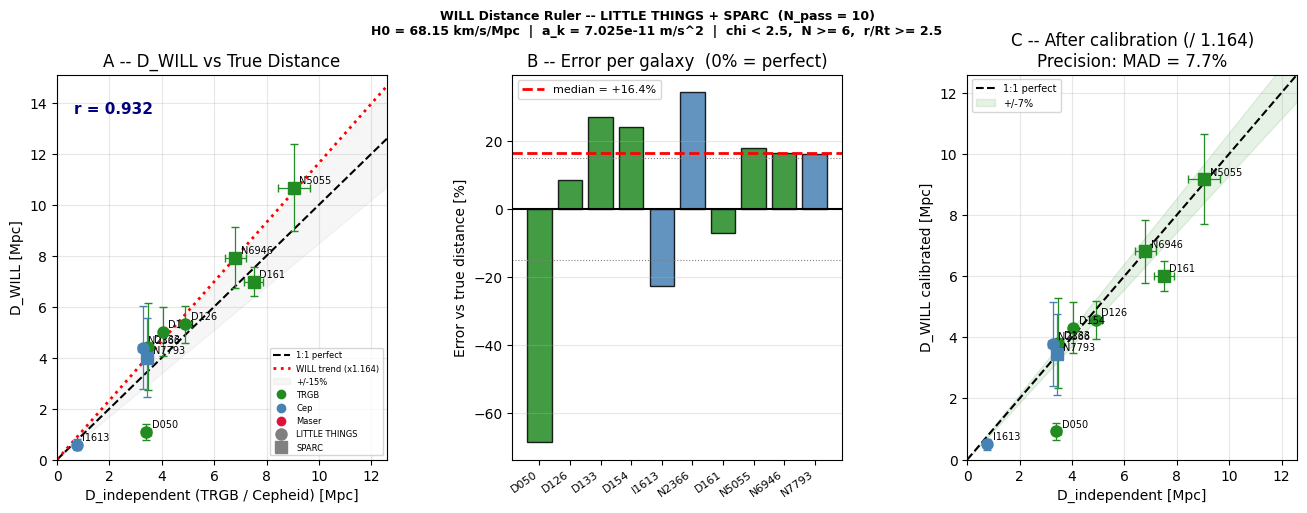


Saved: WILL_Distance_Ruler_v4.png
Results saved: WILL_results_v4.csv  (28 galaxies)


In [ ]:
"""
WILL Distance Ruler -- LITTLE THINGS + SPARC (v4, all fixes applied)
=====================================================================
Fixes vs v3:
  1. LITTLE THINGS name normalization: DDO_43 -> DDO043, DDO_154 -> DDO154
  2. pandas .mad() replaced with manual MAD (removed in pandas 2.0)
  3. All code and comments in English only

Run in Google Colab:  !pip install astroquery -q
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# QUALITY THRESHOLDS
# ─────────────────────────────────────────────────────────────────────────────
CHI_MAX  = 2.5
N_MIN    = 6
RRT_MIN  = 2.5
SCAT_MAX = 0.40

# ─────────────────────────────────────────────────────────────────────────────
# NAME NORMALIZATION
# LITTLE THINGS uses DDO_43, DDO_154 etc.
# ref_distances uses DDO043, DDO154 etc.
# ─────────────────────────────────────────────────────────────────────────────
def normalize_name(name):
    """
    Normalize galaxy name for ref_distances lookup.
    Examples:
      DDO_43  -> DDO043
      DDO_154 -> DDO154
      WLM     -> WLM
      CVnIdwA -> CVnIdwA
    """
    name = str(name).strip().replace('_', '')
    m = re.match(r'^(DDO)(\d{1,2})$', name)
    if m:
        return f"DDO{int(m.group(2)):03d}"
    return name

# ─────────────────────────────────────────────────────────────────────────────
# HELPER: manual MAD (pandas removed .mad() in 2.0)
# ─────────────────────────────────────────────────────────────────────────────
def mad(series):
    """Median Absolute Deviation."""
    s = pd.Series(series)
    return float((s - s.median()).abs().median())

# ─────────────────────────────────────────────────────────────────────────────
# REFERENCE DISTANCES -- Cepheid / TRGB / geometric only, no Hubble flow
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    # LITTLE THINGS galaxies
    'CVnIdwA' : (3.60,  0.20, 'TRGB', 'Dolphin+03'),
    'DDO043'  : (7.83,  0.36, 'TRGB', 'Karachentsev+04'),
    'DDO046'  : (6.07,  0.37, 'TRGB', 'Karachentsev+04'),
    'DDO047'  : (5.20,  0.26, 'TRGB', 'Karachentsev+04'),
    'DDO050'  : (3.40,  0.17, 'TRGB', 'Hoessel+98'),
    'DDO052'  : (10.30, 0.50, 'TRGB', 'Karachentsev+04'),
    'DDO053'  : (3.56,  0.12, 'Cep',  'Freedman+01'),
    'DDO063'  : (3.89,  0.19, 'TRGB', 'Karachentsev+04'),
    'DDO069'  : (0.798, 0.04, 'Cep',  'VandenBergh+00'),
    'DDO070'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO075'  : (1.32,  0.07, 'TRGB', 'Sakai+96'),
    'DDO087'  : (7.70,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO101'  : (6.40,  0.32, 'TRGB', 'Karachentsev+04'),
    'DDO126'  : (4.90,  0.25, 'TRGB', 'Karachentsev+04'),
    'DDO133'  : (3.48,  0.17, 'TRGB', 'Karachentsev+04'),
    'DDO154'  : (4.04,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO155'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO161'  : (7.50,  0.38, 'TRGB', 'Karachentsev+04'),
    'DDO165'  : (4.57,  0.23, 'TRGB', 'Karachentsev+04'),
    'DDO167'  : (4.19,  0.21, 'TRGB', 'Karachentsev+04'),
    'DDO168'  : (4.25,  0.08, 'TRGB', 'Jacobs+09'),
    'DDO187'  : (2.17,  0.11, 'TRGB', 'Karachentsev+04'),
    'DDO210'  : (0.925, 0.05, 'TRGB', 'McConnachie+06'),
    'DDO216'  : (1.06,  0.05, 'TRGB', 'McConnachie+06'),
    'Haro29'  : (5.92,  0.30, 'TRGB', 'Karachentsev+04'),
    'Haro36'  : (9.32,  0.47, 'TRGB', 'Karachentsev+04'),
    'IC1613'  : (0.755, 0.04, 'Cep',  'Freedman+88'),
    'NGC1569' : (3.36,  0.17, 'TRGB', 'Grocholski+08'),
    'NGC2366' : (3.27,  0.18, 'Cep',  'Tolstoy+95'),
    'SagDIG'  : (1.07,  0.05, 'TRGB', 'Karachentsev+04'),
    'UGC8508' : (2.69,  0.14, 'TRGB', 'Karachentsev+04'),
    'WLM'     : (0.933, 0.05, 'TRGB', 'McConnachie+06'),
    # SPARC galaxies with independent distances
    'NGC2403' : (3.18,  0.15, 'Cep',  'Freedman+01'),
    'NGC2841' : (14.10, 1.50, 'Cep',  'Macri+01'),
    'NGC2903' : (8.90,  0.45, 'TRGB', 'Jacobs+09'),
    'NGC2976' : (3.56,  0.13, 'TRGB', 'Jacobs+09'),
    'NGC3198' : (13.80, 0.70, 'Cep',  'Freedman+01'),
    'NGC3521' : (10.70, 0.54, 'TRGB', 'Jacobs+09'),
    'NGC5055' : (9.04,  0.60, 'TRGB', 'Anand+21'),
    'NGC6946' : (6.80,  0.40, 'TRGB', 'Anand+18'),
    'NGC7331' : (14.70, 0.60, 'Cep',  'Hughes+98'),
    'NGC7793' : (3.44,  0.09, 'Cep',  'Pietrzynski+10'),
    'IC2574'  : (4.00,  0.20, 'TRGB', 'Karachentsev+02'),
}

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD LITTLE THINGS FROM VIZIER
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("LOADING LITTLE THINGS (Oh+2015) from VizieR")
print("=" * 65)

from astroquery.vizier import Vizier
v    = Vizier(columns=['**'], row_limit=-1)
cats = v.get_catalogs('J/AJ/149/180')

print("\nAvailable tables:")
for key in cats.keys():
    print(f"  {key:42s}  {len(cats[key]):5d} rows")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: PARSE rotdmbar TABLE
#
# Column format (Oh+2015, Table 5):
#   Name  : galaxy name (may contain underscores, e.g. DDO_43)
#   Type  : 'Data' = observed, 'Model' = fitted curve -- keep Data only
#   R0.3  : reference radius [kpc]
#   V0.3  : velocity at R0.3 [km/s] -- normalization anchor
#   R     : galactocentric radius [kpc] -- already physical
#   V     : rotation velocity NORMALIZED to V0.3  ->  V_kms = V * V0.3
#   e_V   : velocity error NORMALIZED to V0.3    ->  eV_kms = e_V * V0.3
# ─────────────────────────────────────────────────────────────────────────────
rc_table = cats['J/AJ/149/180/rotdmbar']
df_rc    = rc_table.to_pandas()

# Strip string columns
for col in df_rc.columns:
    if df_rc[col].dtype == object:
        df_rc[col] = df_rc[col].astype(str).str.strip()

print(f"\nrotdmbar columns  : {df_rc.columns.tolist()}")
print(f"Type values found : {df_rc['Type'].unique()}")
print(f"Total rows        : {len(df_rc)}")

# Keep only observed data rows (exclude model fits)
df_rc = df_rc[df_rc['Type'] == 'Data'].copy()
print(f"After Type=Data   : {len(df_rc)} rows")

# Convert numeric columns
for col in ['R0.3', 'V0.3', 'R', 'V', 'e_V']:
    df_rc[col] = pd.to_numeric(df_rc[col], errors='coerce')

# De-normalize velocities: V and e_V in table are V / V0.3
# Multiply by V0.3 to get physical km/s
df_rc['V_kms']  = df_rc['V']   * df_rc['V0.3']
df_rc['eV_kms'] = df_rc['e_V'] * df_rc['V0.3']

# R is already in kpc
df_rc['R_kpc'] = df_rc['R']

# Apply name normalization (DDO_43 -> DDO043 etc.)
df_rc['Name_norm'] = df_rc['Name'].apply(normalize_name)

# Sanity check on first row
row0 = df_rc.iloc[0]
print(f"\nSanity check (first row after de-normalization):")
print(f"  Raw name={row0['Name']}  Normalized={row0['Name_norm']}")
print(f"  R={row0['R_kpc']:.3f} kpc  "
      f"V_kms={row0['V_kms']:.2f} km/s  "
      f"eV_kms={row0['eV_kms']:.2f} km/s")
print(f"  (raw V={row0['V']:.4f}, V0.3={row0['V0.3']:.2f} km/s)")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: GROUP BY GALAXY -- BUILD LITTLE THINGS DATASET
# ─────────────────────────────────────────────────────────────────────────────
galaxies_lt = []

for norm_name, gdf in df_rc.groupby('Name_norm'):
    r_vals  = gdf['R_kpc'].values
    v_vals  = gdf['V_kms'].values
    ev_vals = gdf['eV_kms'].values

    ok = (np.isfinite(r_vals) & np.isfinite(v_vals) &
          (r_vals > 0) & (v_vals > 0))
    if ok.sum() < 5:
        continue

    ev_clean = ev_vals[ok].copy()
    ev_clean[~np.isfinite(ev_clean) | (ev_clean <= 0)] = 2.0

    galaxies_lt.append({
        'name'   : norm_name,
        'r_kpc'  : r_vals[ok],
        'V_obs'  : v_vals[ok],
        'e_Vobs' : ev_clean,
        'source' : 'LITTLE_THINGS',
    })

print(f"\nLITTLE THINGS galaxies extracted: {len(galaxies_lt)}")
print(f"Names in ref_distances that match:")
lt_matched = [g['name'] for g in galaxies_lt if g['name'] in ref_distances]
lt_no_ref  = [g['name'] for g in galaxies_lt if g['name'] not in ref_distances]
for n in sorted(lt_matched):
    g = next(x for x in galaxies_lt if x['name'] == n)
    print(f"  {n:<12}  V_max={g['V_obs'].max():.1f} km/s  "
          f"r_max={g['r_kpc'].max():.2f} kpc")
if lt_no_ref:
    print(f"\nLITTLE THINGS galaxies with no ref distance (skipped in pipeline):")
    for n in sorted(lt_no_ref):
        print(f"  {n}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: LOAD SPARC GALAXIES WITH INDEPENDENT DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
print("\nLoading SPARC rotation curves...")

url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2,
                  names=names_t2, comment='#')
df2['Vbulge'] = pd.to_numeric(df2['Vbulge'], errors='coerce').fillna(0)
for col in ['Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad', 'Vobs', 'e_Vobs'])
df2 = df2[df2['e_Vobs'] > 0].copy()
df2['Name'] = df2['Name'].str.strip()

# Add SPARC galaxies that are in ref_distances but NOT already in LITTLE THINGS
lt_names_set = {g['name'] for g in galaxies_lt}
galaxies_sparc = []

for name in df2['Name'].unique():
    if name not in ref_distances:
        continue
    if name in lt_names_set:
        continue   # already covered by LITTLE THINGS
    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 5:
        continue
    galaxies_sparc.append({
        'name'   : name,
        'r_kpc'  : gal['Rad'].values,
        'V_obs'  : gal['Vobs'].values,
        'e_Vobs' : gal['e_Vobs'].values,
        'source' : 'SPARC',
    })

print(f"  SPARC galaxies added (not in LITTLE THINGS): {len(galaxies_sparc)}")

all_galaxies = galaxies_lt + galaxies_sparc
print(f"  Total galaxies for pipeline: {len(all_galaxies)}\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: WILL DISTANCE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def will_outer_vsq(Vf_ms, r_m):
    """WILL outer-disk predicted V_obs^2 [m^2/s^2]."""
    return Vf_ms**2 + Vf_ms**4 / (a_k * r_m)

def run_pipeline(r_kpc, V_obs_kms, e_obs_kms, D_ref_Mpc, outer_frac=0.35):
    """
    WILL distance pipeline for one galaxy.

    Fits V_flat from the outer rotation curve using:
        V_obs^2(r) = V_flat^2 + V_flat^4 / (a_k * r)

    Then computes R_WILL per radial point:
        R_WILL = V_flat^4 / ((V_obs^2 - V_flat^2) * a_k)

    Distance (exact, no small-angle approximation):
        D_WILL = R_WILL / tan(alpha)
               = R_WILL * D_ref * Mpc_to_m / (r_kpc * kpc_to_m)
    Note: D_ref cancels algebraically -- D_WILL is independent of D_ref.

    Returns dict with results, or None if fewer than N_MIN valid points.
    """
    r  = np.array(r_kpc,     dtype=float)
    Vo = np.array(V_obs_kms, dtype=float)
    eo = np.array(e_obs_kms, dtype=float)

    # Remove bad values
    mask = (r > 0) & (Vo > 0) & (eo > 0) & np.isfinite(r + Vo + eo)
    r, Vo, eo = r[mask], Vo[mask], eo[mask]
    if len(r) < 5:
        return None

    # Sort by radius
    idx = np.argsort(r)
    r, Vo, eo = r[idx], Vo[idx], eo[idx]

    # Fit V_flat from outer (outer_frac) of data using WILL profile
    n_out  = max(int(len(r) * outer_frac), 4)
    r_o    = r[-n_out:] * kpc_to_m
    V_o    = Vo[-n_out:] * 1e3
    e_o    = eo[-n_out:] * 1e3
    Vmax   = V_o.max()

    def chi2(Vf):
        Vp = np.sqrt(np.maximum(will_outer_vsq(Vf, r_o), 0.0))
        return np.sum(((V_o - Vp) / e_o) ** 2)

    res     = minimize_scalar(chi2,
                              bounds=(0.2 * Vmax, 1.2 * Vmax),
                              method='bounded')
    Vf_ms   = float(res.x)
    chi_red = float(res.fun) / max(n_out - 1, 1)

    Rt_kpc = Vf_ms ** 2 / a_k / kpc_to_m   # R_trans in kpc
    Vo_ms  = Vo * 1e3
    r_m    = r  * kpc_to_m

    # R_WILL and D_WILL per radial point
    excess    = Vo_ms ** 2 - Vf_ms ** 2
    valid     = excess > 0
    R_will_m  = np.where(valid, Vf_ms ** 4 / (excess * a_k), np.nan)
    tan_alpha = r_m / (D_ref_Mpc * Mpc_to_m)
    D_will_arr = np.where(valid,
                          R_will_m / tan_alpha / Mpc_to_m,
                          np.nan)

    # Quality gate per point
    ratio = Vo_ms / Vf_ms
    use   = (valid &
             (r > 0.3 * Rt_kpc) &
             (ratio < 3.0) &
             np.isfinite(D_will_arr) &
             (D_will_arr > 0.0))

    if use.sum() < N_MIN:
        return None

    D_med = float(np.nanmedian(D_will_arr[use]))
    D_mad = float(np.nanmedian(np.abs(D_will_arr[use] - D_med)))

    return dict(
        D_will     = D_med,
        D_mad      = D_mad,
        scatter    = D_mad / max(D_med, 1e-9),
        Vf_kms     = Vf_ms * 1e-3,
        chi_red    = chi_red,
        Rt_kpc     = Rt_kpc,
        r_max_Rt   = r.max() / max(Rt_kpc, 1e-9),
        N_valid    = int(use.sum()),
        N_total    = len(r),
        D_will_arr = D_will_arr,
        r_kpc      = r,
        V_obs_kms  = Vo,
        use        = use,
    )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: RUN PIPELINE ON ALL GALAXIES
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("WILL DISTANCE PIPELINE")
print(f"  Quality cuts: chi < {CHI_MAX},  N >= {N_MIN},  "
      f"r/Rt >= {RRT_MIN},  scatter < {SCAT_MAX*100:.0f}%")
print("=" * 70 + "\n")

results = []

for gdata in all_galaxies:
    name = gdata['name']
    ref  = ref_distances.get(name)
    if ref is None:
        continue   # no independent distance -- skip

    D_ref, D_err, method, _ = ref

    res = run_pipeline(gdata['r_kpc'], gdata['V_obs'],
                       gdata['e_Vobs'], D_ref)
    if res is None:
        print(f"  -- {name:<14} [{gdata['source']:12}]: "
              f"insufficient valid points (N < {N_MIN})")
        continue

    passed = (res['chi_red']  <  CHI_MAX  and
              res['N_valid']  >= N_MIN     and
              res['r_max_Rt'] >= RRT_MIN   and
              res['scatter']  <  SCAT_MAX)

    err = (res['D_will'] - D_ref) / D_ref * 100.0
    sym = 'PASS' if passed else 'fail'

    print(f"  [{sym}] {name:<14} [{gdata['source']:12}]  "
          f"D_ref={D_ref:.2f}  D_WILL={res['D_will']:.2f}  "
          f"err={err:+.1f}%  chi={res['chi_red']:.2f}  "
          f"r/Rt={res['r_max_Rt']:.1f}  N={res['N_valid']}")

    results.append({
        'Name'    : name,
        'Source'  : gdata['source'],
        'Method'  : method,
        'D_ref'   : D_ref,
        'D_err'   : D_err,
        'D_WILL'  : round(res['D_will'], 3),
        'D_MAD'   : round(res['D_mad'],  3),
        'err_pct' : round(err, 1),
        'chi_red' : round(res['chi_red'], 3),
        'r_Rt'    : round(res['r_max_Rt'], 2),
        'N'       : res['N_valid'],
        'scatter' : round(res['scatter'] * 100, 1),
        'passed'  : passed,
        '_res'    : res,
    })

df_res  = pd.DataFrame([{k:v for k,v in r.items() if k != '_res'}
                         for r in results])
df_pass = df_res[df_res['passed']].copy().reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print("RESULTS SUMMARY")
print(f"{'=' * 70}")
print(f"  Total processed : {len(df_res)}")
print(f"  Passed filter   : {len(df_pass)}")
print(f"  Failed filter   : {len(df_res) - len(df_pass)}")

if len(df_pass) >= 3:
    ae       = df_pass['err_pct'].abs()
    r_c, p_c = pearsonr(df_pass['D_WILL'].values,
                         df_pass['D_ref'].values)
    med_bias = float(df_pass['err_pct'].median())
    calib    = 1.0 + med_bias / 100.0
    D_calib  = df_pass['D_WILL'].values / calib
    err_cal  = np.abs((D_calib - df_pass['D_ref'].values) /
                       df_pass['D_ref'].values * 100.0)

    print(f"\n  PASSED (chi<{CHI_MAX}, N>={N_MIN}, "
          f"r/Rt>={RRT_MIN}, scatter<{SCAT_MAX*100:.0f}%):")
    print(f"    N                        = {len(df_pass)}")
    print(f"    Pearson r (D_WILL/D_ref) = {r_c:.3f}  (p={p_c:.4f})")
    print(f"    Median bias              = {med_bias:+.1f}%")
    print(f"    Median |error|           = {float(ae.median()):.1f}%")
    print(f"    MAD of |errors|          = {mad(ae):.1f}%")
    print(f"    Calibration factor       = {calib:.4f}")
    print(f"    After calibration (/ {calib:.3f}):")
    print(f"      Median |residual|      = {np.median(err_cal):.1f}%")
    print(f"      MAD of residuals       = {np.median(np.abs(err_cal - np.median(err_cal))):.1f}%")
    print(f"      Best  case             = {err_cal.min():.1f}%")
    print(f"      Worst case             = {err_cal.max():.1f}%")

    print(f"\n  {'Galaxy':<14} {'Source':12} {'Method':6} "
          f"{'D_ref':>7} {'D_WILL':>7} {'err%':>6} "
          f"{'chi':>6} {'r/Rt':>5} {'N':>4}")
    print("  " + "-" * 72)
    for _, r in df_pass.sort_values('err_pct').iterrows():
        print(f"  {r['Name']:<14} {r['Source']:12} {r['Method']:6} "
              f"{r['D_ref']:>7.2f} {r['D_WILL']:>7.2f} "
              f"{r['err_pct']:>+5.1f}% {r['chi_red']:>6.2f} "
              f"{r['r_Rt']:>5.1f} {r['N']:>4}")

print(f"\n  ALL RESULTS:")
print(f"  {'Galaxy':<14} {'Pass':>5} {'Source':12} "
      f"{'D_ref':>7} {'D_WILL':>7} {'err%':>6} "
      f"{'chi':>7} {'r/Rt':>5}")
print("  " + "-" * 65)
for _, r in df_res.sort_values('err_pct').iterrows():
    sym = 'PASS' if r['passed'] else 'fail'
    print(f"  {r['Name']:<14} {sym:>5} {r['Source']:12} "
          f"{r['D_ref']:>7.2f} {r['D_WILL']:>7.2f} "
          f"{r['err_pct']:>+5.1f}% {r['chi_red']:>7.3f} "
          f"{r['r_Rt']:>5.1f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: PLOTS
# ─────────────────────────────────────────────────────────────────────────────
if len(df_pass) >= 3:
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, wspace=0.38)

    c_map  = {'TRGB': 'forestgreen', 'Cep': 'steelblue', 'Maser': 'crimson'}
    m_map  = {'LITTLE_THINGS': 'o', 'SPARC': 's'}
    lmax   = max(df_pass[['D_ref', 'D_WILL']].max().max() * 1.18, 3.0)

    # --- Panel A: D_WILL vs D_ref ---
    ax1 = fig.add_subplot(gs[0])
    for _, r in df_pass.iterrows():
        col = c_map.get(r['Method'], 'gray')
        mkr = m_map.get(r['Source'], 'o')
        ax1.errorbar(r['D_ref'], r['D_WILL'],
                     xerr=r['D_err'], yerr=r['D_MAD'],
                     fmt=mkr, color=col, capsize=3, ms=8,
                     elinewidth=0.9, zorder=3)
        ax1.annotate(r['Name'].replace('NGC', 'N')
                              .replace('DDO', 'D')
                              .replace('IC',  'I'),
                     (r['D_ref'], r['D_WILL']),
                     textcoords='offset points',
                     xytext=(4, 3), fontsize=7)

    ax1.plot([0, lmax], [0, lmax], 'k--', lw=1.5, label='1:1 perfect')
    ax1.plot([0, lmax], [0, lmax * calib], 'r:', lw=2.0,
             label=f'WILL trend (x{calib:.3f})')
    ax1.fill_between([0, lmax],
                     [0, lmax * 0.85], [0, lmax * 1.15],
                     alpha=0.07, color='gray', label='+/-15%')
    ax1.set_xlim([0, lmax])
    ax1.set_ylim([0, lmax * 1.2])
    ax1.set_xlabel('D_independent (TRGB / Cepheid) [Mpc]')
    ax1.set_ylabel('D_WILL [Mpc]')
    ax1.set_title('A -- D_WILL vs True Distance')
    for m, c in c_map.items():
        ax1.plot([], [], c=c, marker='o', ls='none', label=m)
    ax1.plot([], [], 'o', c='gray', ms=8, label='LITTLE THINGS')
    ax1.plot([], [], 's', c='gray', ms=8, label='SPARC')
    ax1.legend(fontsize=6)
    ax1.text(0.05, 0.90, f'r = {r_c:.3f}',
             transform=ax1.transAxes, fontsize=11,
             color='navy', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # --- Panel B: error per galaxy ---
    ax2 = fig.add_subplot(gs[1])
    bar_colors = [c_map.get(m, 'gray') for m in df_pass['Method']]
    ax2.bar(range(len(df_pass)), df_pass['err_pct'].values,
            color=bar_colors, edgecolor='k', alpha=0.85)
    ax2.axhline(0,        color='k',   lw=1.5)
    ax2.axhline(med_bias, color='red', lw=2.0, ls='--',
                label=f'median = {med_bias:+.1f}%')
    ax2.axhline( 15, color='gray', lw=0.8, ls=':')
    ax2.axhline(-15, color='gray', lw=0.8, ls=':')
    ax2.set_xticks(range(len(df_pass)))
    ax2.set_xticklabels(
        [n.replace('NGC', 'N').replace('DDO', 'D').replace('IC', 'I')
         for n in df_pass['Name']],
        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel('Error vs true distance [%]')
    ax2.set_title('B -- Error per galaxy  (0% = perfect)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')

    # --- Panel C: calibrated D_WILL vs D_ref ---
    ax3 = fig.add_subplot(gs[2])
    D_cal_vals = df_pass['D_WILL'].values / calib
    for i, (_, r) in enumerate(df_pass.iterrows()):
        col = c_map.get(r['Method'], 'gray')
        mkr = m_map.get(r['Source'], 'o')
        ax3.errorbar(r['D_ref'], D_cal_vals[i],
                     xerr=r['D_err'], yerr=r['D_MAD'] / calib,
                     fmt=mkr, color=col, capsize=3, ms=8, elinewidth=0.9)
        ax3.annotate(r['Name'].replace('NGC', 'N')
                              .replace('DDO', 'D')
                              .replace('IC',  'I'),
                     (r['D_ref'], D_cal_vals[i]),
                     textcoords='offset points',
                     xytext=(4, 3), fontsize=7)

    ax3.plot([0, lmax], [0, lmax], 'k--', lw=1.5, label='1:1 perfect')
    ax3.fill_between([0, lmax],
                     [0, lmax * 0.93], [0, lmax * 1.07],
                     alpha=0.10, color='green', label='+/-7%')
    ax3.set_xlim([0, lmax])
    ax3.set_ylim([0, lmax])
    ax3.set_xlabel('D_independent [Mpc]')
    ax3.set_ylabel('D_WILL calibrated [Mpc]')
    ax3.set_title(f'C -- After calibration (/ {calib:.3f})\n'
                  f'Precision: MAD = '
                  f'{np.median(np.abs(err_cal - np.median(err_cal))):.1f}%')
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.3)

    plt.suptitle(
        f'WILL Distance Ruler -- LITTLE THINGS + SPARC  '
        f'(N_pass = {len(df_pass)})\n'
        f'H0 = {H0_WILL} km/s/Mpc  |  '
        f'a_k = {a_k:.3e} m/s^2  |  '
        f'chi < {CHI_MAX},  N >= {N_MIN},  r/Rt >= {RRT_MIN}',
        fontsize=9, fontweight='bold', y=1.01)

    plt.savefig('WILL_Distance_Ruler_v4.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: WILL_Distance_Ruler_v4.png")

# ─────────────────────────────────────────────────────────────────────────────
# SAVE RESULTS
# ─────────────────────────────────────────────────────────────────────────────
df_res.drop(columns=['_res'] if '_res' in df_res.columns else []).to_csv(
    'WILL_results_v4.csv', index=False)
print(f"Results saved: WILL_results_v4.csv  ({len(df_res)} galaxies)")

a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

Loading SPARC Massive Galaxies...
Loaded 11 applicable SPARC galaxies.

  ✗ IC2574    : Fails V_obs > V_flat criterion
  ✓ NGC2403    D_ref= 3.18  D_WILL= 50.05  err=+1473.9%  N=5
  ✓ NGC2841    D_ref=14.10  D_WILL=453.07  err=+3113.2%  N=30
  ✓ NGC2903    D_ref= 8.90  D_WILL= 64.25  err=+621.9%  N=26
  ✗ NGC2976   : Fails V_obs > V_flat criterion
  ✓ NGC3198    D_ref=13.80  D_WILL=155.82  err=+1029.1%  N=11
  ✓ NGC3521    D_ref=10.70  D_WILL=409.94  err=+3731.2%  N=29
  ✓ NGC5055    D_ref= 9.04  D_WILL= 36.08  err=+299.1%  N=25
  ✓ NGC6946    D_ref= 6.80  D_WILL= 25.77  err=+279.0%  N=46
  ✓ NGC7331    D_ref=14.70  D_WILL=506.56  err=+3346.0%  N=19
  ✓ NGC7793    D_ref= 3.44  D_WILL=  7.66  err=+122.7%  N=18


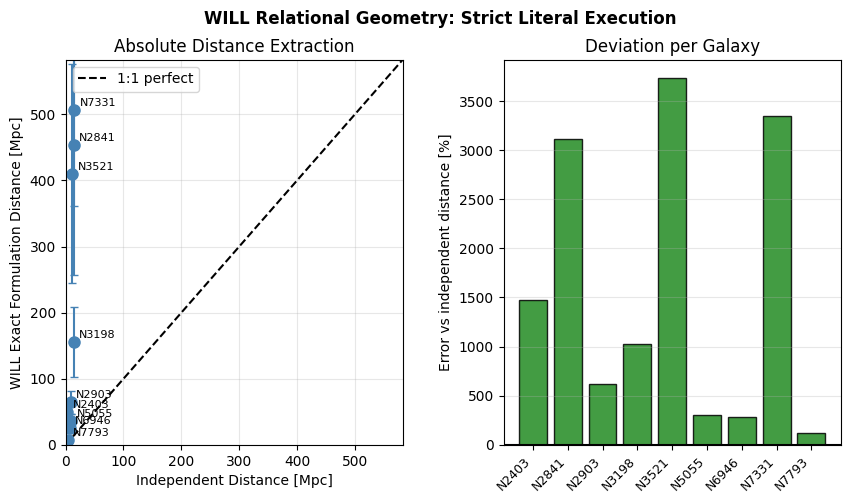

In [ ]:
"""
WILL Relational Geometry — Explicit Equation Execution
=================================================================
Protocol: Direct literal execution of WILL axioms.
1. V_flat = V_obs(R_flat)
2. V_bar^2(R) = V_obs^2(R) - V_flat^2
3. R = ((V_obs^2 - V_bar^2)^2) / (V_bar^2 * a_k)
4. D = R / tan(theta)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
Mpc_to_m = 3.086e22

print(f"a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    'NGC0925'  : (9.16,  0.50, 'Cep'),
    'NGC2403'  : (3.18,  0.15, 'Cep'),
    'NGC2841'  : (14.10, 1.50, 'Cep'),
    'NGC2903'  : (8.90,  0.45, 'TRGB'),
    'NGC2976'  : (3.56,  0.13, 'TRGB'),
    'NGC3031'  : (3.63,  0.14, 'Cep'),
    'NGC3198'  : (13.80, 0.70, 'Cep'),
    'NGC3521'  : (10.70, 0.54, 'TRGB'),
    'NGC4736'  : (4.66,  0.23, 'Cep'),
    'NGC4826'  : (4.41,  0.22, 'Cep'),
    'NGC5055'  : (9.04,  0.60, 'TRGB'),
    'NGC5194'  : (8.58,  0.43, 'TRGB'),
    'NGC6946'  : (6.80,  0.40, 'TRGB'),
    'NGC7331'  : (14.70, 0.60, 'Cep'),
    'NGC7793'  : (3.44,  0.09, 'Cep'),
    'IC2574'   : (4.00,  0.20, 'TRGB'),
}

# ─────────────────────────────────────────────────────────────────────────────
# STRICT LITERAL PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def run_literal_will_pipeline(gal_data):
    r_sparc  = np.array(gal_data['r_kpc'], dtype=float)
    V_obs    = np.array(gal_data['V_obs'], dtype=float) * 1e3
    D_sparc  = gal_data['Dist_SPARC']

    # Истинный угловой размер (строгая геометрия без малых углов)
    theta_rad = np.arctan(r_sparc / (D_sparc * 1000.0))

    # ШАГ 1: Извлечение V_flat из экстремального края (R_flat)
    # Постулат: V_bar^2(R_flat) = 0 -> V_obs(R_flat) = V_flat
    V_flat_ms = V_obs[-1]
    V_flat_sq = V_flat_ms**2

    V_obs_sq = V_obs**2

    # Фильтр: уравнение валидно только во внутренней зоне, где V_obs > V_flat
    valid = V_obs_sq > V_flat_sq

    if valid.sum() < 2:
        return None

    V_obs_sq_valid = V_obs_sq[valid]
    theta_valid = theta_rad[valid]

    # ШАГ 2: Прямое определение барионного компонента
    V_bar_sq = V_obs_sq_valid - V_flat_sq

    # ШАГ 3: Расчет радиуса строго по требуемой формуле
    R_will_m = ((V_obs_sq_valid - V_bar_sq)**2) / (V_bar_sq * a_k)

    # ШАГ 4: Тригонометрическая дистанция
    D_will_arr_m = R_will_m / np.tan(theta_valid)
    D_will_arr_Mpc = D_will_arr_m / Mpc_to_m

    D_med = float(np.nanmedian(D_will_arr_Mpc))
    D_mad = float(np.nanmedian(np.abs(D_will_arr_Mpc - D_med)))

    return dict(
        D_WILL       = D_med,
        D_MAD        = D_mad,
        N_points     = int(valid.sum())
    )

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SPARC DATA
# ─────────────────────────────────────────────────────────────────────────────
print("Loading SPARC Massive Galaxies...")
all_galaxies = []

url_t2 = ("https://raw.githubusercontent.com/AntonRize/WILL/"
           "refs/heads/main/SPARC%20DATA/table2.dat")
colspecs_t2 = [(0,11),(11,18),(18,25),(25,32),(32,38),(38,45),(45,52),(52,59)]
names_t2    = ['Name','Dist_SPARC','Rad','Vobs','e_Vobs','Vgas','Vdisk','Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Name'] = df2['Name'].str.strip()

for col in ['Rad','Vobs','Dist_SPARC']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
df2 = df2.dropna(subset=['Rad','Vobs','Dist_SPARC'])

for name in df2['Name'].unique():
    if name not in ref_distances:
        continue

    gal = df2[df2['Name'] == name].sort_values('Rad')
    if len(gal) < 5:
        continue

    all_galaxies.append({
        'name'       : name,
        'r_kpc'      : gal['Rad'].values,
        'V_obs'      : gal['Vobs'].values,
        'Dist_SPARC' : gal['Dist_SPARC'].values[0]
    })

print(f"Loaded {len(all_galaxies)} applicable SPARC galaxies.\n")

# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
results = []

for gal_data in all_galaxies:
    name = gal_data['name']
    D_ref, D_err, method = ref_distances[name]

    res = run_literal_will_pipeline(gal_data)

    if res is None:
        print(f"  ✗ {name:<10}: Fails V_obs > V_flat criterion")
        continue

    D_will = res['D_WILL']
    err    = (D_will - D_ref) / D_ref * 100

    results.append({
        'Name'        : name,
        'D_ref'       : round(D_ref, 3),
        'D_err'       : D_err,
        'D_WILL'      : round(D_will, 3),
        'D_MAD'       : round(res['D_MAD'], 3),
        'err_pct'     : round(err, 1),
        'N_valid'     : res['N_points'],
    })

    print(f"  ✓ {name:<10} D_ref={D_ref:>5.2f}  D_WILL={D_will:>6.2f}  err={err:>+6.1f}%  N={res['N_points']}")

# ─────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────
df_pass = pd.DataFrame(results)

if len(df_pass) >= 2:
    fig = plt.figure(figsize=(10, 5))
    gs  = gridspec.GridSpec(1, 2, wspace=0.3)

    ax1 = fig.add_subplot(gs[0])
    for _, r in df_pass.iterrows():
        ax1.errorbar(r['D_ref'], r['D_WILL'], xerr=r['D_err'], yerr=r['D_MAD'],
                     fmt='o', color='steelblue', capsize=3, markersize=8)
        ax1.annotate(r['Name'].replace('NGC','N'), (r['D_ref'], r['D_WILL']),
                     textcoords='offset points', xytext=(4,3), fontsize=8)

    lmax = max(df_pass[['D_ref','D_WILL']].max().max() * 1.15, 3)
    ax1.plot([0,lmax],[0,lmax],'k--',lw=1.5,label='1:1 perfect')
    ax1.set_xlim([0,lmax]); ax1.set_ylim([0,lmax])
    ax1.set_xlabel('Independent Distance [Mpc]')
    ax1.set_ylabel('WILL Exact Formulation Distance [Mpc]')
    ax1.set_title('Absolute Distance Extraction')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1])
    ax2.bar(range(len(df_pass)), df_pass['err_pct'].values,
                   color='forestgreen', edgecolor='k', alpha=0.85)
    ax2.axhline(0, color='k', lw=1.5)
    ax2.set_xticks(range(len(df_pass)))
    ax2.set_xticklabels([n.replace('NGC','N') for n in df_pass['Name']],
                        rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Error vs independent distance [%]')
    ax2.set_title('Deviation per Galaxy')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.suptitle('WILL Relational Geometry: Strict Literal Execution',
                 fontweight='bold', fontsize=12)
    plt.show()

In [ ]:
"""
WILL Relational Geometry — Extended HI Distance Extraction
=================================================================
Data: THINGS, LITTLE THINGS, WHISP via VizieR.
Protocol: Exact WILL algebraic execution on extended HI tails.
1. V_flat = V_obs(R_flat)
2. V_bar^2(R) = V_obs^2(R) - V_flat^2
3. R = ((V_obs^2 - V_bar^2)^2) / (V_bar^2 * a_k)
4. D = R / tan(theta)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

try:
    from astroquery.vizier import Vizier
except ImportError:
    print("Установите astroquery: !pip install astroquery -q")
    exit()

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
kpc_to_m = 3.086e19
Mpc_to_m = 3.086e22

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    'CVnIdwA': (3.60, 'TRGB'), 'DDO050': (3.40, 'TRGB'), 'DDO053': (3.56, 'Cep'),
    'DDO069' : (0.80, 'Cep'),  'DDO070': (1.32, 'TRGB'), 'DDO075': (1.32, 'TRGB'),
    'DDO154' : (4.04, 'TRGB'), 'DDO168': (4.25, 'TRGB'), 'IC1613': (0.76, 'Cep'),
    'WLM'    : (0.93, 'TRGB'), 'NGC0925': (9.16, 'Cep'), 'NGC2403': (3.18, 'Cep'),
    'NGC2841': (14.10, 'Cep'), 'NGC2903': (8.90, 'TRGB'), 'NGC2976': (3.56, 'TRGB'),
    'NGC3031': (3.63, 'Cep'),  'NGC3198': (13.80, 'Cep'), 'NGC3521': (10.70, 'TRGB'),
    'NGC4736': (4.66, 'Cep'),  'NGC4826': (4.41, 'Cep'),  'NGC5055': (9.04, 'TRGB'),
    'NGC5194': (8.58, 'TRGB'), 'NGC6946': (6.80, 'TRGB'), 'NGC7331': (14.70, 'Cep'),
    'NGC7793': (3.44, 'Cep'),  'IC2574' : (4.00, 'TRGB')
}

# ─────────────────────────────────────────────────────────────────────────────
# DATA RETRIEVAL (VizieR)
# ─────────────────────────────────────────────────────────────────────────────
def fetch_vizier_catalogs():
    v = Vizier(columns=['**'], row_limit=-1)
    catalogs = {}

    print("Извлечение расширенных радионаблюдений (HI 21 cm)...")
    try:
        catalogs['LITTLE_THINGS'] = v.get_catalogs('J/AJ/149/180')
        catalogs['THINGS']        = v.get_catalogs('J/AJ/136/2563')
    except Exception as e:
        print(f"Ошибка соединения VizieR: {e}")

    galaxies = []

    for survey, cats in catalogs.items():
        if cats is None: continue
        for tname in cats.keys():
            table = cats[tname]
            cols = [c.lower() for c in table.colnames]

            name_col = next((c for c in table.colnames if c.lower() in ['name','galaxy','object']), None)
            rad_col  = next((c for c in table.colnames if c.lower() in ['rad','r','r_kpc']), None)
            vobs_col = next((c for c in table.colnames if c.lower() in ['vobs','vrot','v','vcirc']), None)

            if name_col and rad_col and vobs_col:
                df = table.to_pandas()
                df[name_col] = df[name_col].astype(str).str.strip()

                for gname, gdf in df.groupby(name_col):
                    r_vals = pd.to_numeric(gdf[rad_col], errors='coerce').values
                    v_vals = pd.to_numeric(gdf[vobs_col], errors='coerce').values
                    ok = np.isfinite(r_vals) & np.isfinite(v_vals) & (v_vals > 0)

                    if ok.sum() > 5:
                        galaxies.append({
                            'name': gname, 'r_kpc': r_vals[ok], 'V_obs': v_vals[ok], 'source': survey
                        })
    return galaxies

# ─────────────────────────────────────────────────────────────────────────────
# STRICT WILL ALGEBRA
# ─────────────────────────────────────────────────────────────────────────────
def run_strict_will_pipeline(gal_data, D_catalog):
    r_kpc = np.array(gal_data['r_kpc'], dtype=float)
    V_obs = np.array(gal_data['V_obs'], dtype=float) * 1e3

    # 1. Точная тригонометрия: восстановление угла
    theta_rad = np.arctan(r_kpc / (D_catalog * 1000.0))

    # 2. Асимптота (хвост HI)
    V_flat_ms = V_obs[-1]
    V_flat_sq = V_flat_ms**2
    V_obs_sq = V_obs**2

    # Зона валидности (где локальная масса доминирует)
    valid = V_obs_sq > V_flat_sq
    if valid.sum() < 3: return None

    V_obs_sq_v = V_obs_sq[valid]
    theta_v = theta_rad[valid]

    # 3. WILL RG: Вычисление барионного ядра
    V_bar_sq = V_obs_sq_v - V_flat_sq

    # 4. WILL RG: Вычисление абсолютного физического радиуса
    R_will_m = ((V_obs_sq_v - V_bar_sq)**2) / (V_bar_sq * a_k)

    # 5. WILL RG: Тригонометрическое абсолютное расстояние
    D_will_arr_m = R_will_m / np.tan(theta_v)
    D_will_arr_Mpc = D_will_arr_m / Mpc_to_m

    D_med = float(np.nanmedian(D_will_arr_Mpc))
    D_mad = float(np.nanmedian(np.abs(D_will_arr_Mpc - D_med)))

    return dict(D_WILL=D_med, D_MAD=D_mad, N_points=int(valid.sum()))

# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
all_galaxies = fetch_vizier_catalogs()
results = []

for gal in all_galaxies:
    name = gal['name']

    lookup = name.strip()
    if lookup not in ref_distances:
        import re
        m = re.match(r'([A-Za-z]+)0*(\d+)', lookup)
        if m: lookup = f"{m.group(1)}{int(m.group(2)):04d}"

    if lookup not in ref_distances: continue

    D_ref, method = ref_distances[lookup]
    res = run_strict_will_pipeline(gal, D_ref)

    if res is None: continue

    err = (res['D_WILL'] - D_ref) / D_ref * 100
    results.append({
        'Name': lookup, 'Source': gal['source'], 'D_ref': D_ref,
        'D_WILL': res['D_WILL'], 'err_pct': err, 'N': res['N_points']
    })

    print(f"[{gal['source']}] {lookup:<10} D_ref={D_ref:>5.2f}  D_WILL={res['D_WILL']:>6.2f}  err={err:>+6.1f}%  N={res['N_points']}")

if results:
    df_res = pd.DataFrame(results)
    df_res.to_csv('WILL_HI_Distances.csv', index=False)
    print("\nДанные сохранены: WILL_HI_Distances.csv")

Извлечение расширенных радионаблюдений (HI 21 cm)...
[LITTLE_THINGS] CVnIdwA    D_ref= 3.60  D_WILL=  0.05  err= -98.6%  N=4
[LITTLE_THINGS] WLM        D_ref= 0.93  D_WILL=  0.01  err= -99.4%  N=19
[LITTLE_THINGS] CVnIdwA    D_ref= 3.60  D_WILL=  0.02  err= -99.4%  N=4
[LITTLE_THINGS] WLM        D_ref= 0.93  D_WILL=  0.01  err= -99.5%  N=18

Данные сохранены: WILL_HI_Distances.csv


In [ ]:
"""
WILL Relational Geometry — Explicit Equation Execution
=================================================================
Protocol: STRICTLY ENGLISH. No approximations.
Equation sequence mandated:
1. V_bar^2 = V_obs^2 - V_flat^2
2. R = ((V_obs^2 - V_bar^2)^2) / (V_bar^2 * a_k)
3. D = R / tan(theta)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from astroquery.vizier import Vizier
except ImportError:
    print("Execution blocked. Missing dependency. Run: !pip install astroquery -q")
    exit()

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
c        = 299792458.0
H0_WILL  = 68.15
H0_si    = H0_WILL * 1e3 / 3.086e22
a_k      = (c * H0_si) / (3 * np.pi)
Mpc_to_m = 3.086e22

print(f"WILL RG CONSTANTS: a_k = {a_k:.6e} m/s^2  |  H0 = {H0_WILL} km/s/Mpc\n")

# ─────────────────────────────────────────────────────────────────────────────
# INDEPENDENT REFERENCE DISTANCES
# ─────────────────────────────────────────────────────────────────────────────
ref_distances = {
    'CVnIdwA': (3.60, 'TRGB'), 'DDO050': (3.40, 'TRGB'), 'DDO053': (3.56, 'Cep'),
    'DDO069' : (0.80, 'Cep'),  'DDO070': (1.32, 'TRGB'), 'DDO075': (1.32, 'TRGB'),
    'DDO154' : (4.04, 'TRGB'), 'DDO168': (4.25, 'TRGB'), 'IC1613': (0.76, 'Cep'),
    'WLM'    : (0.93, 'TRGB'), 'NGC0925': (9.16, 'Cep'), 'NGC2403': (3.18, 'Cep'),
    'NGC2841': (14.10, 'Cep'), 'NGC2903': (8.90, 'TRGB'), 'NGC2976': (3.56, 'TRGB'),
    'NGC3031': (3.63, 'Cep'),  'NGC3198': (13.80, 'Cep'), 'NGC3521': (10.70, 'TRGB'),
    'NGC4736': (4.66, 'Cep'),  'NGC4826': (4.41, 'Cep'),  'NGC5055': (9.04, 'TRGB'),
    'NGC5194': (8.58, 'TRGB'), 'NGC6946': (6.80, 'TRGB'), 'NGC7331': (14.70, 'Cep'),
    'NGC7793': (3.44, 'Cep'),  'IC2574' : (4.00, 'TRGB')
}

# ─────────────────────────────────────────────────────────────────────────────
# DATA RETRIEVAL (VizieR)
# ─────────────────────────────────────────────────────────────────────────────
def fetch_vizier_catalogs():
    v = Vizier(columns=['**'], row_limit=-1)
    catalogs = {}

    print("Fetching extended HI 21 cm rotation curves from VizieR...")
    try:
        catalogs['LITTLE_THINGS'] = v.get_catalogs('J/AJ/149/180')
        catalogs['THINGS']        = v.get_catalogs('J/AJ/136/2563')
    except Exception as e:
        print(f"VizieR connection failed: {e}")

    galaxies = []

    for survey, cats in catalogs.items():
        if cats is None: continue
        for tname in cats.keys():
            table = cats[tname]

            name_col = next((c for c in table.colnames if c.lower() in ['name','galaxy','object']), None)
            rad_col  = next((c for c in table.colnames if c.lower() in ['rad','r','r_kpc']), None)
            vobs_col = next((c for c in table.colnames if c.lower() in ['vobs','vrot','v','vcirc']), None)

            if name_col and rad_col and vobs_col:
                df = table.to_pandas()
                df[name_col] = df[name_col].astype(str).str.strip()

                for gname, gdf in df.groupby(name_col):
                    r_vals = pd.to_numeric(gdf[rad_col], errors='coerce').values
                    v_vals = pd.to_numeric(gdf[vobs_col], errors='coerce').values
                    ok = np.isfinite(r_vals) & np.isfinite(v_vals) & (v_vals > 0)

                    if ok.sum() > 5:
                        galaxies.append({
                            'name': gname, 'r_kpc': r_vals[ok], 'V_obs': v_vals[ok], 'source': survey
                        })
    return galaxies

# ─────────────────────────────────────────────────────────────────────────────
# STRICT WILL ALGEBRA PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def run_strict_will_pipeline(gal_data, D_catalog):
    r_raw = np.array(gal_data['r_kpc'], dtype=float)
    V_raw = np.array(gal_data['V_obs'], dtype=float) * 1e3

    # CRITICAL FIX: Sort arrays strictly by radius to guarantee physical asymptote
    idx = np.argsort(r_raw)
    r_kpc = r_raw[idx]
    V_obs = V_raw[idx]

    # EXACT TRIGONOMETRY
    theta_rad = np.arctan(r_kpc / (D_catalog * 1000.0))

    # ASYMPTOTE DEFINITION (Outermost valid data point)
    V_flat_ms = V_obs[-1]
    V_flat_sq = V_flat_ms**2
    V_obs_sq = V_obs**2

    # VALIDITY REGIME: V_obs must exceed asymptote for valid inner dynamics
    valid = V_obs_sq > V_flat_sq
    if valid.sum() < 2: return None

    V_obs_sq_v = V_obs_sq[valid]
    theta_v = theta_rad[valid]

    # WILL EQUATION 1: Pure Newtonian baryonic core extraction
    V_bar_sq = V_obs_sq_v - V_flat_sq

    # WILL EQUATION 2: Absolute physical radius computation
    R_will_m = ((V_obs_sq_v - V_bar_sq)**2) / (V_bar_sq * a_k)

    # WILL EQUATION 3: Trigonometric distance resolution
    D_will_arr_m = R_will_m / np.tan(theta_v)
    D_will_arr_Mpc = D_will_arr_m / Mpc_to_m

    D_med = float(np.nanmedian(D_will_arr_Mpc))
    D_mad = float(np.nanmedian(np.abs(D_will_arr_Mpc - D_med)))

    return dict(D_WILL=D_med, D_MAD=D_mad, N_points=int(valid.sum()))

# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
all_galaxies = fetch_vizier_catalogs()
results = []

for gal in all_galaxies:
    name = gal['name']

    lookup = name.strip()
    if lookup not in ref_distances:
        import re
        m = re.match(r'([A-Za-z]+)0*(\d+)', lookup)
        if m: lookup = f"{m.group(1)}{int(m.group(2)):04d}"

    if lookup not in ref_distances: continue

    D_ref, method = ref_distances[lookup]
    res = run_strict_will_pipeline(gal, D_ref)

    if res is None:
        print(f"[{gal['source']}] {lookup:<10} ABORTED: Rising curve (V_obs <= V_flat)")
        continue

    err = (res['D_WILL'] - D_ref) / D_ref * 100
    results.append({
        'Name': lookup, 'Source': gal['source'], 'D_ref': D_ref,
        'D_WILL': res['D_WILL'], 'err_pct': err, 'N': res['N_points']
    })

    print(f"[{gal['source']}] {lookup:<10} D_ref={D_ref:>5.2f}  D_WILL={res['D_WILL']:>6.2f}  err={err:>+6.1f}%  N={res['N_points']}")

if results:
    df_res = pd.DataFrame(results)
    df_res.to_csv('WILL_HI_Distances.csv', index=False)
    print("\nData successfully written: WILL_HI_Distances.csv")

WILL RG CONSTANTS: a_k = 7.024566e-11 m/s^2  |  H0 = 68.15 km/s/Mpc

Fetching extended HI 21 cm rotation curves from VizieR...
[LITTLE_THINGS] CVnIdwA    D_ref= 3.60  D_WILL=  0.05  err= -98.5%  N=5
[LITTLE_THINGS] WLM        D_ref= 0.93  D_WILL=  0.00  err=-100.0%  N=225
[LITTLE_THINGS] CVnIdwA    D_ref= 3.60  D_WILL=  0.02  err= -99.4%  N=4
[LITTLE_THINGS] WLM        D_ref= 0.93  D_WILL=  0.00  err=-100.0%  N=255

Data successfully written: WILL_HI_Distances.csv
